# 017. 報酬モデルと RLHF / Reward Models and RLHF

## 1. 概要 / Overview

RLHF(Reinforcement Learning from Human Feedback、人間のフィードバックによる強化学習)は、SFT(Supervised
Fine-Tuning、教師あり微調整)済みのモデルから応答の組を作り、どちらが良いかという **選好(preference)** のデータで
報酬モデル(Reward Model)を学習し、その報酬を最大化するように方策(言語モデル)を最適化する手法である。本トピックでは、
[016](./016_supervised_fine_tuning.ipynb) の合成課題で SFT したモデルを参照方策 $\pi_{\mathrm{ref}}$ とし、応答の良さを
測る **既知の真の報酬** $r^*$ から Bradley-Terry モデルで選好ラベルを確率的に作る。真の報酬が分かっているので、
(A)学習した報酬モデルの報酬の差が、ラベルを生成した対数オッズの尺度に較正されているか、(B)best-of-n サンプリングで報酬モデルに対する
最適化の圧力を強めたとき、真の報酬が上がってから下がる **過最適化(overoptimization)** が起きるか、(C)選好データを
増やすと過最適化が緩和されるかを検証する。PPO(Proximal Policy Optimization)はスクラッチ実装し、判定を置かない
動作確認に留める。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。本番の学習を始める前に(6.4 節)、スケーリングの計測
(6.3 節)から 1 セッション全体の実行時間を **削る段階**(6.1 節)ごとに見積もり、予算に収まる最小の段階を自動で選ぶ。
選択は見積もりのみに基づき、どの実験の結果も参照しない。最後の段階でも予算を超える場合は、学習の前に例外で停止する。

SFT モデル(参照方策 $\pi_{\mathrm{ref}}$ の重み)は、018 の DPO(Direct Preference Optimization)が参照方策として使うため、
Hugging Face Hub にアップロードする(6.14 節)。アップロードは`UPLOAD_ARTIFACTS = True`にしたときだけ行う(既定は`False`)。

## 2. 参考論文 / References

1. Bradley, R. A., Terry, M. E., "Rank Analysis of Incomplete Block Designs: I. The Method of Paired Comparisons",
   Biometrika 39(3/4), 1952. https://doi.org/10.2307/2334029
   (一対比較のモデル。3.2 節の Bradley-Terry モデルの出典)
2. Christiano, P. F., Leike, J., Brown, T. B., Martic, M., Legg, S., Amodei, D.,
   "Deep Reinforcement Learning from Human Preferences", NeurIPS 2017. https://arxiv.org/abs/1706.03741
   (軌跡の一対比較から報酬モデルを学習し、それを強化学習で最大化する枠組み)
3. Ziegler, D. M., Stiennon, N., Wu, J., Brown, T. B., Radford, A., Amodei, D., Christiano, P., Irving, G.,
   "Fine-Tuning Language Models from Human Preferences", arXiv 2019. https://arxiv.org/abs/1909.08593
   (言語モデルへの適用。KL ダイバージェンスのペナルティ付きの報酬 $r - \beta \log(\pi / \pi_{\mathrm{ref}})$。3.5 節)
4. Stiennon, N., Ouyang, L., Wu, J., Ziegler, D. M., Lowe, R., Voss, C., Radford, A., Amodei, D., Christiano, P.,
   "Learning to Summarize from Human Feedback", NeurIPS 2020. https://arxiv.org/abs/2009.01325
   (要約での RLHF。報酬モデルの損失と、報酬モデルに対する過最適化の観察)
5. Ouyang, L., Wu, J., Jiang, X., Almeida, D., Wainwright, C. L., Mishkin, P., Zhang, C., Agarwal, S., Slama, K.,
   Ray, A., et al., "Training Language Models to Follow Instructions with Human Feedback", NeurIPS 2022.
   https://arxiv.org/abs/2203.02155
   (InstructGPT。SFT → 報酬モデル → PPO の 3 段階。3.1 節)
6. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., Klimov, O., "Proximal Policy Optimization Algorithms",
   arXiv 2017. https://arxiv.org/abs/1707.06347(クリップ付き目的関数。3.5 節)
7. Schulman, J., Moritz, P., Levine, S., Jordan, M., Abbeel, P.,
   "High-Dimensional Continuous Control Using Generalized Advantage Estimation", ICLR 2016.
   https://arxiv.org/abs/1506.02438(GAE(Generalized Advantage Estimation)。3.5 節)
8. Gao, L., Schulman, J., Hilton, J., "Scaling Laws for Reward Model Overoptimization", ICML 2023.
   https://arxiv.org/abs/2210.10760
   (合成の「真の報酬モデル」を使った過最適化の測定と、best-of-n の不偏推定量。実験 B・C の着想の出典)
9. Beirami, A., Agarwal, A., Berant, J., D'Amour, A., Eisenstein, J., Nagpal, C., Suresh, A. T.,
   "Theoretical Guarantees on the Best-of-n Alignment Policy", arXiv 2024. https://arxiv.org/abs/2401.01879
   (best-of-n の KL ダイバージェンスの式 $\log n - (n-1)/n$ が一般には上界であること。3.6 節)
10. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
    "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022. https://arxiv.org/abs/2106.09685
    (SFT と PPO の方策の学習に使う。[012](../03_efficient_training/012_low_rank_adaptation.ipynb))

## 3. 理論 / Theory

### 3.1 RLHF の 3 段階

InstructGPT(Ouyang et al., NeurIPS 2022 [5])は、RLHF を次の 3 段階で構成した。

1. **SFT**: 人手で書いた応答で事前学習済みモデルを微調整し、方策の初期値 $\pi^{\mathrm{SFT}}$ を作る(016)。
2. **報酬モデル**: 同じプロンプトへの複数の応答を人間が比較し、その選好から、プロンプトと応答を受け取ってスカラーを
   返す報酬モデル $r_\phi$ を学習する(3.2 節)。
3. **強化学習**: $r_\phi$ を報酬として、$\pi^{\mathrm{SFT}}$ から離れすぎないように KL ダイバージェンス
   (Kullback-Leibler divergence)のペナルティを付けて、方策を PPO で最適化する(3.4・3.5 節)。

本トピックでは、人間の選好の代わりに **既知の真の報酬 $r^*$ から規則でラベルを作る**(5.4 節)。Gao et al.(ICML 2023 [8])
は、大きな報酬モデルを「真の報酬」とみなし、それが付けたラベルで小さな報酬モデルを学習して、過最適化を測った。
本トピックの $r^*$ は合成課題の正解から計算できる関数なので、ラベルの生成過程(3.3 節)を完全に制御できる。

```mermaid
flowchart LR
    B["008 の事前学習済みモデル"] -->|"SFT(016 のレシピ)"| R["参照方策 pi_ref<br/>(LoRA をマージした重み)"]
    R -->|"応答の組をサンプリング"| P["(x, y1, y2)"]
    P -->|"真の報酬 r*"| L["Bradley-Terry モデルで<br/>ラベルを抽選(尺度 kappa)"]
    L --> RM["報酬モデル r_phi<br/>(pi_ref + スカラーのヘッド)"]
    RM -->|"最適化の圧力"| BON["best-of-n サンプリング<br/>(実験 B・C)"]
    RM -->|"最適化の圧力"| PPO["PPO(KL ペナルティ付き)<br/>(動作確認)"]
    BON -->|"評価"| G["真の報酬 r*"]
    PPO -->|"評価"| G
```

### 3.2 Bradley-Terry モデルと報酬モデルの損失

Bradley & Terry(1952 [1])の一対比較のモデルは、各対象 $i$ に正の強さ $p_i$ を割り当て、$i$ が $j$ より選ばれる確率を
$p_i / (p_i + p_j)$ とする。$p_i = e^{r_i}$ とおくと

$$
P(i \succ j) = \frac{e^{r_i}}{e^{r_i} + e^{r_j}} = \sigma(r_i - r_j)
$$

となる。ここで $\sigma(z) = 1 / (1 + e^{-z})$ はシグモイド関数、$\succ$ は「選ばれる」を表す。

RLHF の報酬モデルは、プロンプト $x$ に対する応答 $y$ の強さを $r_\phi(x, y)$ とし、選好の組 $(x, y_w, y_l)$ の負の対数尤度

$$
\mathcal{L}(\phi) = -\mathbb{E}_{(x, y_w, y_l) \sim \mathcal{D}} \left[ \log \sigma\left( r_\phi(x, y_w) - r_\phi(x, y_l) \right) \right]
$$

を最小化する(Christiano et al. [2]、Stiennon et al. [4]、Ouyang et al. [5])。記号は次のとおりである。

- $x$: プロンプト(016 のテンプレートの指示部分)。
- $y_w$・$y_l$: 選ばれた応答・選ばれなかった応答。
- $r_\phi$: パラメータ $\phi$ の報酬モデル。$\mathcal{D}$: 選好の組のデータ。

**報酬は定数の差を除いてしか識別できない**: 損失は差 $r_\phi(x, y_w) - r_\phi(x, y_l)$ にしか依存しないので、任意の関数
$c(x)$ について $r_\phi(x, y) + c(x)$ は同じ損失を与える。選好のデータから決まるのは、同じプロンプトへの応答どうしの報酬の
**差** だけである。本トピックの報酬モデルの評価(実験 A)が報酬そのものではなく同じプロンプトの 2 応答の差
$\hat{\Delta} = r_\phi(x, y_1) - r_\phi(x, y_2)$ を使うのはこのためである。

報酬モデルの構造は、SFT モデルの本体(トークン埋め込み・Transformer の層・最終正規化層)の上に、最終トークンの位置の
隠れ状態 $h_{\mathrm{last}} \in \mathbb{R}^{d_{\mathrm{model}}}$ からスカラーを出す線形のヘッドを付けたものとする
(InstructGPT は SFT モデルの語彙への射影をスカラーの層に置き換えた)。

$$
r_\phi(x, y) = w^\top h_{\mathrm{last}}(x, y) + b
$$

$w \in \mathbb{R}^{d_{\mathrm{model}}}$・$b \in \mathbb{R}$ はヘッドの重みとバイアス、$d_{\mathrm{model}}$ は隠れ状態の次元である。

### 3.3 ラベル生成の尺度 $\kappa$ と、最尤推定の一致性

本トピックでは、ラベルを尺度 $\kappa > 0$ の Bradley-Terry モデル

$$
P(y_1 \succ y_2 \mid x) = \sigma\left( \kappa \left( r^*(x, y_1) - r^*(x, y_2) \right) \right)
$$

から組ごとに独立に抽選する。$r^*$ は真の報酬(5.4 節)、$\kappa$ はラベルの確率的なばらつきの大きさを決める定数である
($\kappa$ が大きいほどラベルは真の報酬の順序に忠実で、$\kappa \to 0$ で一様ランダムになる)。**記号 $\beta$ は KL 係数
(3.4 節)に予約し、$\kappa$ とは混同しない。**

**一致性**: 組 $(x, y_1, y_2)$ ごとに、真のラベルの確率を $p = \sigma(\kappa \Delta r^*)$($\Delta r^* = r^*(x, y_1) - r^*(x, y_2)$)、
モデルの確率を $q = \sigma(\Delta_\phi)$($\Delta_\phi = r_\phi(x, y_1) - r_\phi(x, y_2)$)とする。損失の期待値は組ごとに
2 値の交差エントロピー

$$
-p \log q - (1 - p) \log(1 - q)
$$

の和であり、各項は $q = p$ で最小になる(ギブスの不等式)。したがって、モデルの族が $r_\phi = \kappa r^* + c(x)$ を表現できるなら、
母集団での損失の最小点は $\Delta_\phi = \kappa \Delta r^*$ を満たす。データが増えると最尤推定量はこの最小点に近づくので
(一致性)。モデルの族が真の報酬を表現できる場合には、学習した報酬の差は $\kappa \Delta r^*$ そのものになる。

**線形ヘッドの一階条件による較正(calibration)**: モデルの族が $\kappa r^*$ を表現できない場合にも成り立つ性質がある。
報酬モデルのヘッドは線形(3.2 節)なので、任意の $a > 0$ について $a \, r_\phi$(ヘッドの重みとバイアスをともに $a$ 倍したもの)も
同じ族に含まれる。したがって学習の目的関数の最適点 $\phi^*$ では、報酬の尺度 $a$ だけを動かしても損失は下がらず、$a$ についての
一階条件

$$
\frac{\partial}{\partial a} \sum_{i} \left[ -l_i \log \sigma(a \hat{\Delta}_i) - (1 - l_i) \log \sigma(-a \hat{\Delta}_i) \right] \Bigg|_{a = 1}
= \sum_{i} \left( \sigma(\hat{\Delta}_i) - l_i \right) \hat{\Delta}_i = 0
$$

が成り立つ。ここで $i$ は学習データの組、$l_i \in \{0, 1\}$ はそのラベル(1 なら 1 つ目の応答が選ばれた)、
$\hat{\Delta}_i = r_{\phi^*}(x_i, y_{i,1}) - r_{\phi^*}(x_i, y_{i,2})$ は学習した報酬の差である。ラベル $l_i$ の条件付き期待値は
$p_i = \sigma(\kappa \Delta r^*_i)$ なので、組が十分多ければ $\sum_i (\sigma(\hat{\Delta}_i) - p_i) \hat{\Delta}_i \approx 0$ となる。
これは、目標確率 $p$ を固定したときの 1 変数の問題

$$
\hat{a} = \arg\min_{a} \sum_{i} \left[ -p_i \log \sigma(a \hat{\Delta}_i) - (1 - p_i) \log \sigma(-a \hat{\Delta}_i) \right]
$$

の一階条件が $a = 1$ で満たされること、すなわち **較正の傾き $\hat{a}$ が 1 になる** ことと同じである。$\hat{a}$ は、学習した報酬の差を
何倍すればラベルの対数オッズ $\kappa \Delta r^*$ に最もよく合うかを表す。$\hat{a} > 1$ なら報酬の差が小さすぎ(確信が足りない)、
$\hat{a} < 1$ なら大きすぎる(過信している)。この導出はモデルの族が $\kappa r^*$ を表現できるかに依存しない。学習データの分布の上で
成り立つので、学習に使っていない同じ分布の組で測った $\hat{a}$ の 1 からのずれは、汎化の分(と、有限のステップ数で最適点に
達していない分)だけである。これが「確率的なラベルから尺度が識別される」という主張の、表現能力に依存しない形であり、
実験 A はこの較正の傾きを対比量とする。

**ラベルが決定的な場合は尺度が識別できない**: $\kappa \to \infty$ ではラベルは $\Delta r^*$ の符号だけで決まる。すると、
順序を正しく並べる任意の $r_\phi$ について、$r_\phi$ を $a$ 倍($a > 1$)した報酬は損失を単調に下げ続け、$a \to \infty$ で
損失は 0 に近づく。最尤推定量は存在せず、選好から分かるのは **順序だけ** である。逆に、$\kappa$ が有限でラベルに
確率的なばらつきがあるときに限り、ラベルの一致の頻度から差の大きさ(尺度)が識別できる。

**モデルの族が真の報酬を表現できない場合と、回帰の希釈(regression dilution)**: 実際の報酬モデルは $r^*$ を完全には表現
できない(本トピックの $r^*$ は正解との文字単位の編集距離で決まり、報酬モデルは正解を内部で組み立てなければならない)。
このとき、学習した報酬の差 $\hat{\Delta}$ を真の報酬の差 $\Delta r^*$ に最小二乗で回帰した傾きを $b$ とすると、$b / \kappa$ は
1 より小さくなる。較正された予測は、報酬モデルが見分けられない分だけ平均(差 0)の側に縮むためである(極端な例として、
何も見分けられない報酬モデルの較正された予測は常に $\hat{\Delta} = 0$ で、$b = 0$ になる)。したがって $b / \kappa$ は、尺度が
識別されたかではなく **報酬モデルの予測の忠実度**(どれだけ正確に真の報酬の差を予測できるか)を測る量である。一方、
較正の傾き $\hat{a}$ は、$\hat{\Delta}$ を説明変数としてラベルの確率への合い方を測るので、この縮みを受けない(縮んだ予測も、
それ自体が正しい確率を与えていれば $\hat{a} = 1$ になる)。本トピックでは $b / \kappa$ を診断量として残す。

**$\kappa$ の決め方**: $\kappa$ が大きすぎるとラベルが決定的に近づいて尺度が識別しにくくなり、小さすぎるとラベルが
一様ランダムに近づいて学習の信号が弱くなる。本トピックでは、$\pi_{\mathrm{ref}}$ の応答の組の真の報酬の差の分布だけから、
差が 0 でない組について $\sigma(\kappa |\Delta r^*|)$ の中央値が 0.75 になるように

$$
\kappa = \frac{\log 3}{\operatorname{median}\left( |\Delta r^*| \;:\; \Delta r^* \ne 0 \right)}
$$

とする($\sigma^{-1}(0.75) = \log 3$)。学習した報酬モデルの結果は一切使わない。

### 3.4 KL 正則化つきの目的関数と、その最適解

RLHF の強化学習の段階は、プロンプトの分布 $x \sim \mathcal{X}$ のもとで次の目的関数を最大化する。

$$
J(\pi) = \mathbb{E}_{x \sim \mathcal{X}} \left[ \mathbb{E}_{y \sim \pi(\cdot \mid x)} [ r_\phi(x, y) ]
- \beta \, \mathrm{KL}\left( \pi(\cdot \mid x) \,\|\, \pi_{\mathrm{ref}}(\cdot \mid x) \right) \right]
$$

- $\pi$: 最適化する方策(応答の分布)。$\pi_{\mathrm{ref}}$: 参照方策(SFT モデル)。
- $\beta > 0$: KL 係数。$\mathrm{KL}(\pi \| \pi_{\mathrm{ref}}) = \mathbb{E}_{y \sim \pi}[\log \pi(y \mid x) - \log \pi_{\mathrm{ref}}(y \mid x)]$。

KL の項は、報酬モデルが学習データの分布(つまり $\pi_{\mathrm{ref}}$ の応答)から外れた応答で誤った高い報酬を与える
ことにつけ込むのを防ぐ(3.6 節の過最適化)。

**最適解の導出**: プロンプト $x$ ごとに独立に最大化できる。$x$ を固定し、分配関数を
$Z(x) = \sum_y \pi_{\mathrm{ref}}(y \mid x) \exp(r_\phi(x, y) / \beta)$ とおいて、分布
$\pi^*(y \mid x) = \pi_{\mathrm{ref}}(y \mid x) \exp(r_\phi(x, y) / \beta) / Z(x)$ を定義する。すると

$$
\begin{aligned}
\mathbb{E}_{y \sim \pi}[r_\phi(x, y)] - \beta \, \mathrm{KL}(\pi \| \pi_{\mathrm{ref}})
&= -\beta \, \mathbb{E}_{y \sim \pi} \left[ \log \frac{\pi(y \mid x)}{\pi_{\mathrm{ref}}(y \mid x) \exp(r_\phi(x, y) / \beta)} \right] \\
&= -\beta \, \mathbb{E}_{y \sim \pi} \left[ \log \frac{\pi(y \mid x)}{\pi^*(y \mid x)} \right] + \beta \log Z(x) \\
&= -\beta \, \mathrm{KL}(\pi \| \pi^*) + \beta \log Z(x)
\end{aligned}
$$

となる。$\beta \log Z(x)$ は $\pi$ によらず、KL ダイバージェンスは $\pi = \pi^*$ のときに限り 0(最小)なので、最適解は

$$
\pi^*(y \mid x) = \frac{1}{Z(x)} \pi_{\mathrm{ref}}(y \mid x) \exp\left( \frac{r_\phi(x, y)}{\beta} \right)
$$

である。$\beta$ が小さいほど報酬の高い応答に確率が集中し、$\beta \to \infty$ で $\pi_{\mathrm{ref}}$ に戻る。

**018 への橋渡し**: この式を $r_\phi$ について解くと

$$
r_\phi(x, y) = \beta \log \frac{\pi^*(y \mid x)}{\pi_{\mathrm{ref}}(y \mid x)} + \beta \log Z(x)
$$

となる。$\beta \log Z(x)$ はプロンプトだけの関数なので、3.2 節の「定数の差を除いて識別できない」部分にあたり、
Bradley-Terry モデルの損失では打ち消される。018 の DPO は、これを 3.2 節の損失に代入して、報酬モデルを経由せずに方策を
直接学習する。この式では $Z(x)$ を計算できない(全応答の和)ので、PPO(3.5 節)は $\pi^*$ を直接求めず、サンプリングと
勾配法で $J(\pi)$ を近似的に最大化する。

### 3.5 PPO: トークン単位の KL ペナルティ、価値関数、GAE、クリップ付き目的関数

**エピソードの定義**: 応答の生成を、プロンプト $x$ から始まり応答のトークン $y_1, \dots, y_T$ を 1 つずつ出す
エピソードとみなす。時刻 $t$ の状態は $s_t = (x, y_{<t})$、行動は $y_t$ である($T$ は応答のトークン数。終端記号を
出すか上限トークン数に達したら終わる)。

**トークン単位の報酬**(Ziegler et al. [3]、Ouyang et al. [5] の形): KL のペナルティを各トークンに配り、報酬モデルの
スコアは最後のトークンでだけ与える。

$$
r_t = -\beta \left( \log \pi_{\mathrm{old}}(y_t \mid s_t) - \log \pi_{\mathrm{ref}}(y_t \mid s_t) \right) + [t = T] \, r_\phi(x, y)
$$

$\pi_{\mathrm{old}}$ はロールアウト(応答のサンプリング)を行った時点の方策、$[\cdot]$ は条件が真なら 1、偽なら 0 である。
和をとると $\sum_t r_t = r_\phi(x, y) - \beta \log(\pi_{\mathrm{old}}(y \mid x) / \pi_{\mathrm{ref}}(y \mid x))$ となり、
$y \sim \pi_{\mathrm{old}}$ についての期待値は 3.4 節の $J$ の被積分関数に一致する。

**価値関数と GAE**(Schulman et al., ICLR 2016 [7]): 状態価値 $V(s_t)$ を価値ヘッドで推定し、アドバンテージを

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t), \qquad
\hat{A}_t = \sum_{l=0}^{T-t} (\gamma \lambda)^l \, \delta_{t+l}
$$

で推定する($V(s_{T+1}) = 0$)。$\gamma$ は割引率、$\lambda \in [0, 1]$ は偏りと分散のトレードオフを決める GAE のパラメータ
である($\lambda = 1$ で割引収益から $V$ を引いたもの(分散大・偏りなし)、$\lambda = 0$ で 1 ステップの TD 誤差(分散小・
価値関数の誤差による偏りあり))。価値関数の学習の目標は $\hat{R}_t = \hat{A}_t + V(s_t)$ とし、損失
$\frac{1}{2} (V(s_t) - \hat{R}_t)^2$ を最小化する。

**クリップ付き目的関数**(Schulman et al., arXiv 2017 [6]): 同じロールアウトで複数回更新するとき、方策が
$\pi_{\mathrm{old}}$ から離れすぎないように、確率の比 $\rho_t(\theta) = \pi_\theta(y_t \mid s_t) / \pi_{\mathrm{old}}(y_t \mid s_t)$
をクリップした目的関数

$$
L^{\mathrm{CLIP}}(\theta) = \mathbb{E}_t \left[ \min\left( \rho_t(\theta) \hat{A}_t,\;
\mathrm{clip}(\rho_t(\theta), 1 - \epsilon, 1 + \epsilon) \, \hat{A}_t \right) \right]
$$

を最大化する($\epsilon$ はクリップの幅、$\theta$ は方策のパラメータ)。$\hat{A}_t > 0$ のとき比が $1 + \epsilon$ を超えても
目的関数は増えず、$\hat{A}_t < 0$ のとき $1 - \epsilon$ を下回っても増えない。min をとるので、クリップは目的関数を
悲観的な側にだけ変える。

**本トピックでの簡略化**: 方策は SFT モデル($\pi_{\mathrm{ref}}$ と同じ重み)の Query・Value 射影に LoRA(Low-Rank
Adaptation、[012](../03_efficient_training/012_low_rank_adaptation.ipynb))を掛けたものとし、価値ヘッドは方策の本体を
共有する(最終正規化層の後の隠れ状態からの線形の層)。価値関数の損失の勾配も LoRA のパラメータに流れる。InstructGPT が
加えた事前学習の損失の混合(PPO-ptx)は使わない。

### 3.6 best-of-n サンプリングと、報酬モデルの過最適化

**best-of-n サンプリング** は、$\pi_{\mathrm{ref}}$ から応答を $n$ 個独立に抽選し、報酬モデルのスコア(代理報酬)が最大の
ものを返す方策 $\pi_n$ である。学習を伴わず、$n$ だけで最適化の圧力の強さを連続的に変えられる。

**KL ダイバージェンス**: よく使われる式

$$
\mathrm{KL}(\pi_n \| \pi_{\mathrm{ref}}) = \log n - \frac{n - 1}{n}
$$

は、応答が重複しない(代理報酬が連続な分布をもち同点が起きない)場合の値である。Beirami et al.(arXiv 2024 [9])は、
応答の空間が離散で同じ応答が複数回抽選されうる一般の場合に、これが **上界** であることを示した。言語モデルの応答は離散で、
本トピックの $\pi_{\mathrm{ref}}$ は同じ応答を何度も出すので、実際の KL はこの式より小さい。本トピックでは横軸を
$\log_2 n$ とし、この式は参考として併記する。

**期待値の厳密な推定**: プロンプトごとに $\pi_{\mathrm{ref}}$ から $M$ 個の応答のプールを 1 度だけ抽選し、代理報酬の昇順に
並べる。プールから $n$ 個の部分集合を一様に選んだとき、昇順で $i$ 番目の応答が部分集合の最大になる確率は

$$
w_i = \binom{i - 1}{n - 1} \bigg/ \binom{M}{n}
$$

である(残りの $n - 1$ 個を下位の $i - 1$ 個から選ぶ)。真の報酬の期待値を $\sum_i w_i \, r^*(y_{(i)})$ で求める
($y_{(i)}$ は昇順で $i$ 番目の応答)。これは $M$ 個から $n$ 個を選ぶすべての部分集合で平均した値に等しく、$n$ 個を独立に
抽選する best-of-n の期待値の不偏推定量である(Gao et al. [8] と同じ推定量)。部分集合を乱数で選び直すモンテカルロ推定の
誤差を持ち込まない。$n$ が $M$ に近いと、すべての $n$ が同じ少数の上位の応答を選ぶことになり、プールの抽選の偶然に
左右されるので、$n \le M/4$ に限る。

**過最適化(Goodhart の法則)**: 報酬モデルは $\pi_{\mathrm{ref}}$ の応答で学習した **代理** であり、真の報酬とは誤差を
もつ。最適化の圧力が弱いうちは、代理報酬の高い応答は真の報酬も高いが、圧力を強めると、代理報酬の誤差が正に大きい
応答(報酬モデルが過大評価する応答)が選ばれやすくなり、真の報酬はやがて下がる(「指標が目標になると、良い指標で
なくなる」)。Gao et al.(ICML 2023 [8])は、best-of-n での真の報酬が $d = \sqrt{\mathrm{KL}}$ の関数として
$d(\alpha - \beta_{\mathrm{bon}} d)$ の形で上がってから下がり、報酬モデルの大きさや学習データ量が増えると頂点が遠のくことを
報告した($\alpha$・$\beta_{\mathrm{bon}}$ はあてはめの係数)。実験 B は上がってから下がる形を、実験 C はデータ量による
緩和を検証する。代理報酬の期待値は $n$ について数学的に単調に増える(部分集合の最大値の期待値)ので、判定には使わない。

### 3.7 アルゴリズム

```text
procedure RLHF_017():
    pi_ref <- merge(SFT(008 model, 016 recipe))                          # 3.1 step 1
    kappa  <- log 3 / median(|r*(y1) - r*(y2)| : training pairs, nonzero) # 3.3
    for seed s, data level N:
        labels <- Bernoulli(sigma(kappa (r*(y1) - r*(y2))))  with seed s  # 3.3
        r_phi  <- train pi_ref + scalar head on first N pairs with
                  -log sigma(r(y_w) - r(y_l))                             # 3.2
    for each eval prompt x:  pool_x <- M samples from pi_ref (temperature 1, no top-k / top-p)
    for n in 1, 2, 4, ..., n_max:                                         # 3.6
        E[r*](n) <- mean_x sum_i w_i(n, M) r*(pool_x sorted by r_phi)_(i)

procedure PPO(pi_ref, r_phi, beta):                                       # 3.5
    policy <- pi_ref + LoRA (W_q, W_v); value head on the shared body
    repeat K iterations:
        y ~ policy(. | x) for a batch of prompts (temperature 1)
        r_t <- -beta (log pi_old - log pi_ref) + [t = T] r_phi(x, y)
        A_t, R_t <- GAE(r_t, V(s_t); gamma, lambda); whiten A_t
        for epoch in 1..E, minibatch:
            minimize -L^CLIP(theta) + c_V * 0.5 (V - R)^2
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成または拡張)**:

- `src/data/preference.py`(新規): 真の報酬 $r^*$(`compute_true_reward()`。文字単位の編集距離
  `levenshtein_distance()`は numpy で 1 行ずつ更新する動的計画法)、Bradley-Terry モデルの確率
  (`compute_bradley_terry_probability()`)、$\kappa$ の決定(`calibrate_label_scale()`)、ラベルの抽選
  (`sample_preference_labels()`)、報酬モデルに入れる系列のバッチ化(`collate_scored_sequences()`)。016 の課題の定義
  (`src/data/instruction.py`)の上に置き、018 から再利用できるようにする。
- `src/models/reward_model.py`(新規): 最終正規化層の後の隠れ状態の取り出し(`compute_final_hidden_states()`。
  `GPTLanguageModel.forward()`の計算のうち語彙への射影の直前までを同じ手順で行う。既存の`forward()`は変更しない)、
  報酬モデル(`RewardModel`)、系列のスコアリング(`score_sequences()`)。
- `src/training/reward_modeling.py`(新規): Bradley-Terry の損失(`bradley_terry_loss()`、$-\log \sigma(z)$ を
  $\log(1 + e^{-z})$ として数値的に安定に計算する)、報酬モデルの学習ループ(`train_reward_model()`)。
- `src/training/ppo.py`(新規): トークン単位の KL ペナルティ付きの報酬(`compute_kl_penalized_rewards()`)、GAE
  (`compute_gae()`)、クリップ付き目的関数(`ppo_clipped_policy_loss()`)、価値関数の損失、本体を共有する価値ヘッド
  (`PolicyWithValueHead`)、1 回のロールアウトでの更新(`ppo_update()`)。
- `src/generation/best_of_n.py`(新規): 昇順の重み $w_i$(`best_of_n_order_weights()`)、期待値の推定量
  (`best_of_n_expected_value()`・`best_of_n_expected_values()`)、KL の上界(`best_of_n_kl_upper_bound()`)。
- `src/generation/stopping.py`(拡張): temperature sampling で終端記号まで生成する`sample_generate_until_stop()`を追加する
  (top-k・top-p なし)。016 の`greedy_generate_until_stop()`と生成ループを共有するため、内部の関数に「次のトークンの選び方」
  を渡せるようにした。貪欲法の選び方は変更前と同じ`argmax`であり、016 の貪欲法の出力は変わらない(5.5 節で、
  変更前のコミットの関数との出力の一致を確かめる)。

**ノートブック内に直接書く(017 固有)**: 016 の学習データの再生成と SFT の呼び出し、LoRA のマージ、プロンプトの分割、
応答プールと選好の組の生成、実験 A〜C の判定、PPO のロールアウトと学習ループ、スケーリングの計測、アップロード。

**アップロード方針**: SFT モデル(LoRA をマージした重み)は、018 の DPO が参照方策として使う(後続トピックの入力に
なる)ので、`kojikojiprg/ai-theories-small-gpt-en`の新ブランチ`sft-synthetic`にアップロードする。構造は`main`と同一なので
ブランチで管理する。報酬モデルはアップロードしない(スカラーのヘッドで構造が変わるうえ、学習のコストが小さく、018 で
必要なら`src/`から再学習できる)。PPO の方策も、判定を置かない動作確認のためのものなのでアップロードしない。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| SFT モデル(参照方策 $\pi_{\mathrm{ref}}$) | Hugging Face Hub の`kojikojiprg/ai-theories-small-gpt-en`のブランチ`sft-synthetic`(`UPLOAD_ARTIFACTS = True`のときのみ) |
| 英語版 Wikipedia のコーパス(モデルカードの検証 bits-per-byte 用) | `.cache/wikipedia_en/`(外部取得、データ源で命名) |
| 合成データ・応答プール・選好の組・ラベル・報酬モデル・PPO の方策 | メモリ上のみ(同一セッション内。ファイルに保存しない) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力 |

外部から取得するのは、Hugging Face Hub のモデル(`kojikojiprg/ai-theories-small-gpt-en`の`main`)・トークナイザ
(`kojikojiprg/ai-theories-tokenizer-en`)・英語版 Wikipedia のコーパス(`kojikojiprg/ai-theories-corpus-en-pretraining`、
取得できない場合のみ Wikipedia から直接取得)である。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)と`UPLOAD_ARTIFACTS`(SFT モデルを Hugging Face Hub にアップロードするか)は
このセルでのみ切り替える。2 つは独立であり、本番(`SMOKE_TEST = False`)でもアップロードは`UPLOAD_ARTIFACTS = True`に
したときだけ行う。実行環境はこのセルで 1 回だけ印字する。再現性のため、CUDA の cuBLAS が決定的な演算を使うための
環境変数`CUBLAS_WORKSPACE_CONFIG`を torch の読み込み前に設定し、`torch.use_deterministic_algorithms(True)`を有効にする
(決定的な実装を持たない演算を使うと例外になるので、5.6 節で学習・生成・スコアリング・PPO の経路を一通り実行して確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
UPLOAD_ARTIFACTS = False  # True のときのみ SFT モデルを Hub にアップロードする(SMOKE_TEST とは独立)

NOTEBOOK_START_TIME = time.time()
# cuBLAS を決定的にする(torch が CUDA を初期化する前に設定する必要がある)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)

print(
    f"SMOKE_TEST={SMOKE_TEST}、UPLOAD_ARTIFACTS={UPLOAD_ARTIFACTS}、"
    f"決定的な実行: {torch.are_deterministic_algorithms_enabled()}、"
    f"CUBLAS_WORKSPACE_CONFIG={os.environ['CUBLAS_WORKSPACE_CONFIG']}"
)

実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 09f142d24375aed0da2087bdaf965b2702a5774f
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-09-27T08:13:30+00:00
SMOKE_TEST=True、UPLOAD_ARTIFACTS=False、決定的な実行: True、CUBLAS_WORKSPACE_CONFIG=:4096:8


In [2]:
import copy
import functools
import hashlib
import json
import math
import subprocess
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from torch import nn

from src.data.instruction import (
    END_MARKER,
    TASK_NAMES,
    WORD_VOCABULARY,
    build_evaluation_examples,
    build_training_examples,
    encode_instruction_example,
    sample_word_sequences,
    score_generated_response,
)
from src.data.preference import (
    calibrate_label_scale,
    compute_bradley_terry_probability,
    compute_true_reward,
    levenshtein_distance,
    sample_preference_labels,
)
from src.data.text import (
    load_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.best_of_n import (
    best_of_n_expected_value,
    best_of_n_expected_values,
    best_of_n_kl_upper_bound,
    best_of_n_order_weights,
)
from src.generation.stopping import greedy_generate_until_stop, sample_generate_until_stop
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import apply_lora
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.models.reward_model import RewardModel, compute_final_hidden_states, score_sequences
from src.training.instruction_tuning import (
    evaluate_instruction_negative_log_likelihood,
    make_epoch_batches,
    train_instruction_tuning,
)
from src.training.optimizer import AdamW
from src.training.ppo import (
    PolicyWithValueHead,
    collate_rollout_sequences,
    compute_gae,
    compute_kl_penalized_rewards,
    gather_response_log_probs,
    gather_response_values,
    ppo_clipped_policy_loss,
    ppo_update,
    whiten_advantages,
)
from src.training.reward_modeling import bradley_terry_loss, train_reward_model
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte
from src.utils.statistics import compute_spearman_correlation, fit_power_law_exponent

ROOT = Path(".")
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # 外部取得したコーパス(データ源で命名)
MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
SFT_BRANCH = "sft-synthetic"  # SFT モデルのアップロード先のブランチ(6.14 節)
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
COMMIT_BEFORE_017 = "09f142d"  # src/generation/stopping.py を 017 で変更する前のコミット(5.5 節)


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def hash_json(obj) -> str:
    return hashlib.sha256(json.dumps(obj, sort_keys=True).encode("utf-8")).hexdigest()[:16]


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。モデルは事前学習済みのものを使うので縮小しない。

**縮小の規則**:

- SFT の学習ステップ数 $T_{\mathrm{SFT}}$(本番 2048・スモークテスト 32)を縮小する。バッチサイズ 32 は縮小せず、
  データ数 $= T_{\mathrm{SFT}} \times 32$(1 エポックちょうど)という関係を両水準で保つ。
- 報酬モデルの学習データ量の水準は、両水準とも **公比 4 の 4 水準** で、最大の水準 $N_A$ が標準(実験 A・B)である
  (本番 $\{1024, 4096, 16384, 65536\}$、スモークテスト $\{16, 64, 256, 1024\}$)。学習ステップ数は全水準で
  $T_{\mathrm{RM}} = N_A / 32$(最大の水準で 1 エポックちょうど)に固定する。この関係は両水準で同じである。
- 応答プールの大きさ $M$(本番 512・スモークテスト 128)を縮小する。$n$ の水準は両水準とも $2^0, 2^1, \dots, M/4$ の
  等比で($n_{\max} = M/4$)、水準の数 $L$ は本番 8・スモークテスト 6 である。前半・後半の境界は両水準とも
  「最初の $L/2$ 水準と最後の $L/2$ 水準」とする(本番: $n \le 8$ と $n \ge 16$、スモークテスト: $n \le 4$ と $n \ge 8$)。
- 評価用の入力の数 $|X|$(本番 64・スモークテスト 16)、PPO の反復回数(本番 150・スモークテスト 4)、ブートストラップの
  反復回数、P0 の評価に使う 016 の評価集合の入力の数(本番 250 = 016 の評価集合の全体、スモークテスト 16)を縮小する。
- **削る段階の表**(6.1 節)は本番とスモークテストで同じ構造にする。シード数は本番の 5 → 3 をスモークテストでは 3 → 2 に
  縮小する(「削る前 > 削った後 $\ge 2$」の順序関係を保つ)。PPO の反復回数を半分にする段階も両水準で同じ。
- **テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_STAGE`(0〜4)が設定されているときのみ、6.4 節で見積もりによる
  段階の選択の代わりにその段階を使う(スモークテストで全段階の経路を確かめるため)。本番では受け付けず、このセルで停止する。
- 課題・テンプレート・単語の語彙・SFT の学習率・LoRA の設定・サンプリングの温度・$\kappa$ の決め方・報酬モデルの
  学習率とバッチサイズ・PPO の超パラメータ(反復回数を除く)は縮小しない。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
TASK_COUNT = len(TASK_NAMES)  # K
MIN_WORDS, MAX_WORDS = 3, 8  # 入力の単語数(016 と同じ)
MAX_NEW_TOKENS = 32  # 生成の上限トークン数(016 と同じ)
TEMPERATURE = 1.0  # pi_ref からのサンプリングの温度(top-k・top-p なし)
GENERATION_BATCH_SIZE = 512  # サンプリングの 1 回の順伝播の事例数の上限(結果の再現性にのみ影響)
SCORING_BATCH_SIZE = 256  # 報酬モデルのスコアリングの 1 回の順伝播の系列数(結果には影響しない)

# SFT(016 の条件 1 のレシピ。016 の本番で最も完全一致率が高かった条件)
DATA_SEED_016 = 16_016  # 016 の合成データの乱数シード(016 と同一の学習データ・評価集合を再生成する)
NUM_EVAL_INPUTS_016 = 250  # 016 の評価集合の入力の数(再生成に必要)
SFT_SEED = 0
SFT_BATCH_SIZE = 32
SFT_LEARNING_RATE = 1e-2
LORA_RANK, LORA_ALPHA = 8, 8.0
LORA_TARGET_MODULES = ("w_q", "w_v")
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01

# 017 のプロンプト・応答プール・選好の組
PROMPT_SEED = 17_017  # 017 のプロンプト(評価用・報酬モデルの学習用・PPO 用の入力)の乱数シード
POOL_SEED = 17_018  # 応答プールのサンプリングの乱数シード(torch.Generator)
PAIR_SEED = 17_019  # 選好の組の応答のサンプリングの乱数シード
TIMING_SEED = 17_099  # スケーリングの計測専用
KAPPA_TARGET = 0.75  # median sigma(kappa |Delta r*|) の目標(3.3 節)
PILOT_EVALUATION_SEED_017 = (
    17_999  # 017 のパイロットの評価用の入力(本番の入力と重複させない、6.2 節)
)
PILOT_EVALUATION_COUNT_017 = 64

# 報酬モデル
RM_BATCH_PAIRS = 32  # 1 ステップの組の数(2 x 32 系列)
RM_LEARNING_RATE = (
    1e-4  # 6.2 節のパイロットで決めた(ホールドアウトの真の順序との一致率のみで選んだ)
)
RM_HEAD_INIT_STD = 0.02
RM_LEVEL_RATIO = 4
RM_INIT_SEED_BASE = 17_200  # シード s の報酬モデルのヘッドの初期化は torch.manual_seed(17200 + s)
LABEL_SEED_BASE = 17_300  # シード s のラベルの抽選は np.random.default_rng(17300 + s)
EVAL_LABEL_SEED = 17_399  # 実験 A の診断量(評価用の組のラベルとの一致率)のラベル

# PPO(判定なしの動作確認)
PPO_BETAS = (0.01, 0.1)  # KL 係数の 2 水準
PPO_BATCH_SIZE = 64  # 1 反復のロールアウトのプロンプト数
PPO_MINIBATCH_SIZE = PPO_BATCH_SIZE // 2  # 1 反復のロールアウトを 2 つのミニバッチに分ける
PPO_EPOCHS = 2
PPO_CLIP_EPSILON = 0.2
PPO_VALUE_COEFFICIENT = 0.5
PPO_GAMMA, PPO_LAMBDA = 1.0, 0.95
PPO_LEARNING_RATE = 1e-3
PPO_SEED = 0
PPO_TIME_CAP_SECONDS = 15 * 60  # PPO の 2 水準の合計の上限(6.1 節)

# 前提条件・判定
P0_REFERENCE_EXACT = 0.8040  # 016 の条件 1 の完全一致率の 5 シード平均(016 の本番のセル出力)
P0_REFERENCE_SEED_STD = 0.0289  # 同じ 5 シードの標本標準偏差 s_p(016 の本番のセル出力)
P0_TOLERANCE = 3 * P0_REFERENCE_SEED_STD
P0_MIN_FORMAT_RATE = 0.99  # 016 の条件 1 の形式の遵守率は全シードで 1.0000
P0_VALIDATION_RATIO = 0.05  # 008 と同じ分割(英語版 Wikipedia のコーパスの末尾 5%、モデルカード用)
BASE_REFERENCE_BITS_PER_BYTE = 1.668067  # 008 のモデルカードの値(読み込みの確認用)
A_EQUIVALENCE_MARGIN = 0.2  # 実験 A の同等性の幅 delta
BOOTSTRAP_SEED = 0
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分、1.1 節)

# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "SFT_STEPS": 32,
        "NUM_P0_INPUTS": 16,
        "NUM_EVAL_INPUTS": 16,
        "POOL_SIZE": 128,
        "RM_PAIRS_MAX": 1024,
        "PPO_ITERATIONS": 4,
        "BOOTSTRAP_RESAMPLES": 1_000,
    },
    "prod": {
        "SFT_STEPS": 2048,
        "NUM_P0_INPUTS": 250,
        "NUM_EVAL_INPUTS": 64,
        "POOL_SIZE": 512,
        "RM_PAIRS_MAX": 65_536,
        "PPO_ITERATIONS": 150,
        "BOOTSTRAP_RESAMPLES": 10_000,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"

FORCED_STAGE_VALUE = os.environ.get("AI_THEORIES_FORCE_STAGE")
if FORCED_STAGE_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では段階の強制(AI_THEORIES_FORCE_STAGE={FORCED_STAGE_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_STAGE = None if FORCED_STAGE_VALUE is None else int(FORCED_STAGE_VALUE)
assert FORCED_STAGE is None or FORCED_STAGE in (0, 1, 2, 3, 4), FORCED_STAGE
CFG = LEVELS[CURRENT_LEVEL_NAME]
SFT_STEPS = CFG["SFT_STEPS"]
SFT_NUM_EXAMPLES = SFT_STEPS * SFT_BATCH_SIZE  # 1 エポックちょうど
NUM_EVAL_INPUTS = CFG["NUM_EVAL_INPUTS"]  # |X|
NUM_EVAL_PROMPTS = NUM_EVAL_INPUTS * TASK_COUNT  # P = K |X|
POOL_SIZE = CFG["POOL_SIZE"]  # M
RM_PAIRS_MAX = CFG["RM_PAIRS_MAX"]  # N_A(標準の水準)
RM_STEPS = RM_PAIRS_MAX // RM_BATCH_PAIRS  # T_RM(全水準で共通)
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]
N_MAX_BON = POOL_SIZE // 4  # n_max = M / 4
BON_LEVELS = tuple(2**j for j in range(int(math.log2(N_MAX_BON)) + 1))  # n = 1, 2, 4, ..., n_max
BON_HALF = len(BON_LEVELS) // 2  # 前半 = 最初の L/2 水準、後半 = 最後の L/2 水準


def rm_levels(num_levels: int, n_max: int) -> tuple[int, ...]:
    # 公比 4 の等比で n_max を最大とする num_levels 水準(小さい水準から順に)
    return tuple(n_max // RM_LEVEL_RATIO**k for k in range(num_levels - 1, -1, -1))


PROD_CFG = LEVELS["prod"]

# --- 削る段階(6.1 節)。6.4 節で、見積もりのみから予算に収まる最小の段階を選ぶ ---
# 順序: 実験 C の水準数 -> 実験 C のシード数 -> PPO の反復回数 -> 実験 A・B のシード数
STAGES = {
    "prod": {
        0: {"C_NUM_LEVELS": 4, "NUM_SEEDS_C": 5, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 5},
        1: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 5, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 5},
        2: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 3, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 5},
        3: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 3, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 5},
        4: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 3, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 3},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"C_NUM_LEVELS": 4, "NUM_SEEDS_C": 3, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3},
        1: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 3, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3},
        2: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3},
        3: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 3},
        4: {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 2},
    },
}

# --- 縮小規則の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
for _name, _level in LEVELS.items():
    _m = _level["POOL_SIZE"]
    _levels = rm_levels(4, _level["RM_PAIRS_MAX"])
    assert _levels[-1] == _level["RM_PAIRS_MAX"] and _levels[0] >= RM_BATCH_PAIRS // 2
    assert all(
        b == a * RM_LEVEL_RATIO for a, b in zip(_levels, _levels[1:], strict=False)
    )  # 公比 4 の等比
    assert _level["RM_PAIRS_MAX"] % RM_BATCH_PAIRS == 0
    _n_max = _m // 4
    assert 2 ** int(math.log2(_n_max)) == _n_max  # n_max は 2 のべき(等比の刻みで届く)
    assert (int(math.log2(_n_max)) + 1) % 2 == 0  # L は偶数(前半・後半が同じ水準数)
    assert int(math.log2(_n_max)) + 1 >= 6  # 各半分に 3 水準以上(傾きの推定)
    _stages = STAGES[_name]
    assert set(_stages) == {0, 1, 2, 3, 4}
    for _k in range(1, 5):  # 段階が上がるほど、どの量も減るか変わらない
        for _key in ("C_NUM_LEVELS", "NUM_SEEDS_C", "PPO_FRACTION", "NUM_SEEDS_AB"):
            assert _stages[_k][_key] <= _stages[_k - 1][_key]
    for _stage in _stages.values():
        assert 2 <= _stage["NUM_SEEDS_C"] <= _stage["NUM_SEEDS_AB"]  # C のシードは A・B の先頭部分
        assert _stage["C_NUM_LEVELS"] >= 3  # 回帰の傾きの推定に 3 水準以上
for _k in range(1, 5):  # 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
    for _key in ("C_NUM_LEVELS", "NUM_SEEDS_C", "PPO_FRACTION", "NUM_SEEDS_AB"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
for _key in ("SFT_STEPS", "NUM_P0_INPUTS", "NUM_EVAL_INPUTS", "POOL_SIZE", "RM_PAIRS_MAX"):
    assert LEVELS["smoke"][_key] < LEVELS["prod"][_key]
assert PROD_CFG["NUM_P0_INPUTS"] == NUM_EVAL_INPUTS_016  # 本番の P0 は 016 の評価集合の全体
assert N_MAX_BON <= POOL_SIZE // 4

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(CFG)}")
print(
    f"SFT: T = {SFT_STEPS}、データ数 {SFT_NUM_EXAMPLES:,}(1 エポック)、学習率 {SFT_LEARNING_RATE}、"
    f"LoRA r = {LORA_RANK}・alpha = {LORA_ALPHA}・対象 {LORA_TARGET_MODULES}、gradient clipping なし"
)
print(
    f"評価用の入力 |X| = {NUM_EVAL_INPUTS}(プロンプト P = {NUM_EVAL_PROMPTS})、プール M = {POOL_SIZE}、"
    f"n の水準 {BON_LEVELS}(前半 {BON_LEVELS[:BON_HALF]}・後半 {BON_LEVELS[BON_HALF:]})"
)
print(
    f"報酬モデル: データ量の水準(段階 0){rm_levels(4, RM_PAIRS_MAX)}、T_RM = {RM_STEPS}、"
    f"学習率 {RM_LEARNING_RATE}、バッチ {RM_BATCH_PAIRS} 組"
)
print(f"削る段階({CURRENT_LEVEL_NAME!r}、6.4 節で選ぶ): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")

水準 'smoke': {"SFT_STEPS": 32, "NUM_P0_INPUTS": 16, "NUM_EVAL_INPUTS": 16, "POOL_SIZE": 128, "RM_PAIRS_MAX": 1024, "PPO_ITERATIONS": 4, "BOOTSTRAP_RESAMPLES": 1000}
SFT: T = 32、データ数 1,024(1 エポック)、学習率 0.01、LoRA r = 8・alpha = 8.0・対象 ('w_q', 'w_v')、gradient clipping なし
評価用の入力 |X| = 16(プロンプト P = 64)、プール M = 128、n の水準 (1, 2, 4, 8, 16, 32)(前半 (1, 2, 4)・後半 (8, 16, 32))
報酬モデル: データ量の水準(段階 0)(16, 64, 256, 1024)、T_RM = 32、学習率 0.0001、バッチ 32 組
削る段階('smoke'、6.4 節で選ぶ): {"0": {"C_NUM_LEVELS": 4, "NUM_SEEDS_C": 3, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3}, "1": {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 3, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3}, "2": {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 1.0, "NUM_SEEDS_AB": 3}, "3": {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 3}, "4": {"C_NUM_LEVELS": 3, "NUM_SEEDS_C": 2, "PPO_FRACTION": 0.5, "NUM_SEEDS_AB": 2}}


### 5.3 ベースモデル・トークナイザの取得(008 がアップロードしたもの)

ベースモデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`、トークナイザは`kojikojiprg/ai-theories-tokenizer-en`から
取得する。モデルの構成は取得した`config.json`から読む。SFT はこの`base_model`の複製から始める。

In [4]:
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
_config_path = hf_hub_download(MODEL_REPO_ID, "config.json", revision=MODEL_REVISION)
MODEL_STATE_PATH = hf_hub_download(MODEL_REPO_ID, "model_state.pt", revision=MODEL_REVISION)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"
assert MODEL_CONFIG["norm_first"] and MODEL_CONFIG["dropout"] == 0.0
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]

CONTEXT_LENGTH = MODEL_CONFIG["sequence_length"]
D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
NUM_HEADS = MODEL_CONFIG["num_heads"]
VOCAB_SIZE = MODEL_CONFIG["vocabulary_size"]


def build_model(state_dict: dict) -> GPTLanguageModel:
    model = GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=CONTEXT_LENGTH,
        positional_transform=RotaryPositionEmbedding(
            D_MODEL // NUM_HEADS, max_position=CONTEXT_LENGTH
        ),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, D_MODEL, MODEL_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
    )
    result = model.load_state_dict(state_dict)
    assert not result.missing_keys and not result.unexpected_keys
    return model.to(device).eval()


def freeze(model: nn.Module) -> nn.Module:
    for p in model.parameters():
        p.requires_grad_(False)
    return model


BASE_STATE = torch.load(MODEL_STATE_PATH, map_location="cpu")
base_model = freeze(build_model(BASE_STATE))
TOTAL_PARAMETERS = sum(p.numel() for p in base_model.parameters())
print(
    f"層数 = {NUM_LAYERS}、d_model = {D_MODEL}、ヘッド数 = {NUM_HEADS}、語彙サイズ = {VOCAB_SIZE}、"
    f"文脈長 = {CONTEXT_LENGTH}、パラメータ数 = {TOTAL_PARAMETERS:,}"
)

層数 = 4、d_model = 256、ヘッド数 = 8、語彙サイズ = 8192、文脈長 = 256、パラメータ数 = 5,246,208


### 5.4 データ: 016 の学習データの再生成と、017 のプロンプトの分割

**016 の学習データ・評価集合の再生成**: SFT を 016 と同じデータで行い、P0 を 016 と同じ評価集合で測るため、016 と同じ関数・
同じ乱数シード(`16016`)・同じ除外集合(016 のパイロットの評価入力)で再生成する。016 の本番のセル出力と照合できる量
(評価集合の先頭の入力、パイロットの評価入力の数 726)をアサーションで確かめる。

**017 のプロンプト**: 016 の学習データ・評価集合・パイロットの評価入力、および 017 のパイロット(6.2 節)の評価用の入力と
重複しない入力を、1 つの乱数生成器(`PROMPT_SEED`)から順に引き、次の 3 つの互いに素な集合に分ける。

| 集合 | 入力の数 | 事例の作り方 | 用途 |
|---|---|---|---|
| 評価用 | $|X|$ | 入力と 4 課題の直積(016 の`build_evaluation_examples()`) | 応答プール(実験 A〜C) |
| 報酬モデルの学習用 | $N_A$ | 入力 1 つにつき 1 事例、4 事例ごとに 4 課題を 1 回ずつ(016 の`build_training_examples()`) | 選好の組 |
| PPO 用 | 反復回数 × 64 | 同上 | PPO のロールアウト |

プロンプトはすべて 016 の短い水準のテンプレート(学習に使った指示文 16 個、`SEEN_INSTRUCTIONS`)を使う。報酬モデルの学習用の
先頭 $N$ 個(実験 C の水準)でも課題の数が均等になる。

In [5]:
_t0_data = time.time()
# --- 016 のパイロットの評価入力(016 の 5.4 節と同じ関数・同じ乱数シード) ---
PILOT_EVALUATION_INPUT_SPECS_016 = (
    (2016, 250, len(WORD_VOCABULARY), 3, 8),
    (1, 100, len(WORD_VOCABULARY), 3, 8),
    (1, 100, len(WORD_VOCABULARY), 4, 8),
    (1, 100, 32, 3, 8),
    (1, 100, 32, 4, 8),
    (1, 100, 16, 3, 8),
)
PILOT_EVALUATION_INPUTS_016 = set()
for _seed, _count, _vocab, _lo, _hi in PILOT_EVALUATION_INPUT_SPECS_016:
    PILOT_EVALUATION_INPUTS_016 |= set(
        sample_word_sequences(
            np.random.default_rng(_seed), _count, WORD_VOCABULARY[:_vocab], _lo, _hi
        )
    )

# --- 016 の学習データ・評価集合(016 の build_dataset と同じ手順) ---
_rng_016 = np.random.default_rng(DATA_SEED_016)
_eval_inputs_016 = sample_word_sequences(
    _rng_016,
    NUM_EVAL_INPUTS_016,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=PILOT_EVALUATION_INPUTS_016,
)
_train_inputs_016 = sample_word_sequences(
    _rng_016,
    LEVELS["prod"]["SFT_STEPS"] * SFT_BATCH_SIZE,  # 016 の N_max = 65536(乱数の消費を 016 と揃える)
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=set(_eval_inputs_016) | PILOT_EVALUATION_INPUTS_016,
)
SFT_TRAIN_EXAMPLES = build_training_examples(_train_inputs_016, _rng_016)
EVAL_EXAMPLES_016 = build_evaluation_examples(_eval_inputs_016, _rng_016)
assert len(PILOT_EVALUATION_INPUTS_016) == 726  # 016 の 5.4 節の印字と一致
assert _eval_inputs_016[0] == (
    "agreement",
    "green",
    "billion",
    "software",
    "genus",
    "member",
    "novel",
    "community",
)  # 016 の 5.4 節の印字(評価集合の先頭の入力)と一致


def encode_examples(examples) -> list:
    return [
        encode_instruction_example(
            tokenizer.encode, tokenizer.decode, e.prompt(False), e.response()
        )
        for e in examples
    ]


SFT_TRAIN_ENCODED = encode_examples(SFT_TRAIN_EXAMPLES[:SFT_NUM_EXAMPLES])
P0_EXAMPLES = EVAL_EXAMPLES_016[: CFG["NUM_P0_INPUTS"] * TASK_COUNT]
P0_ENCODED = encode_examples(P0_EXAMPLES)

# --- 017 のパイロットの評価用の入力(6.2 節。本番の入力と重複させない) ---
_excluded_016 = set(_train_inputs_016) | set(_eval_inputs_016) | PILOT_EVALUATION_INPUTS_016
PILOT_EVALUATION_INPUTS_017 = set(
    sample_word_sequences(
        np.random.default_rng(PILOT_EVALUATION_SEED_017),
        PILOT_EVALUATION_COUNT_017,
        WORD_VOCABULARY,
        MIN_WORDS,
        MAX_WORDS,
        exclude=_excluded_016,
    )
)

# --- 017 のプロンプト: 評価用・報酬モデルの学習用・PPO 用(互いに素) ---
PPO_MAX_PROMPTS = CFG["PPO_ITERATIONS"] * PPO_BATCH_SIZE
_rng = np.random.default_rng(PROMPT_SEED)
_excluded = _excluded_016 | PILOT_EVALUATION_INPUTS_017
EVAL_INPUTS = sample_word_sequences(
    _rng, NUM_EVAL_INPUTS, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS, exclude=_excluded
)
RM_TRAIN_INPUTS = sample_word_sequences(
    _rng, RM_PAIRS_MAX, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS, exclude=_excluded | set(EVAL_INPUTS)
)
PPO_INPUTS = sample_word_sequences(
    _rng,
    PPO_MAX_PROMPTS,
    WORD_VOCABULARY,
    MIN_WORDS,
    MAX_WORDS,
    exclude=_excluded | set(EVAL_INPUTS) | set(RM_TRAIN_INPUTS),
)
EVAL_EXAMPLES = build_evaluation_examples(EVAL_INPUTS, _rng)
RM_TRAIN_EXAMPLES = build_training_examples(RM_TRAIN_INPUTS, _rng)
PPO_EXAMPLES = build_training_examples(PPO_INPUTS, _rng)
EVAL_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in EVAL_EXAMPLES]
RM_TRAIN_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in RM_TRAIN_EXAMPLES]
PPO_PROMPT_IDS = [tokenizer.encode(e.prompt(False)) for e in PPO_EXAMPLES]
EVAL_INPUT_INDEX = np.repeat(np.arange(NUM_EVAL_INPUTS), TASK_COUNT)  # プロンプト -> 入力 x
DATA_SECONDS = time.time() - _t0_data

# --- 不変条件 ---
_sets = {
    "評価用": set(EVAL_INPUTS),
    "報酬モデルの学習用": set(RM_TRAIN_INPUTS),
    "PPO 用": set(PPO_INPUTS),
    "016 の学習データ": set(_train_inputs_016),
    "016 の評価集合": set(_eval_inputs_016),
    "016 のパイロット": PILOT_EVALUATION_INPUTS_016,
    "017 のパイロット": PILOT_EVALUATION_INPUTS_017,
}
_names = list(_sets)
for _i, _a in enumerate(_names):
    for _b in _names[_i + 1 :]:
        if {_a, _b} <= {
            "016 の学習データ",
            "016 の評価集合",
            "016 のパイロット",
            "017 のパイロット",
        }:
            continue  # 016・017 のパイロットどうしの関係は 016 と上のサンプリングで保証済み
        assert not (_sets[_a] & _sets[_b]), f"{_a} と {_b} の入力が重複する"
assert len(set(EVAL_INPUTS)) == NUM_EVAL_INPUTS and len(set(RM_TRAIN_INPUTS)) == RM_PAIRS_MAX
assert [(e.words, e.task) for e in EVAL_EXAMPLES] == [
    (x, t) for x in EVAL_INPUTS for t in TASK_NAMES
]
for _n in rm_levels(4, RM_PAIRS_MAX):  # 報酬モデルの学習用の先頭 N 個で課題が均等
    _counts = {t: sum(e.task == t for e in RM_TRAIN_EXAMPLES[:_n]) for t in TASK_NAMES}
    assert len(set(_counts.values())) == 1, (_n, _counts)
assert all(not e.unseen for e in EVAL_EXAMPLES + RM_TRAIN_EXAMPLES + PPO_EXAMPLES)
_longest_prompt = max(map(len, EVAL_PROMPT_IDS + RM_TRAIN_PROMPT_IDS + PPO_PROMPT_IDS))
assert _longest_prompt + MAX_NEW_TOKENS <= CONTEXT_LENGTH

print(
    f"016 のデータを再生成: 学習データ {len(SFT_TRAIN_EXAMPLES):,} 事例(SFT に使うのは先頭 {SFT_NUM_EXAMPLES:,})、"
    f"評価集合 {len(EVAL_EXAMPLES_016)} 事例(P0 に使うのは先頭 {len(P0_EXAMPLES)})、"
    f"016 のパイロットの評価入力 {len(PILOT_EVALUATION_INPUTS_016)} 個、先頭の評価入力が 016 の印字と一致: OK"
)
print(
    f"017 のプロンプト: 評価用 {len(EVAL_EXAMPLES)}(|X| = {NUM_EVAL_INPUTS} x K = {TASK_COUNT})、"
    f"報酬モデルの学習用 {len(RM_TRAIN_EXAMPLES):,}、PPO 用 {len(PPO_EXAMPLES):,}。"
    f"互いに素で、016 のデータ・016 と 017 のパイロットの入力とも重複しない。最長のプロンプト {_longest_prompt} トークン"
    f"({DATA_SECONDS:.1f}s)"
)
print("\n--- 評価用のプロンプトの例 ---")
print(EVAL_EXAMPLES[0].prompt(False) + EVAL_EXAMPLES[0].response())

016 のデータを再生成: 学習データ 65,536 事例(SFT に使うのは先頭 1,024)、評価集合 1000 事例(P0 に使うのは先頭 64)、016 のパイロットの評価入力 726 個、先頭の評価入力が 016 の印字と一致: OK
017 のプロンプト: 評価用 64(|X| = 16 x K = 4)、報酬モデルの学習用 1,024、PPO 用 256。互いに素で、016 のデータ・016 と 017 のパイロットの入力とも重複しない。最長のプロンプト 45 トークン(0.5s)

--- 評価用のプロンプトの例 ---
### Instruction:
Write the words in reverse order.
Words: center graduate brother account inflation mission
### Response: mission inflation account brother graduate center
### End


### 5.5 真の報酬・生成・損失・推定量のハーネスの確認

- **真の報酬**: 編集距離を素朴な動的計画法と乱数の文字列で照合する。$r^*$ を手で作った文字列で確かめ、$r^* = 1$ が
  016 の完全一致と同値であることを、評価集合の正解の文字列で確かめる。
- **貪欲法の生成が 016 から変わっていないこと**: `src/generation/stopping.py`を 017 で変更する前のコミット
  (`09f142d`)の関数と、変更後の`greedy_generate_until_stop()`の出力を、同じモデル・同じプロンプトで照合する。
- **サンプリング**: 同じ乱数の状態から 2 回生成して一致すること。温度を小さくすると貪欲法の出力に一致すること。
- **隠れ状態の取り出し**: `model.lm_head(compute_final_hidden_states(model, x))`が`model(x)`と bit 単位で一致すること。
  報酬モデルのスコアが、1 系列ずつ計算した値と(パディングの有無によらず)一致すること。
- **Bradley-Terry の損失**: `-F.logsigmoid`との一致、報酬への定数の加算で変わらないこと。
- **best-of-n の推定量**: 小さな $M$ での全列挙(すべての部分集合の最大値の平均)と一致すること、重みの和が 1 であること。
- **GAE・クリップ付き目的関数・KL ペナルティ付きの報酬**: 手計算の小例と一致すること。

In [6]:
_t0_harness = time.time()


# --- 編集距離: 素朴な動的計画法との照合 ---
def _levenshtein_reference(a: str, b: str) -> int:
    row = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        diagonal, row[0] = row[0], i
        for j, cb in enumerate(b, start=1):
            diagonal, row[j] = row[j], min(row[j] + 1, row[j - 1] + 1, diagonal + (ca != cb))
    return row[-1]


_rng_check = np.random.default_rng(0)
for _ in range(2000):
    _a = "".join(_rng_check.choice(list("ab c"), size=_rng_check.integers(0, 14)))
    _b = "".join(_rng_check.choice(list("ab c"), size=_rng_check.integers(0, 14)))
    assert levenshtein_distance(_a, _b) == _levenshtein_reference(_a, _b), (_a, _b)
print("編集距離が素朴な動的計画法と一致(乱数の文字列 2000 組): OK")

# --- 真の報酬 ---
_answer = ("cat", "dog")
for _text, _expected in (
    (" cat dog\n### End", 1.0),  # 完全一致
    ("  cat   dog ### End", 1.0),  # 空白の正規化
    (" cat dog", 0.5),  # 形式の違反(終端記号なし): s = 1, f = 0
    (" cat dgo\n### End", 0.5 * (1 - 2 / 7 + 1)),  # 置換 2 文字
    (" dog cat\n### End", 0.5 * (1 - 6 / 7 + 1)),
    (" cat dog\n### Response: x\n### End", 0.5),  # 最初の ### が終端記号でない
    ("", 0.0),
):
    assert math.isclose(compute_true_reward(_text, _answer), _expected), (_text, _expected)
for _e in EVAL_EXAMPLES:  # r* = 1 と 016 の完全一致は同値(正解・正解の変形で確かめる)
    for _text in (_e.response(), _e.response().replace(" ", "  "), _e.response()[:-1]):
        assert (compute_true_reward(_text, _e.answer) == 1.0) == score_generated_response(
            _text, _e.answer
        )[1]
print("真の報酬: 手で作った文字列の値、r* = 1 と 016 の完全一致の同値性: OK")

# --- 貪欲法の生成が 017 の変更前のコミットの関数と一致 ---
_old_source = subprocess.run(
    ["git", "show", f"{COMMIT_BEFORE_017}:src/generation/stopping.py"],
    capture_output=True,
    text=True,
    check=True,
).stdout
_old_stopping = types.ModuleType("stopping_before_017")
exec(compile(_old_source, "stopping_before_017", "exec"), _old_stopping.__dict__)
_probe_prompts = [list(x.token_ids[: x.prompt_length]) for x in P0_ENCODED[:64]]
_greedy_new = greedy_generate_until_stop(
    base_model, _probe_prompts, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, 64
)
_greedy_old = _old_stopping.greedy_generate_until_stop(
    base_model, _probe_prompts, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, 64
)
assert _greedy_new == _greedy_old
print(
    f"貪欲法の生成が変更前のコミット {COMMIT_BEFORE_017} の関数と一致({len(_probe_prompts)} 事例): OK"
)


# --- サンプリング: 再現性と、低温での貪欲法との一致 ---
def _sample(model, prompts, seed, temperature=TEMPERATURE, batch_size=GENERATION_BATCH_SIZE):
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    return sample_generate_until_stop(
        model,
        prompts,
        tokenizer.decode,
        END_MARKER,
        MAX_NEW_TOKENS,
        device,
        generator,
        temperature,
        batch_size,
    )


assert _sample(base_model, _probe_prompts, 0) == _sample(base_model, _probe_prompts, 0)
_low_temperature = _sample(base_model, _probe_prompts, 0, temperature=1e-4, batch_size=64)
_low_temperature_agreement = float(
    np.mean([a == b for a, b in zip(_low_temperature, _greedy_new, strict=True)])
)
assert _low_temperature_agreement >= 0.9, (
    _low_temperature_agreement
)  # logits の僅差の同点では一致しなくてよい
print(
    "サンプリング: 同じ乱数の状態で 2 回一致: OK / temperature = 1e-4 での生成が貪欲法の出力と一致する割合 "
    f"{_low_temperature_agreement:.4f}(>= 0.9。logits の差が 1e-4 程度の僅差の候補では抽選が分かれうる): OK"
)

# --- 隠れ状態の取り出しと報酬モデルのスコア ---
_tokens = torch.tensor([list(P0_ENCODED[i].token_ids[:24]) for i in range(4)], device=device)
with torch.no_grad():
    assert torch.equal(
        base_model.lm_head(compute_final_hidden_states(base_model, _tokens)), base_model(_tokens)
    )
torch.manual_seed(0)
_probe_rm = RewardModel(copy.deepcopy(base_model), RM_HEAD_INIT_STD).to(device)
_sequences = [list(x.token_ids) for x in P0_ENCODED[:16]]
_batched_scores = score_sequences(_probe_rm, _sequences, device, batch_size=16)
_single_scores = np.array([score_sequences(_probe_rm, [s], device)[0] for s in _sequences])
np.testing.assert_allclose(_batched_scores, _single_scores, rtol=1e-5, atol=1e-5)
print(
    "lm_head(compute_final_hidden_states(x)) == model(x)(bit 単位): OK / "
    f"報酬モデルのスコア: パディングありのバッチと 1 系列ずつが一致(最大差 {np.abs(_batched_scores - _single_scores).max():.2e}): OK"
)
del _probe_rm

# --- Bradley-Terry の損失 ---
_chosen, _rejected = torch.tensor([3.0, -50.0, 0.0, 40.0]), torch.tensor([0.0, 0.0, 0.0, -40.0])
torch.testing.assert_close(
    bradley_terry_loss(_chosen, _rejected), -F.logsigmoid(_chosen - _rejected).mean()
)
torch.testing.assert_close(
    bradley_terry_loss(_chosen + 7.0, _rejected + 7.0), bradley_terry_loss(_chosen, _rejected)
)
assert torch.isfinite(bradley_terry_loss(torch.tensor([-1e4]), torch.tensor([1e4])))
print("Bradley-Terry の損失: -logsigmoid と一致、定数の加算で不変、極端な差でも有限: OK")

# --- best-of-n の推定量: 全列挙との照合 ---
import itertools  # noqa: E402

for _m in range(1, 9):
    _proxy = _rng_check.normal(size=_m)
    _proxy[_rng_check.integers(_m)] = _proxy[0]  # 同点を含める
    _value = _rng_check.normal(size=_m)
    _rank = np.empty(_m, dtype=int)
    _rank[np.argsort(_proxy, kind="stable")] = np.arange(_m)
    for _n in range(1, _m + 1):
        _enumerated = np.mean(
            [_value[max(s, key=lambda i: _rank[i])] for s in itertools.combinations(range(_m), _n)]
        )
        assert math.isclose(
            best_of_n_expected_value(_proxy, _value, _n), _enumerated, rel_tol=1e-12, abs_tol=1e-12
        )
        assert math.isclose(best_of_n_order_weights(_m, _n).sum(), 1.0, rel_tol=1e-12)
_proxy, _value = _rng_check.normal(size=(5, 16)), _rng_check.normal(size=(5, 16))
np.testing.assert_allclose(
    best_of_n_expected_values(_proxy, _value, (1, 2, 4)),
    [[best_of_n_expected_value(_proxy[i], _value[i], n) for n in (1, 2, 4)] for i in range(5)],
    rtol=1e-12,
)
assert best_of_n_kl_upper_bound(1) == 0.0
print("best-of-n の推定量: M = 1〜8 の全 n で全列挙と一致(同点を含む)、重みの和が 1: OK")

# --- GAE・クリップ付き目的関数・KL ペナルティ付きの報酬: 手計算の小例 ---
_mask = torch.tensor([[True, True, True], [True, True, False]])
_advantages, _returns = compute_gae(
    torch.tensor([[0.0, 0.0, 1.0], [0.5, 2.0, 0.0]]),
    torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.6, 0.0]]),
    _mask,
    gamma=1.0,
    lam=0.5,
)
# 行 0: delta = (0.1, 0.1, 0.7) -> A_2 = 0.7, A_1 = 0.1 + 0.5 x 0.7 = 0.45, A_0 = 0.1 + 0.5 x 0.45 = 0.325
# 行 1: delta = (0.7, 1.4)      -> A_1 = 1.4, A_0 = 0.7 + 0.5 x 1.4 = 1.4(パディングの列は 0)
torch.testing.assert_close(_advantages, torch.tensor([[0.325, 0.45, 0.7], [1.4, 1.4, 0.0]]))
torch.testing.assert_close(_returns, torch.tensor([[0.425, 0.65, 1.0], [1.8, 2.0, 0.0]]))
_loss, _clip_fraction = ppo_clipped_policy_loss(
    torch.tensor([[0.0, -1.0]]),
    torch.tensor([[math.log(0.5), -1.0]]),
    torch.tensor([[1.0, -2.0]]),
    torch.ones(1, 2, dtype=torch.bool),
    clip_epsilon=0.2,
)
# トークン 0: 比 2、A = 1 -> min(2, 1.2) = 1.2 / トークン 1: 比 1、A = -2 -> -2 / 平均 -0.4 -> 損失 0.4
torch.testing.assert_close(_loss, torch.tensor(0.4))
assert float(_clip_fraction) == 0.5
_rewards = compute_kl_penalized_rewards(
    torch.tensor([[-1.0, -2.0, 0.0]]),
    torch.tensor([[-1.5, -1.0, 0.0]]),
    torch.tensor([3.0]),
    torch.tensor([[True, True, False]]),
    beta=0.1,
)
torch.testing.assert_close(_rewards, torch.tensor([[-0.05, 0.1 + 3.0, 0.0]]))
# 応答に揃えた対数確率・価値の取り出し(one-hot の積による実装)を、添字で直接取り出した値と照合する
_logits, _values = (
    torch.randn(2, 7, 11, generator=torch.Generator().manual_seed(0)),
    torch.arange(14.0).view(2, 7),
)
_token_ids = torch.randint(0, 11, (2, 7), generator=torch.Generator().manual_seed(1))
_prompt_lengths, _mask = (
    torch.tensor([2, 3]),
    torch.tensor([[True, True, True, False], [True, True, True, True]]),
)
_expected_log_probs, _expected_values = torch.zeros(2, 4), torch.zeros(2, 4)
for _b in range(2):
    for _t in range(int(_mask[_b].sum())):
        _pos = int(_prompt_lengths[_b]) - 1 + _t
        _expected_log_probs[_b, _t] = torch.log_softmax(_logits[_b, _pos], dim=-1)[
            _token_ids[_b, _pos + 1]
        ]
        _expected_values[_b, _t] = _values[_b, _pos]
torch.testing.assert_close(
    gather_response_log_probs(_logits, _token_ids, _prompt_lengths, _mask), _expected_log_probs
)
torch.testing.assert_close(
    gather_response_values(_values, _prompt_lengths, _mask), _expected_values
)
print(
    "GAE・クリップ付き目的関数・KL ペナルティ付きの報酬が手計算の小例と一致、応答に揃えた取り出しが添字での取り出しと一致: OK"
)
HARNESS_SECONDS = time.time() - _t0_harness
print(f"\nこのセルの実行時間: {HARNESS_SECONDS:.1f}s")

編集距離が素朴な動的計画法と一致(乱数の文字列 2000 組): OK
真の報酬: 手で作った文字列の値、r* = 1 と 016 の完全一致の同値性: OK


貪欲法の生成が変更前のコミット 09f142d の関数と一致(64 事例): OK


サンプリング: 同じ乱数の状態で 2 回一致: OK / temperature = 1e-4 での生成が貪欲法の出力と一致する割合 0.9844(>= 0.9。logits の差が 1e-4 程度の僅差の候補では抽選が分かれうる): OK


lm_head(compute_final_hidden_states(x)) == model(x)(bit 単位): OK / 報酬モデルのスコア: パディングありのバッチと 1 系列ずつが一致(最大差 7.75e-07): OK
Bradley-Terry の損失: -logsigmoid と一致、定数の加算で不変、極端な差でも有限: OK
best-of-n の推定量: M = 1〜8 の全 n で全列挙と一致(同点を含む)、重みの和が 1: OK
GAE・クリップ付き目的関数・KL ペナルティ付きの報酬が手計算の小例と一致、応答に揃えた取り出しが添字での取り出しと一致: OK

このセルの実行時間: 32.8s


### 5.6 SFT・生成・報酬モデル・PPO のヘルパー

- `train_sft()`: 016 の条件 1 のレシピ(損失マスクあり・短い水準・学習率 $10^{-2}$・$T = 2048$・バッチサイズ 32・LoRA
  $r = 8$ を Query・Value 射影に・AdamW(重み減衰 0)・warmup 10% + cosine(最小はピークの 1%)・gradient clipping なし・
  シード 0)で、`base_model`の複製を学習する。
- `merge_lora()`: LoRA を $W = W_0 + \frac{\alpha}{r} B A$ としてベース層に畳み込み、`main`と同じ構造(同じ`state_dict`の
  キー)の`GPTLanguageModel`を作る。
- `sample_responses()`: $\pi$ から temperature 1.0(top-k・top-p なし)で終端記号まで生成する。
- `true_rewards()`: 応答を復号して $r^*$ を計算する(同じ文字列・同じ正解の組はキャッシュする)。
- `train_one_reward_model()`: シード $s$ の報酬モデルを、選好の組の先頭 $N$ 個で $T_{\mathrm{RM}}$ ステップ学習する。
  ヘッドの初期化は`torch.manual_seed(17200 + s)`、組の順序は`make_epoch_batches(N, T_RM, 32, s)`、ラベルはシード $s$ の
  抽選の先頭 $N$ 個(6.6 節)。本体は $\pi_{\mathrm{ref}}$ の複製で、全パラメータを学習する(AdamW、重み減衰 0、warmup 10% +
  cosine、gradient clipping なし)。
- `run_ppo_iterations()`: 3.7 節の PPO を指定の反復回数だけ行い、反復ごとの KL ダイバージェンスの推定値・代理報酬・
  真の報酬などを記録する。KL ダイバージェンスの推定値は、ロールアウトの応答について
  $\sum_t (\log \pi_{\mathrm{old}}(y_t \mid s_t) - \log \pi_{\mathrm{ref}}(y_t \mid s_t))$ をバッチで平均したもの
  ($\mathrm{KL}(\pi_{\mathrm{old}} \| \pi_{\mathrm{ref}})$ の不偏推定量)である。

In [7]:
def learning_rate_schedule(peak_learning_rate: float, num_steps: int):
    return functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=max(1, round(WARMUP_RATIO * num_steps)),
        total_steps=num_steps,
        peak_learning_rate=peak_learning_rate,
        min_learning_rate=peak_learning_rate * MIN_LEARNING_RATE_RATIO,
    )


def train_sft(num_steps: int, encoded: list) -> tuple[GPTLanguageModel, list, dict]:
    model = copy.deepcopy(base_model)
    torch.manual_seed(SFT_SEED)  # LoRA の A の初期化
    replaced = apply_lora(model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=SFT_LEARNING_RATE, weight_decay=0.0
    )
    history = train_instruction_tuning(
        model,
        encoded,
        make_epoch_batches(len(encoded), num_steps, SFT_BATCH_SIZE, SFT_SEED),
        optimizer,
        include_prompt_loss=False,  # 損失マスクあり(016 の条件 1)
        device=device,
        learning_rate_schedule=learning_rate_schedule(SFT_LEARNING_RATE, num_steps),
        gradient_clip_threshold=None,
    )
    return model, replaced, history


def merge_lora(lora_model: nn.Module, replaced: list) -> tuple[GPTLanguageModel, dict]:
    # LoRA を畳み込み、main と同じキーの state_dict(CPU)と、それを読み込んだ GPTLanguageModel を返す。
    merged = copy.deepcopy(lora_model)
    for name in replaced:
        merged.get_submodule(name).merge()
    state = {}
    for key, value in merged.state_dict().items():
        if ".lora_" in key:
            continue
        state[key.replace(".base_layer", "")] = value.detach().cpu().clone()
    assert set(state) == set(BASE_STATE), "マージ後の state_dict のキーが main と一致しない"
    return freeze(build_model(state)), state


def sample_responses(model: nn.Module, prompts: list, seed: int) -> list[list[int]]:
    return _sample(model, prompts, seed)


TRUE_REWARD_CACHE: dict[tuple[str, tuple[str, ...]], float] = {}


def true_rewards(responses: list, examples: list) -> np.ndarray:
    values = np.empty(len(responses), dtype=np.float64)
    for i, (response, example) in enumerate(zip(responses, examples, strict=True)):
        key = (tokenizer.decode(response), example.answer)
        if key not in TRUE_REWARD_CACHE:
            TRUE_REWARD_CACHE[key] = compute_true_reward(*key)
        values[i] = TRUE_REWARD_CACHE[key]
    return values


def train_one_reward_model(
    reference: GPTLanguageModel, pairs: dict, labels: np.ndarray, num_pairs: int, seed: int
):
    torch.manual_seed(RM_INIT_SEED_BASE + seed)
    reward_model = RewardModel(copy.deepcopy(reference), RM_HEAD_INIT_STD).to(device)
    for p in reward_model.parameters():
        p.requires_grad_(True)  # 全パラメータを学習する
    first, second = pairs["first"][:num_pairs], pairs["second"][:num_pairs]
    chosen = [
        a if label else b for a, b, label in zip(first, second, labels[:num_pairs], strict=True)
    ]
    rejected = [
        b if label else a for a, b, label in zip(first, second, labels[:num_pairs], strict=True)
    ]
    batches = make_epoch_batches(num_pairs, RM_STEPS, RM_BATCH_PAIRS, seed)
    history = train_reward_model(
        reward_model,
        pairs["prompts"][:num_pairs],
        chosen,
        rejected,
        batches,
        AdamW(list(reward_model.parameters()), lr=RM_LEARNING_RATE, weight_decay=0.0),
        device,
        learning_rate_schedule(RM_LEARNING_RATE, RM_STEPS),
    )
    history["batches_hash"] = hash_json(batches)
    return freeze(reward_model).eval(), history


def run_ppo_iterations(
    reference: GPTLanguageModel,
    reward_model: RewardModel,
    beta: float,
    num_iterations: int,
    batch_size: int = PPO_BATCH_SIZE,
) -> dict[str, list]:
    policy = copy.deepcopy(reference)
    torch.manual_seed(PPO_SEED)
    apply_lora(policy, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    agent = PolicyWithValueHead(policy, value_head_init_std=0.0).to(device)
    trainable = [p for p in agent.parameters() if p.requires_grad]  # LoRA と価値ヘッド
    optimizer = AdamW(trainable, lr=PPO_LEARNING_RATE, weight_decay=0.0)
    generator = torch.Generator(device=device)
    generator.manual_seed(PPO_SEED)
    rng = np.random.default_rng(PPO_SEED)
    history: dict[str, list] = {
        key: []
        for key in (
            "kl",
            "proxy_reward",
            "true_reward",
            "response_length",
            "policy_loss",
            "value_loss",
            "clip_fraction",
            "approx_kl",
            "seconds",
            "example",
        )
    }
    for iteration in range(num_iterations):
        t0 = time.time()
        examples = PPO_EXAMPLES[iteration * batch_size : (iteration + 1) * batch_size]
        prompts = PPO_PROMPT_IDS[iteration * batch_size : (iteration + 1) * batch_size]
        responses = sample_generate_until_stop(
            agent.policy,
            prompts,
            tokenizer.decode,
            END_MARKER,
            MAX_NEW_TOKENS,
            device,
            generator,
            TEMPERATURE,
            batch_size,
        )
        token_ids, prompt_lengths, mask = (
            t.to(device) for t in collate_rollout_sequences(prompts, responses)
        )
        with torch.no_grad():
            logits, values = agent(token_ids)
            old_log_probs = gather_response_log_probs(logits, token_ids, prompt_lengths, mask)
            token_values = gather_response_values(values, prompt_lengths, mask)
            reference_log_probs = gather_response_log_probs(
                reference(token_ids), token_ids, prompt_lengths, mask
            )
            scores = reward_model(token_ids, prompt_lengths + mask.sum(dim=1) - 1)
        rewards = compute_kl_penalized_rewards(
            old_log_probs, reference_log_probs, scores, mask, beta
        )
        advantages, returns = compute_gae(rewards, token_values, mask, PPO_GAMMA, PPO_LAMBDA)
        rollout = {
            "token_ids": token_ids,
            "prompt_lengths": prompt_lengths,
            "response_mask": mask,
            "old_log_probs": old_log_probs,
            "advantages": whiten_advantages(advantages, mask),
            "returns": returns,
        }
        stats = ppo_update(
            agent,
            rollout,
            optimizer,
            PPO_EPOCHS,
            batch_size // 2,
            PPO_CLIP_EPSILON,
            PPO_VALUE_COEFFICIENT,
            rng,
        )
        history["kl"].append(
            float(((old_log_probs - reference_log_probs) * mask).sum(dim=1).mean())
        )
        history["proxy_reward"].append(float(scores.mean()))
        history["true_reward"].append(float(true_rewards(responses, examples).mean()))
        history["response_length"].append(float(mask.sum(dim=1).float().mean()))
        for key in ("policy_loss", "value_loss", "clip_fraction", "approx_kl"):
            history[key].append(stats[key])
        history["example"].append(tokenizer.decode(responses[0]))
        history["seconds"].append(time.time() - t0)
    return history

### 5.7 決定的な実行の確認

`torch.use_deterministic_algorithms(True)`のもとで、SFT の学習・サンプリング・報酬モデルの学習(全パラメータ、埋め込みを
含む)とスコアリング・PPO の 1 反復を数ステップずつ 2 回実行し、決定的な実装を持たない演算で例外にならないこと、2 回の
結果が bit 単位で一致することを確かめる。

**MPS(Apple Silicon)での例外**: MPS の埋め込み層の逆伝播(同じトークンの勾配の累積)は決定的でなく、しかも
`torch.use_deterministic_algorithms(True)`で検出されない(第 1 段階のローカルの確認で判明した)。報酬モデルは埋め込みも
学習するので、MPS では報酬モデルの学習の結果が実行ごとにわずかに変わる。本番の CUDA では、報酬モデルの学習についても
bit 単位の一致をアサーションで確かめる。MPS で決定的な実装を持たない`gather`・高度なインデックスの逆伝播は、値が同じ
one-hot の積に置き換えた(`src/models/reward_model.py`・`src/training/ppo.py`)。

In [8]:
def _short_reward_model_run():
    prompts = [p for p in EVAL_PROMPT_IDS[:8] for _ in range(4)]
    responses = sample_responses(base_model, prompts, 1)
    pairs = {"prompts": prompts[0::2], "first": responses[0::2], "second": responses[1::2]}
    return train_one_reward_model(base_model, pairs, np.arange(16) % 2 == 0, num_pairs=16, seed=0)


def _short_determinism_run(reward_model: RewardModel) -> tuple:
    sft, _, sft_history = train_sft(4, SFT_TRAIN_ENCODED[: 4 * SFT_BATCH_SIZE])
    prompts = [p for p in EVAL_PROMPT_IDS[:8] for _ in range(4)]
    responses = sample_responses(sft, prompts, 1)
    scores = score_sequences(
        reward_model, [p + r for p, r in zip(prompts, responses, strict=True)], device
    )
    ppo_history = run_ppo_iterations(
        base_model, reward_model, beta=0.1, num_iterations=1, batch_size=8
    )
    ppo_history.pop("seconds")
    return sft_history["loss"], responses, scores, ppo_history


_saved_rm_steps = RM_STEPS
RM_STEPS = 4  # 確認のためだけに短くする(このセルの最後で元に戻す)
(_rm_first, _rm_history_first), (_rm_second, _rm_history_second) = (
    _short_reward_model_run(),
    _short_reward_model_run(),
)
RM_STEPS = _saved_rm_steps
# SFT・サンプリング・スコアリング・PPO: 同じ報酬モデルで 2 回実行して bit 単位で一致すること(全デバイス)
_first_run, _second_run = _short_determinism_run(_rm_first), _short_determinism_run(_rm_first)
assert _first_run[0] == _second_run[0] and _first_run[1] == _second_run[1]
assert np.array_equal(_first_run[2], _second_run[2]) and _first_run[3] == _second_run[3]
# 報酬モデルの学習(埋め込みを含む全パラメータ): 2 回の学習の重みが bit 単位で一致すること
_rm_max_diff = max(
    float((a - b).abs().max())
    for a, b in zip(_rm_first.parameters(), _rm_second.parameters(), strict=True)
)
if device.type == "mps":
    # MPS の埋め込みの逆伝播(同じトークンの勾配の累積)は決定的でなく、use_deterministic_algorithms でも
    # 検出されない(6.2 節の注記)。本番の CUDA では下の assert で bit 単位の一致を確かめる。
    print(
        f"注意(MPS のみ): 報酬モデルの学習の 2 回の重みの差の最大値 {_rm_max_diff:.2e}(埋め込みの逆伝播が決定的でない)"
    )
else:
    assert _rm_max_diff == 0.0 and _rm_history_first["loss"] == _rm_history_second["loss"], (
        _rm_max_diff
    )
    print(
        "報酬モデルの学習(全パラメータ、4 ステップ)を 2 回実行して、損失・重みが bit 単位で一致: OK"
    )
del _rm_first, _rm_second
print(
    f"決定的な実行({device}、torch.are_deterministic_algorithms_enabled() = "
    f"{torch.are_deterministic_algorithms_enabled()}): SFT 4 ステップ・サンプリング・スコアリング・PPO 1 反復を"
    "同じ報酬モデルで 2 回実行して、損失・生成・スコア・PPO の記録が bit 単位で一致。例外なし: OK"
)

注意(MPS のみ): 報酬モデルの学習の 2 回の重みの差の最大値 1.19e-07(埋め込みの逆伝播が決定的でない)
決定的な実行(mps、torch.are_deterministic_algorithms_enabled() = True): SFT 4 ステップ・サンプリング・スコアリング・PPO 1 反復を同じ報酬モデルで 2 回実行して、損失・生成・スコア・PPO の記録が bit 単位で一致。例外なし: OK


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けて決めた設定は、
本番実行の前に決めたものであり、6.2 節に経緯を記録した。実験 A の対比量はスモークテストの後(本番実行の前)に改訂した
(6.2 節の改訂 1。旧基準・新基準・理由・旧基準によるスモークテストの結果を記録した)。

#### 共通の設定

- **参照方策 $\pi_{\mathrm{ref}}$**: 008 のモデル(`kojikojiprg/ai-theories-small-gpt-en`の`main`)から、016 の条件 1 の
  レシピ(損失マスクあり・短い水準・016 と同一の学習データ 65,536 事例・$T = 2048$・シード 0。5.6 節)で SFT し、LoRA を
  マージした重み。報酬モデルの本体と PPO の方策の初期値もこの重みとする。
- **サンプリング**: temperature 1.0、top-k・top-p なし、終端記号`### End`まで(上限 32 トークン)。best-of-n の参照方策を
  厳密に $\pi_{\mathrm{ref}}$ にするため、分布を切り詰めない。
- **プロンプト**: 評価用(入力 $|X| = 64$ と 4 課題の直積、$P = 256$)・報酬モデルの学習用($N_A = 65536$)・PPO 用は互いに素
  (5.4 節)。
- **応答プール**: 評価用の各プロンプトについて、$\pi_{\mathrm{ref}}$ から $M = 512$ 個の応答を 1 度だけ抽選する(乱数シード
  `17018`)。**全シード・全条件で同じプールを使う。**
- **選好の組**: 報酬モデルの学習用の各プロンプトについて、$\pi_{\mathrm{ref}}$ から 2 応答を抽選する(乱数シード`17019`)。
  データ量の水準 $N$ の報酬モデルは、先頭 $N$ 組を使う(入れ子)。
- **$\kappa$**: 選好の組($N_A$ 組すべて)の $\Delta r^*$ から、3.3 節の式で決める(学習した報酬モデルの結果を見ずに決まる)。
- **ラベル**: シード $s$ ごとに、$N_A$ 組すべてのラベルを尺度 $\kappa$ の Bradley-Terry モデルから抽選する(乱数シード
  $17300 + s$)。水準 $N$ ではその先頭 $N$ 個を使う。
- **報酬モデル**: 本体は $\pi_{\mathrm{ref}}$ の複製で全パラメータを学習する。学習率 $10^{-4}$(6.2 節)、バッチ 32 組、
  ステップ数は全水準で $T_{\mathrm{RM}} = N_A / 32 = 2048$(標準の水準で 1 エポック、水準 $N$ では $N_A / N$ エポック)。
  **学習の計算量(ステップ数)を全水準で揃える。** このため水準 $N$ では、同じ組を $N_A / N$ エポック反復して学習する。
  実験 C が操作する変数は「同じ計算量のもとでの、異なる組の数」であり、組の数の減少と反復回数の増加(過適合)の効果は
  分離できない。
- **シード**: 変動させるのは報酬モデルのヘッドの初期化・組の順序とラベルの抽選。実験 A・B は $S_{\mathrm{AB}}$ 個、
  実験 C は $S_{\mathrm{C}}$ 個で、削る段階で決まる(段階 0 で両方 5)。シードは先頭から $0, 1, \dots$ を使う。
- **標準の水準の共有**: 実験 C の最大の水準 $N_A$ は、実験 A・B の報酬モデルと同じ設定なので、同じ学習を重複して実行せず
  共有する($S_{\mathrm{C}} \le S_{\mathrm{AB}}$ なので実験 C のシードは実験 A・B のシードの先頭部分)。
- **決定的な実行**: `torch.use_deterministic_algorithms(True)`と`CUBLAS_WORKSPACE_CONFIG`を設定する(5.1 節)。

#### 記号

- $x$: 入力(単語の列)。$X$: 評価用の入力の集合($|X| = 64$)。$K = 4$: 課題の数。$P = K|X| = 256$: 評価用の
  プロンプトの数。$p$: 評価用のプロンプト。
- $M = 512$: プロンプトごとの応答プールの大きさ。$y_{p,k}$: プロンプト $p$ の $k$ 番目の応答($k = 1, \dots, M$)。
- $s \in \{0, \dots, S-1\}$: シード。$S$ は実験 A・B の式では $S_{\mathrm{AB}}$、実験 C の式では $S_{\mathrm{C}}$。
- $r_{\phi_{N,s}}$: データ量の水準 $N$・シード $s$ の報酬モデル。標準の水準 $N_A$ の報酬モデルを $r_{\phi_s}$ と書く。
- $n \in \{2^0, 2^1, \dots, 2^7\}$: best-of-n の $n$($n_{\max} = M/4 = 128$、水準の数 $L = 8$)。$j = \log_2 n$。
- $\mathcal{N} = \{1024, 4096, 16384, 65536\}$: 報酬モデルのデータ量の水準(段階で決まる。段階 1 以降は最小の水準を除く)。

#### 共通の前提条件

- **P0(SFT の成立)**: $\pi_{\mathrm{ref}}$(マージ後の重み)の、016 の評価集合(250 入力 × 4 課題、016 と同一)での貪欲法の
  完全一致率 $\hat{p}$ と形式の遵守率 $\hat{f}$ が、$|\hat{p} - 0.8040| \le 3 \times 0.0289 = 0.0867$ かつ $\hat{f} \ge 0.99$
  を満たすこと。0.8040 は 016 の条件 1 の完全一致率の 5 シード平均、0.0289 はそのシード間の標本標準偏差であり、許容誤差は
  シード間のばらつきの 3 倍とした(017 の SFT は 1 シードなので、016 のシードのばらつきの範囲に入っていればよい)。
  016 の条件 1 の形式の遵守率は全シードで 1.0000 だった。全実験に適用する。
- **P1(報酬モデルの学習の成立)**: 報酬モデルの、評価用の組(下記)のうち $\Delta r^* \ne 0$ の組での、真の報酬の順序との
  一致率 $a$ が、$a - 0.5 > 2\sigma_a$ を満たすこと($\sigma_a$ は評価用の入力を単位とするクラスタブートストラップの
  標準偏差)。**実験 A・B・C のいずれにも、標準の水準 $N_A$ の報酬モデル(全シード)にのみ適用する。** 小さい水準の
  報酬モデルの一致率は、実験 C が操作する変数(データ量)の帰結そのものなので、前提条件にせず診断量として印字する
  (前提条件は操作する変数から独立でなければならない)。
- **P2(プールの多様性)**: プロンプトごとの異なり応答数の比率(異なるトークン列の数 / $M$)の、評価用のプロンプトでの平均が
  $n_{\max} / M = 0.25$ 以上であること。平均で $n_{\max}$ 個以上の異なる応答がないと、$n$ を増やしても同じ応答を選ぶだけに
  なり、best-of-n が早く飽和する。実験 B・C に適用する。

**評価用の組**: 各プロンプトのプールを先頭から 2 つずつ組にした $(y_{p,2k-1}, y_{p,2k})$($k = 1, \dots, M/2$、計
$P \cdot M / 2 = 65536$ 組)。プールは $\pi_{\mathrm{ref}}$ からの独立な抽選なので、これは報酬モデルの学習データと同じ分布の、
学習に使っていないプロンプトの組である。

**評価集合の標本誤差の単位**: 016 と同じく、独立な標本の単位は入力 $x$ とする(同じ入力の 4 プロンプトは同じ単語の並びを
共有するので独立でない)。評価用の入力を復元抽出するクラスタブートストラップ(反復 10,000 回。全シード・全水準・全 $n$ で
**同じ再標本** を使う)の分散を、シード間の分散に加える。

#### 削る段階(実行時間の予算に応じた自動選択)

| 段階 | 実験 C の水準 $\mathcal{N}$ | 実験 C のシード数 $S_{\mathrm{C}}$ | PPO の反復回数 | 実験 A・B のシード数 $S_{\mathrm{AB}}$ |
|---|---|---|---|---|
| 0 | $\{1024, 4096, 16384, 65536\}$(4 水準) | 5 | 150 | 5 |
| 1 | $\{4096, 16384, 65536\}$(3 水準) | 5 | 150 | 5 |
| 2 | $\{4096, 16384, 65536\}$(3 水準) | 3 | 150 | 5 |
| 3 | $\{4096, 16384, 65536\}$(3 水準) | 3 | 75 | 5 |
| 4 | $\{4096, 16384, 65536\}$(3 水準) | 3 | 75 | 3 |

- **選択の規則**: 本番の学習を始める前に(6.4 節)、スケーリングの計測(6.3 節)から 1 セッション全体の実行時間を段階ごとに
  見積もり、予算(T4 で 120 分)以内に収まる **最小の段階** を選ぶ。段階 4 でも超える場合は、学習の前に例外で停止する。
  **選択は見積もりのみに基づき、どの実験の結果も参照しない。**
- **段階の順序の理由**: 報酬モデルの学習(全パラメータ・$T_{\mathrm{RM}} = 2048$ ステップ × 報酬モデルの数)が最も重く
  (6.3 節)、その数を減らす段階を先に置いた。そのうえで失う情報の小さい順に、実験 C の最小の水準(回帰の範囲の下端)→
  実験 C の精度(シード数)→ 判定を置かない PPO の観察の長さ → 実験 A・B の精度(シード数)とした。
- **PPO の実行時間の上限**: PPO(2 水準の合計)の見積もりが 15 分を超える場合は、反復回数を
  $\lfloor C / (2 t) \rfloor$ に減らす(見積もりのみに基づく。$C$ は上限 15 分、$t$ は 1 反復あたりの見積もり)。

#### 実験 A: 報酬の尺度の較正(Bradley-Terry の最尤推定による尺度の識別)

**検証すること**: 標準のデータ量で学習した報酬モデルの報酬の差は、ラベルを生成した対数オッズの尺度 $\kappa \Delta r^*$ に
較正(calibration)されている(3.3 節の線形ヘッドの一階条件)。すなわち較正の傾き $\rho$ が 1 から $\pm 20\%$ 以内である。

**対比量(較正の傾き)**: シード $s$ ごとに、評価用の組(同点の組を含む)で $\hat{\Delta}_s = r_{\phi_s}(x, y_1) - r_{\phi_s}(x, y_2)$
と目標確率 $p = \sigma(\kappa \Delta r^*)$($\Delta r^* = r^*(x, y_1) - r^*(x, y_2)$)を求め、1 変数の凸な問題

$$
\hat{a}_s = \arg\min_a \sum_{\mathrm{pairs}} \left[ -p \log \sigma(a \hat{\Delta}_s) - (1 - p) \log \sigma(-a \hat{\Delta}_s) \right]
$$

の解 $\hat{a}_s$ をニュートン法で求める(目的関数は $a$ について凸で、2 階微分は $\sum \sigma(a\hat{\Delta})\sigma(-a\hat{\Delta}) \hat{\Delta}^2 > 0$)。
そのシード平均

$$
\rho = \frac{1}{S} \sum_s \hat{a}_s
$$

を対比量とする。**切片は入れない**: 組の 2 応答を入れ替えると $\hat{\Delta}$ と $\Delta r^*$ の符号がそろって反転し、目的関数の
各項は変わらないので、切片(応答の順序への偏り)が入る余地がない。報酬そのものではなく差 $\hat{\Delta}$ を使うのは、報酬が定数の
差を除いてしか識別できないため(3.2 節)である。ラベルを抽選せずに目標確率 $p$ を直接使うので、評価用の組のラベルの抽選による
ばらつきは入らない。

**標準偏差の導出**: 016 と同じく、シードと評価集合の 2 つの独立な源を考える。

1. シード: $\hat{a}_s$ のシード間の標本標準偏差 $s_\rho$ から、シード平均の分散は $s_\rho^2 / S$。
2. 評価集合: 評価用の入力のクラスタブートストラップの各反復で、同じ再標本から全シードの $\hat{a}_s$ を求め直して $\rho$ を
   計算し、その分散を $\mathrm{Var}_{\mathrm{boot}}(\rho)$ とする。再標本ごとの $\hat{a}_s$ は、ニュートン法を全データの推定値
   $\hat{a}_s$ から始めて 1 ステップ進めた値で近似する(影響関数による近似。入力ごとの勾配 $g_x$・2 階微分 $h_x$ を
   $\hat{a}_s$ で 1 度だけ計算し、再標本の重み $w_x$ で $\hat{a}_s^* = \hat{a}_s - \sum_x w_x g_x / \sum_x w_x h_x$ とする)。
   **これは近似である**(再標本ごとに最適化を解き直す値とは、2 次の項だけ異なる)。

$$
\sigma_\rho^2 = \frac{s_\rho^2}{S} + \mathrm{Var}_{\mathrm{boot}}(\rho)
$$

$\kappa$ は報酬モデルの学習用の組から決めた定数として扱う(評価集合の標本誤差に含めない)。

**判定(同等性の検定の形)**: 区間 $[\rho - 2\sigma_\rho, \rho + 2\sigma_\rho]$ が

- $[1 - \delta, 1 + \delta]$($\delta = 0.2$)に **完全に含まれれば支持**、
- $[1 - \delta, 1 + \delta]$ と **共通部分を持たなければ反証**、
- それ以外は判定不能。

「差が見えないこと」を支持としない形である(区間が広ければ、$\rho$ が 1 に近くても判定不能になる)。

**前提条件**: P0・P1(標準の水準の全シード)。

**作用点の記述**: Bradley-Terry の損失が直接作用するのは、同じプロンプトの応答どうしの報酬の差の、対数オッズとしての
大きさである(3.2・3.3 節)。較正の傾きはその量そのものである。

**診断量**: 報酬モデルの予測の忠実度 $b_s / \kappa$($\hat{\Delta}_s$ を $\Delta r^*$ に最小二乗で回帰した傾き $b_s$(切片あり)の
$\kappa$ に対する比。回帰の希釈を受けるので、報酬モデルが真の報酬を表現しきれない分だけ 1 より小さくなる。3.3 節)と $b_s$ の
切片、真の報酬との順位相関(プロンプトごとの Spearman の順位相関を、$r^*$ が定数でないプロンプトで平均したもの)、真の順序との
一致率(P1 の量)、評価用の組に同じ Bradley-Terry モデルで抽選したラベル(乱数シード`17399`)との一致率と、その
**ベイズ最適な一致率の上限** $\mathbb{E}[\max(p, 1 - p)]$(ラベルが確率的なので、真の報酬を完全に知っていてもこれを超えられない)。

#### 実験 B: best-of-n による過最適化

**検証すること**: 報酬モデルに対する最適化の圧力($n$)を強めると、真の報酬の期待値は、はじめ上がり、やがて下がる
(過最適化、Gao et al. [8])。

**量**: シード $s$ の報酬モデル $r_{\phi_s}$ を代理報酬とし、プロンプト $p$ ごとに 3.6 節の推定量で
$R_s(p, n) = \sum_i w_i(n, M) \, r^*(y_{p,(i)})$ を求め、プロンプトで平均して $R_s(n) = \frac{1}{P} \sum_p R_s(p, n)$ とする。
シード平均 $\bar{R}(n) = \frac{1}{S} \sum_s R_s(n)$。

**対比量**: 前半の水準 $j \in \{0, 1, 2, 3\}$($n \le 8$)での $\bar{R}$ の $j = \log_2 n$ に対する最小二乗の傾き $g_1$ と、
後半の水準 $j \in \{4, 5, 6, 7\}$($n \ge 16$)での同じ傾き $g_2$。境界は本番実行の前に固定した(水準の前半と後半を等分)。
argmax などの極値統計は判定に使わない。

**標準偏差の導出**: 傾きは $\bar{R}(n)$ の線形結合なので、実験 A と同じく $\sigma_{g_k}^2 = s_{g_k}^2 / S + \mathrm{Var}_{\mathrm{boot}}(g_k)$
($s_{g_k}$ はシードごとの傾き $g_{k,s}$ の標本標準偏差、$\mathrm{Var}_{\mathrm{boot}}$ は入力のクラスタブートストラップの分散。
全シード・全 $n$ で同じ再標本を使うので、$n$ 間・シード間の相関が保たれる)。

**判定**:

- **支持**: $g_1 > 2\sigma_{g_1}$ かつ $g_2 < -2\sigma_{g_2}$。
- **反証**: $g_2 > 2\sigma_{g_2}$(範囲内では過最適化が起きず、真の報酬が上がり続ける)。
- **判定不能**: それ以外。

**前提条件**: P0・P1(標準の水準の全シード)・P2。

**作用点の記述**: $n$ が直接作用するのは、選ばれる応答の代理報酬(代理報酬の順位での上位への集中)である。代理報酬の期待値は
$n$ について数学的に単調に増える(部分集合の最大値)ので判定に使わず、観察として図示する。真の報酬はその下流で、代理報酬と
真の報酬のずれを通じて決まる量であり、検証したい主張(過最適化)そのものを表す量なので対比量に選んだ。横軸は $\log_2 n$ とし、
KL ダイバージェンスの上界 $\log n - (n-1)/n$ を参考として併記する。

**診断量**: 代理報酬の期待値の曲線、$\bar{R}(n)$ の曲線(シードごと)、KL の上界、完全一致($r^* = 1$)の確率の曲線。

#### 実験 C: 選好データ量による過最適化の緩和

**検証すること**: 報酬モデルの学習データを増やすと、強い最適化の圧力($n_{\max}$)のもとでの真の報酬が高くなる(過最適化が
緩和される、Gao et al. [8])。

**量**: 水準 $N \in \mathcal{N}$・シード $s$ の報酬モデルで、実験 B と同じく $R_{N,s}(n_{\max})$ を求める。

**対比量**: シード平均 $\bar{R}_N(n_{\max})$ の $\log_2 N$ に対する最小二乗の傾き $c$。

**標準偏差の導出**: $\sigma_c^2 = s_c^2 / S + \mathrm{Var}_{\mathrm{boot}}(c)$($s_c$ はシードごとの傾き $c_s$ の標本標準偏差。
シード $s$ の報酬モデルは水準間でヘッドの初期化・ラベルの抽選の乱数を共有する(ラベルは入れ子)ので、$c_s$ を
シードごとに作ることで水準間の相関を含めた誤差伝播になる)。

**判定**: $c > 2\sigma_c$ なら支持、$c < -2\sigma_c$ なら反証、それ以外は判定不能。

**前提条件**: P0・P1(標準の水準の全シード)・P2。小さい水準の P1 の量は診断量(上記)。

**作用点の記述**: データ量が直接作用するのは報酬モデルの推定の精度(真の報酬の差の回復の度合い)であり、実験 A の診断量
(真の順序との一致率)がそれに近い。ただし学習の計算量を揃えているため、小さい水準では同じ組を多くのエポック反復しており、
組の数の減少と過適合の効果が交絡している(共通の設定を参照)。対比量はそこから best-of-n の選択を経た下流の量である。水準ごとの真の順序との一致率を、
直接の作用点に近い診断量として併記する。

**診断量**: 水準ごとの $\bar{R}_N(n)$ の曲線、各曲線の $\log_2 n$ への放物線のあてはめの頂点(下に凸でない場合は「頂点なし」)、
水準ごとの真の順序との一致率。

#### PPO の動作確認(判定基準を設けない観察)

KL 係数 $\beta \in \{0.01, 0.1\}$ の 2 水準で、標準の水準・シード 0 の報酬モデル $r_{\phi_0}$ を報酬として、固定の反復回数
(段階 0〜2 で 150 回、段階 3・4 で 75 回。各反復 64 プロンプト)だけ PPO を行い、反復ごとの KL ダイバージェンスの推定値・
代理報酬・真の報酬の推移を記録・図示する。**判定基準を設けない定性的な観察である。** 実行時間の上限は 2 水準の合計で
15 分(見積もり)とする(上記)。

### 6.2 パイロットによる設定の決定

本番実行の前に、ノートブックの外(ローカルの MPS、スクリプトで実行)で、本番と同じスケールのパイロットを行った。以下は
その記録である。パイロットの評価用の入力(乱数シード`17999`の 64 入力)は、本番の入力と重複しない(5.4 節でアサーションに
より確認)。**パイロットで決めたのは、報酬モデルの学習データ量・ステップ数・学習率、応答プールの大きさ $M$、PPO の学習率・
KL 係数・反復回数であり、いずれも実験 A〜C の対比量を計算せずに決めた。** スモークテストの後に、実験 A の対比量を 1 度
改訂した(本節の最後の「改訂 1」。本番実行の前の改訂である)。

#### パイロット 1: SFT の再現(本番と同じ設定)

016 のレシピで SFT を行い(ローカルの MPS で 120 秒)、016 の評価集合での完全一致率 0.805、形式の遵守率 1.000 を得た
(016 の条件 1 の 5 シード平均 0.804)。LoRA のマージの前後で、完全一致率・形式の遵守率は一致した。

#### パイロット 2: 応答プールの統計

パイロットの評価用のプロンプト 256 個(64 入力 × 4 課題)について、SFT モデルから $M = 256$ 個ずつ応答を抽選した
(temperature 1.0)。

| 量 | 値 |
|---|---|
| 異なり応答数の比率の平均(最小) | 0.941(0.406) |
| 抽選した応答の完全一致($r^* = 1$)の割合 | 0.034 |
| $r^*$ の平均(5%・50%・95% 分位点) | 0.730(0.558・0.737・0.920) |
| 組の同点($\Delta r^* = 0$)の割合 | 0.024(うち両方が完全一致 0.005) |
| 同一でない応答の組の同点の割合 | 0.019 |
| $\kappa$(差が 0 でない組の $|\Delta r^*|$ の中央値 0.0883) | 12.44 |
| 応答の平均トークン数(上限 32 に達した割合) | 12.7(0.014) |
| 生成の速度(MPS) | 1.66 ms / 応答 |

温度 1.0 のサンプリングでは完全一致はまれで(貪欲法の完全一致率 0.805 に対して 0.034)、応答は多様である。同点の組は少ない。
P2 の閾値 0.25 を大きく上回るので、プールの大きさを $M = 512$($n_{\max} = 128$)とした(生成の時間は $M$ に比例する)。プール全体は報酬モデルごとにスコアリングし直す(報酬モデルの数 × $PM$ 系列)ので、評価用の入力は $|X| = 64$($P = 256$)とし、プールを $256 \times 512 = 131072$ 応答に抑えた(スモークテストの見積もりで、報酬モデルの学習とスコアリングが実行時間の大半を占めたため。実験の結果は参照していない)。

#### パイロット 3: 報酬モデルの学習データ量・ステップ数・学習率

報酬モデルの学習用のプロンプト(パイロット専用、乱数シード`17998`)の組で学習し、パイロット 2 のプールの組(128 プロンプト ×
32 組、$\Delta r^* \ne 0$ の組)での **真の順序との一致率のみ** で比べた(実験 A の対比量(旧基準の $b / \kappa$・改訂後の較正の傾き)はいずれも計算していない)。
ラベルのシードは 5、ヘッドの初期化のシードは 0。

| 組の数 | ステップ数(エポック) | 学習率 | ホールドアウトの一致率 | 学習の最後の 50 ステップの損失・ラベルとの一致率 | MPS の時間 |
|---|---|---|---|---|---|
| 16384 | 512(1) | $10^{-5}$ | 0.571 | 0.672・0.551 | 55 s |
| 16384 | 512(1) | $3 \times 10^{-5}$ | 0.592 | 0.665・0.571 | 54 s |
| 16384 | 512(1) | $10^{-4}$ | 0.589 | 0.661・0.570 | 55 s |
| 16384 | 512(1) | $3 \times 10^{-4}$ | 0.592 | 0.664・0.562 | 54 s |
| 16384 | 2048(4) | $3 \times 10^{-5}$ | 0.632 | 0.591・0.657 | 227 s |
| 16384 | 2048(4) | $10^{-4}$ | 0.646 | 0.440・0.772 | 254 s |
| 65536 | 2048(1) | $10^{-4}$ | **0.671** | 0.629・0.630 | 228 s |
| 65536 | 2048(1) | $3 \times 10^{-4}$ | 0.673 | 0.631・0.606 | 218 s |

同じステップ数(2048)なら、同じ組を 4 エポック使うより、4 倍の組を 1 エポック使うほうがホールドアウトの一致率が高く、学習データ
への過適合(ラベルとの一致率 0.772 が、ラベルのばらつきから見て高すぎる)も起きなかった。$10^{-4}$ と $3 \times 10^{-4}$ は同等
だったので小さいほうを選び、**標準の水準 $N_A = 65536$ 組・$T_{\mathrm{RM}} = 2048$(1 エポック)・学習率 $10^{-4}$** とした。
報酬モデルは弱い(一致率 0.67)が、P1 を満たす水準にある。

#### パイロット 4: PPO の動作確認

パイロット 3 の報酬モデル(65536 組・$10^{-4}$)で、$\beta = 0.05$・60 反復(各 64 プロンプト)の PPO を、学習率 $10^{-3}$ と
$3 \times 10^{-3}$ で実行した(MPS で 1 反復約 2 秒)。$10^{-3}$ では KL ダイバージェンスの推定値が 60 反復で約 0.9 まで増え、
代理報酬は 0.25 から 0.7 前後に上がった。$3 \times 10^{-3}$ では KL が約 5 まで増え、真の報酬は途中から下がった。学習率は
$10^{-3}$ とし、$\beta$ は KL の増え方の違いが見えるよう 10 倍離した 2 水準 $\{0.01, 0.1\}$、反復回数は 150 とした。

#### 改訂 1: 実験 A の対比量(回帰の傾きの比 → 較正の傾き。スモークテストの後、本番実行の前)

**旧基準**: シード $s$ ごとに、評価用の組の $\hat{\Delta}_s$ を $\Delta r^*$ に最小二乗で回帰した傾き $b_s$(切片あり)を求め、
$\rho = \bar{b} / \kappa$ を対比量とする。標準偏差はシード間の分散と入力のクラスタブートストラップの分散の和。判定は同等性の
検定の形($\delta = 0.2$)。

**新基準**: 較正の傾き $\rho = \frac{1}{S} \sum_s \hat{a}_s$(6.1 節)。**変えないもの**: 同等性の検定の形(区間と
$[1 - \delta, 1 + \delta]$ の包含・共通部分による支持 / 反証 / 判定不能)、$\delta = 0.2$、前提条件(P0・P1)、標準偏差を
シード間の分散と入力のクラスタブートストラップの分散の和とすること。旧対比量 $b_s / \kappa$ は、報酬モデルの予測の忠実度を表す
診断量として残す(散布図も残す)。

**改訂の理由**:

- **旧対比量の問題**: $\hat{\Delta}$ を $\Delta r^*$ に回帰した傾きは、報酬モデルが真の報酬を完全に表現できない限り、回帰の希釈に
  よって $\kappa$ より小さくなる。較正された予測は、真の値に対して平均へ縮むためである(3.3 節)。したがって旧対比量は、
  尺度が識別されたかではなく報酬モデルの正確さを測る。正確さは、一致率・順位相関の診断量ですでに測っている。
- **新対比量の理論的な裏付け**: 報酬モデルのヘッドは線形なので、$a \, r_\phi$ も族に含まれる。そのため学習の目的関数の
  最適点では、$a$ についての一階条件から、学習データの分布の上で較正の傾きが 1 になる。これはモデルの族が $\kappa r^*$ を
  表現できなくても成り立つ。評価用の組は学習データと同じ分布の、学習に使っていない組なので、1 からのずれは汎化の分だけで
  ある(3.3 節)。これが「確率的なラベルから尺度が識別される」という主張の、表現能力に依存しない形である。
- **改訂の方向と時期**: この根拠は回帰の希釈と線形ヘッドの一階条件という一般論であり、観測結果の方向には依存しない。
  スモークテストの結果がどうであっても同じ改訂になる。改訂はスモークテストの後、本番実行の前に行った。

**旧基準によるスモークテストの結果**(縮小スケール: SFT 32 ステップ・報酬モデルの学習 32 ステップ・評価用の入力 16・2 シード。
動作確認のみで結論ではない): $\rho = 0.1909$、$\sigma_\rho = 0.0051$、区間 $[0.1807, 0.2012]$、判定関数の結果「反証」。
前提条件 P0 が不成立(縮小スケールの SFT は課題を学習しない)のため、最終判定は「前提不成立」だった。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量がスモークテストの何倍にもなる重い処理について、3 点のデータ量で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番のデータ量へ外挿する。本番では、この計測を **本番の
実行の冒頭に T4 上で** 行い、その値のみから削る段階を選ぶ(6.4 節)。外挿値と、最大の計測点の実測値を比例で伸ばした値の
大きいほうを見積もりとする(固定費があると $b < 1$ となり、外挿値が過小になりうるため)。

| 処理 | 計測するデータ量 | 外挿先 | 本番での回数 |
|---|---|---|---|
| SFT の学習 | ステップ数 $T/16, T/8, T/4$ | $T = 2048$ | 1 |
| 応答プールの生成 | プロンプト数 $P/64, P/32, P/16$(各 $M$ 応答) | $P M = 256 \times 512$ | 1 |
| 選好の組の生成 | 組の数 $N_A/128, N_A/64, N_A/32$ | $N_A = 65536$ | 1 |
| 真の報酬の計算 | 応答の数(上のプールの生成で得た応答の 1/4・1/2・全部) | プール + 組の応答 + PPO の応答 | 1 |
| 報酬モデルの学習 | ステップ数 $T_{\mathrm{RM}}/32, /16, /8$ | $T_{\mathrm{RM}} = 2048$ | 報酬モデルの数(段階で決まる) |
| 全応答のスコアリング | 系列の数(上のプールの生成で得た系列の 1/4・1/2・全部) | $PM$ | 報酬モデルの数 |
| PPO | 反復回数 1・2・4 | 反復回数 | 2(KL 係数の水準) |
| P0 の評価(貪欲法の生成) | 事例の数 64・128・256 | 1000 | 1 |

生成は、終端記号で止まらない`base_model`で計測する(上限 32 トークンまで生成するので、SFT 後の平均約 13 トークンより長く、
安全側)。計測専用のプロンプト(乱数シード`17099`)を使い、本番の評価用のプロンプトに触れない。モデルカード用の
検証 bits-per-byte の評価(コーパスの取得・符号化・評価)は、ここで`base_model`について実測し(読み込んだ重みが 008 の
モデルカードの値 1.668067 を再現することもあわせて確かめる)、SFT モデルの評価も同じ時間とみなす。スモークテストでは、
本番の見積もり(スモークテストを実行したデバイスでの外挿値)で段階の選択のコードを動かし、予算を人為的に小さくした場合に
「段階 0 以外が選ばれる」ことと「どの段階でも超えて停止する」ことを確かめる。

生成の計測では、最小の計測点の応答数が生成の 1 バッチ(`GENERATION_BATCH_SIZE` = 512)以上であることを、本番でアサーションにより
確かめる(1 バッチに満たない点では 1 バッチの固定費が支配的になり、比例で伸ばした見積もりが過大になるため)。スモークテストの
計測点はこの条件を満たさない(特に選好の組の生成の見積もりが過大になる)ので、**スモークテストの出力の段階の見積もりは、
T4 での本番の目安にならない。**

In [9]:
def fit_and_extrapolate(label: str, sizes, times, target: float) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    proportional = times[-1] * target / sizes[-1]
    detail = ", ".join(f"n={n:,}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target:,.0f} での外挿値 {extrapolated:.1f}s、比例 {proportional:.1f}s"
    )
    return max(extrapolated, proportional)


_t0_scaling = time.time()
_prod_prompts = PROD_CFG["NUM_EVAL_INPUTS"] * TASK_COUNT
_prod_pool = PROD_CFG["POOL_SIZE"]
_prod_pairs = PROD_CFG["RM_PAIRS_MAX"]
_prod_rm_steps = _prod_pairs // RM_BATCH_PAIRS
_prod_sft_steps = PROD_CFG["SFT_STEPS"]
_rng_timing = np.random.default_rng(TIMING_SEED)
_timing_examples = build_training_examples(
    sample_word_sequences(_rng_timing, 4096, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS), _rng_timing
)
_timing_prompts = [tokenizer.encode(e.prompt(False)) for e in _timing_examples]
ESTIMATE: dict[str, float] = {}

# --- SFT の学習 ---
train_sft(2, SFT_TRAIN_ENCODED[: 2 * SFT_BATCH_SIZE])  # 初回のオーバーヘッドを除く
_sizes = [max(2, SFT_STEPS // 16), max(4, SFT_STEPS // 8), max(8, SFT_STEPS // 4)]
ESTIMATE["sft"] = fit_and_extrapolate(
    "SFT の学習(ステップ数)",
    _sizes,
    [timed_call(lambda n=n: train_sft(n, SFT_TRAIN_ENCODED[: n * SFT_BATCH_SIZE])) for n in _sizes],
    _prod_sft_steps,
)

# --- 応答プールの生成(各プロンプト M 応答、base_model は終端記号で止まらないので安全側) ---
_sizes = [
    max(1, NUM_EVAL_PROMPTS // 64),
    max(2, NUM_EVAL_PROMPTS // 32),
    max(4, NUM_EVAL_PROMPTS // 16),
]
_timing_texts = []


def _time_pool(n: int) -> None:
    out = sample_responses(
        base_model, [p for p in _timing_prompts[:n] for _ in range(POOL_SIZE)], TIMING_SEED
    )
    _timing_texts.extend(out)


def check_generation_sizes(label: str, smallest_responses: int) -> None:
    # 生成を計測する最小の点の応答数が 1 バッチ以上であること(1 バッチの固定費が支配的だと比例の見積もりが過大になる)
    if not SMOKE_TEST:
        assert smallest_responses >= GENERATION_BATCH_SIZE, (label, smallest_responses)
    elif smallest_responses < GENERATION_BATCH_SIZE:
        print(
            f"注意(スモークテスト): {label}の最小の計測点の応答数 {smallest_responses} が GENERATION_BATCH_SIZE = "
            f"{GENERATION_BATCH_SIZE} 未満(1 バッチの固定費が支配的なので、比例の見積もりが過大になる。本番では満たすことを確かめる)"
        )


check_generation_sizes("応答プールの生成", _sizes[0] * POOL_SIZE)
ESTIMATE["pool"] = fit_and_extrapolate(
    "応答プールの生成(プロンプト数 x M)",
    [n * POOL_SIZE for n in _sizes],
    [timed_call(lambda n=n: _time_pool(n)) for n in _sizes],
    _prod_prompts * _prod_pool,
)

# --- 選好の組の生成(組ごとに異なるプロンプト x 2 応答) ---
_sizes = [max(4, RM_PAIRS_MAX // 128), max(8, RM_PAIRS_MAX // 64), max(16, RM_PAIRS_MAX // 32)]
_timing_pairs = {}


def _time_pairs(n: int) -> None:
    out = sample_responses(
        base_model, [p for p in _timing_prompts[:n] for _ in range(2)], TIMING_SEED
    )
    _timing_pairs.update({"prompts": _timing_prompts[:n], "first": out[0::2], "second": out[1::2]})


check_generation_sizes("選好の組の生成", 2 * _sizes[0])
ESTIMATE["pairs"] = fit_and_extrapolate(
    "選好の組の生成(組の数)",
    _sizes,
    [timed_call(lambda n=n: _time_pairs(n)) for n in _sizes],
    _prod_pairs,
)

# --- 真の報酬の計算(キャッシュを使わずに計算する: 安全側) ---
_texts = [tokenizer.decode(r) for r in _timing_texts]
_answers = [_timing_examples[i % len(_timing_examples)].answer for i in range(len(_texts))]
_sizes = [len(_texts) // 4, len(_texts) // 2, len(_texts)]
_prod_ppo_responses = 2 * PROD_CFG["PPO_ITERATIONS"] * PPO_BATCH_SIZE
_true_reward_count = _prod_prompts * _prod_pool + 2 * _prod_pairs + _prod_ppo_responses
ESTIMATE["true_reward"] = fit_and_extrapolate(
    "真の報酬の計算(応答の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: [
                compute_true_reward(t, a) for t, a in zip(_texts[:n], _answers[:n], strict=True)
            ]
        )
        for n in _sizes
    ],
    _true_reward_count,
)

# --- 報酬モデルの学習(ステップ数、1 モデルあたり) ---
_saved_rm_steps = RM_STEPS
_timing_labels = np.arange(len(_timing_pairs["first"])) % 2 == 0
_sizes = [
    max(2, _saved_rm_steps // 32),
    max(4, _saved_rm_steps // 16),
    max(8, _saved_rm_steps // 8),
]
_times = []
for _n in _sizes:
    RM_STEPS = _n
    _times.append(
        timed_call(
            lambda: train_one_reward_model(
                base_model, _timing_pairs, _timing_labels, len(_timing_labels), 0
            )
        )
    )
RM_STEPS = _saved_rm_steps
ESTIMATE["rm_train"] = fit_and_extrapolate(
    "報酬モデルの学習(ステップ数)", _sizes, _times, _prod_rm_steps
)

# --- 全応答のスコアリング(系列の数、1 モデルあたり) ---
torch.manual_seed(0)
_timing_rm = freeze(RewardModel(copy.deepcopy(base_model), RM_HEAD_INIT_STD).to(device))
_timing_sequences = [
    _timing_prompts[(i // POOL_SIZE) % len(_timing_prompts)] + r
    for i, r in enumerate(_timing_texts)
]
_sizes = [len(_timing_sequences) // 4, len(_timing_sequences) // 2, len(_timing_sequences)]
ESTIMATE["rm_score"] = fit_and_extrapolate(
    "全応答のスコアリング(系列の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: score_sequences(
                _timing_rm, _timing_sequences[:n], device, SCORING_BATCH_SIZE
            )
        )
        for n in _sizes
    ],
    _prod_prompts * _prod_pool,
)

# --- PPO(反復回数、1 反復あたりに換算) ---
_sizes = [1, 2, 4]
_times = [
    timed_call(lambda n=n: run_ppo_iterations(base_model, _timing_rm, 0.1, n)) for n in _sizes
]
_fit = fit_power_law_exponent(_sizes, _times)
PPO_SECONDS_PER_ITERATION = max(
    _times[-1] / _sizes[-1], _fit.coefficient * 100**_fit.exponent / 100
)
print(
    "[PPO(反復回数)] "
    + ", ".join(f"n={n}: {t:.2f}s" for n, t in zip(_sizes, _times, strict=True))
    + f" -> b={_fit.exponent:.3f}、1 反復あたりの見積もり {PPO_SECONDS_PER_ITERATION:.2f}s"
)

# --- P0 の評価(貪欲法の生成) ---
_sizes = [64, 128, 256]
ESTIMATE["p0_generation"] = fit_and_extrapolate(
    "P0 の評価(貪欲法の生成、事例の数)",
    _sizes,
    [
        timed_call(
            lambda n=n: greedy_generate_until_stop(
                base_model,
                [_timing_prompts[i % len(_timing_prompts)] for i in range(n)],
                tokenizer.decode,
                END_MARKER,
                MAX_NEW_TOKENS,
                device,
                64,
            )
        )
        for n in _sizes
    ],
    PROD_CFG["NUM_P0_INPUTS"] * TASK_COUNT,
)

# --- 検証 bits-per-byte(モデルカード用。base_model で実測し、読み込みも確かめる) ---
_t0 = time.time()
_corpus_text, _corpus_metadata = load_wikipedia_corpus_with_fallback(
    "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
)
assert len(_corpus_text.encode("utf-8")) == _corpus_metadata["raw_bytes"], (
    "コーパスの取得が破損している"
)
_, _validation_text = split_train_val_text(_corpus_text, P0_VALIDATION_RATIO)
VALIDATION_BYTES = len(_validation_text.encode("utf-8"))
VALIDATION_WINDOWS, VALIDATION_MASK = make_evaluation_windows(
    torch.tensor(tokenizer.encode(_validation_text), dtype=torch.long), CONTEXT_LENGTH
)
del _corpus_text, _validation_text
BASE_BITS_PER_BYTE = evaluate_bits_per_byte(
    base_model, VALIDATION_WINDOWS, VALIDATION_MASK, VALIDATION_BYTES, device
)
ESTIMATE["bits_per_byte"] = 2 * (
    time.time() - _t0
)  # base_model(実測)+ SFT モデル(同じ時間とみなす)
assert abs(BASE_BITS_PER_BYTE - BASE_REFERENCE_BITS_PER_BYTE) / BASE_REFERENCE_BITS_PER_BYTE <= 0.01
print(
    f"検証 bits-per-byte(base_model、取得元 {_corpus_metadata['source']})= {BASE_BITS_PER_BYTE:.6f}"
    f"(008 のモデルカードの値 {BASE_REFERENCE_BITS_PER_BYTE}、相対誤差 1% 以内: OK)"
)
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測自体: {SCALING_SECONDS:.1f}s")

[SFT の学習(ステップ数)] n=2: 0.22s, n=4: 0.32s, n=8: 0.62s -> b=0.753(標準誤差 0.127), R^2=0.9724, n=2,048 での外挿値 38.4s、比例 159.0s
注意(スモークテスト): 応答プールの生成の最小の計測点の応答数 128 が GENERATION_BATCH_SIZE = 512 未満(1 バッチの固定費が支配的なので、比例の見積もりが過大になる。本番では満たすことを確かめる)


[応答プールの生成(プロンプト数 x M)] n=128: 0.38s, n=256: 0.82s, n=512: 1.60s -> b=1.041(標準誤差 0.046), R^2=0.9980, n=131,072 での外挿値 524.0s、比例 410.3s
注意(スモークテスト): 選好の組の生成の最小の計測点の応答数 16 が GENERATION_BATCH_SIZE = 512 未満(1 バッチの固定費が支配的なので、比例の見積もりが過大になる。本番では満たすことを確かめる)


[選好の組の生成(組の数)] n=8: 1.91s, n=16: 2.16s, n=32: 5.33s -> b=0.738(標準誤差 0.328), R^2=0.8353, n=65,536 での外挿値 1302.9s、比例 10915.9s
[真の報酬の計算(応答の数)] n=224: 0.06s, n=448: 0.12s, n=896: 0.24s -> b=0.955(標準誤差 0.020), R^2=0.9995, n=281,344 での外挿値 57.4s、比例 75.0s


[報酬モデルの学習(ステップ数)] n=2: 0.38s, n=4: 0.66s, n=8: 1.30s -> b=0.889(標準誤差 0.049), R^2=0.9969, n=2,048 での外挿値 175.7s、比例 332.1s


[全応答のスコアリング(系列の数)] n=224: 0.17s, n=448: 0.33s, n=896: 0.69s -> b=1.004(標準誤差 0.049), R^2=0.9977, n=131,072 での外挿値 101.7s、比例 101.6s


[PPO(反復回数)] n=1: 7.46s, n=2: 13.78s, n=4: 27.91s -> b=0.952、1 反復あたりの見積もり 6.98s


[P0 の評価(貪欲法の生成、事例の数)] n=64: 5.84s, n=128: 7.00s, n=256: 7.04s -> b=0.134(標準誤差 0.073), R^2=0.7741, n=1,000 での外挿値 8.7s、比例 27.5s


コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)


検証 bits-per-byte(base_model、取得元 hub)= 1.668067(008 のモデルカードの値 1.668067、相対誤差 1% 以内: OK)
スケーリングの計測自体: 93.6s


### 6.4 削る段階の選択

6.3 節の外挿値から、削る段階ごとに 1 セッション全体の見積もりを出し、予算(T4 で 120 分)に収まる最小の段階を選ぶ(6.1 節)。
**選択は見積もりのみに基づき、どの実験の結果も参照しない。** この時点では SFT も報酬モデルの学習も行っていない。

In [10]:
def ppo_iterations_for(stage: dict, level: dict) -> int:
    # 段階の反復回数を、PPO の実行時間の上限(2 水準の合計で 15 分)で打ち切る(見積もりのみに基づく)
    iterations = max(1, round(level["PPO_ITERATIONS"] * stage["PPO_FRACTION"]))
    cap = int(PPO_TIME_CAP_SECONDS // (len(PPO_BETAS) * PPO_SECONDS_PER_ITERATION))
    return max(1, min(iterations, cap))


def num_reward_models(stage: dict) -> int:
    # 標準の水準は実験 A・B のシード数、それ以外の水準は実験 C のシード数(標準の水準は共有)
    return stage["NUM_SEEDS_AB"] + (stage["C_NUM_LEVELS"] - 1) * stage["NUM_SEEDS_C"]


COMMON_ESTIMATE = {
    "SFT の学習(外挿)": ESTIMATE["sft"],
    "応答プールの生成(外挿)": ESTIMATE["pool"],
    "選好の組の生成(外挿)": ESTIMATE["pairs"],
    "真の報酬の計算(外挿)": ESTIMATE["true_reward"],
    "P0 の評価(外挿)": ESTIMATE["p0_generation"],
    "検証 bits-per-byte(実測 x 2)": ESTIMATE["bits_per_byte"],
    "スケーリングの計測自体(実測)": SCALING_SECONDS,
    "ハーネスの確認(5.5 節、実測)": HARNESS_SECONDS,
}


def estimate_stage(stage: dict) -> dict:
    count = num_reward_models(stage)
    iterations = ppo_iterations_for(stage, PROD_CFG)
    return {
        **COMMON_ESTIMATE,
        f"報酬モデルの学習とスコアリング({count} モデル)": count
        * (ESTIMATE["rm_train"] + ESTIMATE["rm_score"]),
        f"PPO({len(PPO_BETAS)} 水準 x {iterations} 反復)": len(PPO_BETAS)
        * iterations
        * PPO_SECONDS_PER_ITERATION,
    }


class StageBudgetExceededError(RuntimeError):
    pass


def select_stage(totals: dict[int, float], budget_seconds: float) -> int:
    for stage in sorted(totals):
        if totals[stage] <= budget_seconds:
            return stage
    raise StageBudgetExceededError(
        f"段階 {max(totals)} でも見積もり {totals[max(totals)] / 60:.1f} 分が予算 {budget_seconds / 60:.1f} 分を超える"
    )


STAGE_ESTIMATES = {k: estimate_stage(v) for k, v in STAGES["prod"].items()}
STAGE_TOTALS = {k: sum(v.values()) for k, v in STAGE_ESTIMATES.items()}
print(f"--- 段階 0 の本番の見積もりの内訳({device} 基準)---")
for _k, _v in STAGE_ESTIMATES[0].items():
    print(f"  {_k}: {_v:,.1f}s")
print(
    f"\n--- 削る段階ごとの 1 セッション全体の見積もり({device} 基準、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分)---"
)
for _k, _total in STAGE_TOTALS.items():
    _stage = STAGES["prod"][_k]
    print(
        f"  段階 {_k}(実験 C の水準 {rm_levels(_stage['C_NUM_LEVELS'], PROD_CFG['RM_PAIRS_MAX'])}、S_C = "
        f"{_stage['NUM_SEEDS_C']}、PPO {ppo_iterations_for(_stage, PROD_CFG)} 反復、S_AB = {_stage['NUM_SEEDS_AB']}): "
        f"{_total:,.1f}s = {_total / 60:.1f} 分(予算の {_total / SESSION_BUDGET_SECONDS:.1%})"
    )
assert all(STAGE_TOTALS[k] >= STAGE_TOTALS[k + 1] for k in range(4)), (
    "段階が上がると見積もりが減るはず"
)

try:
    SELECTED_STAGE = select_stage(STAGE_TOTALS, SESSION_BUDGET_SECONDS)
    STAGE_SELECTION_MESSAGE = (
        f"予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分に収まる最小の段階として、段階 {SELECTED_STAGE} を選んだ"
        f"(見積もり {STAGE_TOTALS[SELECTED_STAGE] / 60:.1f} 分、{device} 基準)"
    )
except StageBudgetExceededError as _error:
    if not SMOKE_TEST:
        print(f"\n警告: {_error}。本番の学習を始める前に停止する。計画を見直すこと。")
        raise
    SELECTED_STAGE = max(STAGE_TOTALS)
    STAGE_SELECTION_MESSAGE = f"{_error}(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 {SELECTED_STAGE} で動作確認を続ける"
if FORCED_STAGE is not None:  # テスト専用の上書き(5.2 節。スモークテストでのみ有効)
    assert SMOKE_TEST
    print("\n" + "!" * 100)
    print(
        f"!!! テスト専用の上書き: AI_THEORIES_FORCE_STAGE={FORCED_STAGE} により、見積もりによる選択(段階 {SELECTED_STAGE})の"
        f"代わりに段階 {FORCED_STAGE} を使う(スモークテストのみ。この出力は通常の実行の記録ではない)"
    )
    print("!" * 100)
    STAGE_SELECTION_MESSAGE = (
        f"テスト専用の上書きで段階 {FORCED_STAGE} を強制(見積もりによる選択は段階 {SELECTED_STAGE})"
    )
    SELECTED_STAGE = FORCED_STAGE
print(f"\n段階の選択: {STAGE_SELECTION_MESSAGE}")

if SMOKE_TEST:  # 予算を人為的に小さくして、選択の規則の分岐を確かめる(予算の定数は変えない)
    _budget_between = (STAGE_TOTALS[0] + STAGE_TOTALS[1]) / 2
    assert select_stage(STAGE_TOTALS, _budget_between) == 1
    try:
        select_stage(STAGE_TOTALS, 0.5 * STAGE_TOTALS[4])
        raise AssertionError("どの段階でも超える予算で停止しなかった")
    except StageBudgetExceededError as _error:
        _stopped = str(_error)
    print(
        f"選択の規則の確認(人為的に小さい予算、確認のみ): 予算 {_budget_between / 60:.1f} 分 -> 段階 1: OK / "
        f"予算 {0.5 * STAGE_TOTALS[4] / 60:.1f} 分 -> 停止する({_stopped}): OK。予算の定数は {SESSION_BUDGET_SECONDS / 60:.0f} 分のまま"
    )
    assert SESSION_BUDGET_SECONDS == 120 * 60

# --- 選ばれた段階の水準・シード数(以降のすべてのセルがこれを使う) ---
STAGE = STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE]
NUM_SEEDS_AB, NUM_SEEDS_C = STAGE["NUM_SEEDS_AB"], STAGE["NUM_SEEDS_C"]
SEEDS_AB, SEEDS_C = tuple(range(NUM_SEEDS_AB)), tuple(range(NUM_SEEDS_C))
C_LEVELS = rm_levels(STAGE["C_NUM_LEVELS"], RM_PAIRS_MAX)
PPO_ITERATIONS = ppo_iterations_for(STAGE, CFG)
assert set(SEEDS_C) <= set(SEEDS_AB) and C_LEVELS[-1] == RM_PAIRS_MAX
assert len(PPO_EXAMPLES) >= PPO_ITERATIONS * PPO_BATCH_SIZE
print(
    f"このノートブックで使う値(段階 {SELECTED_STAGE}、水準 {CURRENT_LEVEL_NAME!r}): 実験 A・B のシード {SEEDS_AB}、"
    f"実験 C のシード {SEEDS_C}・水準 {C_LEVELS}、PPO の反復回数 {PPO_ITERATIONS}"
)
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

--- 段階 0 の本番の見積もりの内訳(mps 基準)---
  SFT の学習(外挿): 159.0s
  応答プールの生成(外挿): 524.0s
  選好の組の生成(外挿): 10,915.9s
  真の報酬の計算(外挿): 75.0s
  P0 の評価(外挿): 27.5s
  検証 bits-per-byte(実測 x 2): 14.1s
  スケーリングの計測自体(実測): 93.6s
  ハーネスの確認(5.5 節、実測): 32.8s
  報酬モデルの学習とスコアリング(20 モデル): 8,677.7s
  PPO(2 水準 x 64 反復): 893.2s

--- 削る段階ごとの 1 セッション全体の見積もり(mps 基準、予算 120 分)---
  段階 0(実験 C の水準 (1024, 4096, 16384, 65536)、S_C = 5、PPO 64 反復、S_AB = 5): 21,412.8s = 356.9 分(予算の 297.4%)
  段階 1(実験 C の水準 (4096, 16384, 65536)、S_C = 5、PPO 64 反復、S_AB = 5): 19,243.4s = 320.7 分(予算の 267.3%)
  段階 2(実験 C の水準 (4096, 16384, 65536)、S_C = 3、PPO 64 反復、S_AB = 5): 17,507.8s = 291.8 分(予算の 243.2%)
  段階 3(実験 C の水準 (4096, 16384, 65536)、S_C = 3、PPO 64 反復、S_AB = 5): 17,507.8s = 291.8 分(予算の 243.2%)
  段階 4(実験 C の水準 (4096, 16384, 65536)、S_C = 3、PPO 64 反復、S_AB = 3): 16,640.1s = 277.3 分(予算の 231.1%)

段階の選択: 段階 4 でも見積もり 277.3 分が予算 120.0 分を超える(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 4 で動作確認を続ける
選択の規則の確認(人為的に小さい予算、確認のみ): 予算 338.8 分 -> 段階 1: OK / 予算 138.7 分 -> 停止する(段階 4 

### 6.5 SFT(参照方策 $\pi_{\mathrm{ref}}$ の作成)と前提条件 P0

016 の条件 1 のレシピで SFT を行い、LoRA をマージする。

- **マージの前後で出力が一致すること**: 同じ入力の logits の差の最大値が $10^{-3}$ 以下で、016 の評価集合での貪欲法の生成が
  99% 以上の事例で一致すること(畳み込みは浮動小数点の演算の順序を変えるので、bit 単位の一致は求めない)。
- 凍結したパラメータが`base_model`と bit 単位で一致すること(LoRA 以外が学習されていないこと)。
- **P0**: マージ後の重み(アップロードする重みそのもの)で、016 の評価集合の完全一致率・形式の遵守率を測る(6.1 節)。
  あわせて、応答部分の負の対数尤度(教師強制)と、英語版 Wikipedia の検証 bits-per-byte を測る(モデルカード用)。

In [11]:
_t0 = time.time()
_sft_lora, _replaced, SFT_HISTORY = train_sft(SFT_STEPS, SFT_TRAIN_ENCODED)
SFT_SECONDS = time.time() - _t0
for _name, _p in _sft_lora.named_parameters():  # 凍結したパラメータが base_model と一致
    if not _p.requires_grad:
        assert torch.equal(_p.cpu(), BASE_STATE[_name.replace(".base_layer", "")]), _name
reference_policy, REFERENCE_STATE = merge_lora(_sft_lora, _replaced)

# --- マージの前後の一致 ---
_probe = torch.tensor([list(x.token_ids[:24]) for x in P0_ENCODED[:32]], device=device)
with torch.no_grad():
    MERGE_MAX_LOGIT_DIFF = float((reference_policy(_probe) - _sft_lora.eval()(_probe)).abs().max())
assert MERGE_MAX_LOGIT_DIFF <= 1e-3, MERGE_MAX_LOGIT_DIFF
_p0_prompts = [list(x.token_ids[: x.prompt_length]) for x in P0_ENCODED]
_generated_merged = greedy_generate_until_stop(
    reference_policy, _p0_prompts, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, 64
)
_generated_lora = greedy_generate_until_stop(
    _sft_lora, _p0_prompts, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, 64
)
MERGE_GENERATION_AGREEMENT = float(
    np.mean([a == b for a, b in zip(_generated_merged, _generated_lora, strict=True)])
)
assert MERGE_GENERATION_AGREEMENT >= 0.99, MERGE_GENERATION_AGREEMENT
del _sft_lora

# --- P0(マージ後の重み) ---
_scores = [
    score_generated_response(tokenizer.decode(g), e.answer)
    for g, e in zip(_generated_merged, P0_EXAMPLES, strict=True)
]
SFT_FORMAT_RATE = float(np.mean([s[0] for s in _scores]))
SFT_EXACT_MATCH = float(np.mean([s[1] for s in _scores]))
_nll = evaluate_instruction_negative_log_likelihood(reference_policy, P0_ENCODED, device)
SFT_RESPONSE_NLL = float(_nll["response_sum"].sum() / _nll["response_count"].sum())
SFT_BITS_PER_BYTE = evaluate_bits_per_byte(
    reference_policy, VALIDATION_WINDOWS, VALIDATION_MASK, VALIDATION_BYTES, device
)
precondition_status["P0"] = bool(
    abs(SFT_EXACT_MATCH - P0_REFERENCE_EXACT) <= P0_TOLERANCE
    and SFT_FORMAT_RATE >= P0_MIN_FORMAT_RATE
)
print(
    f"SFT: {SFT_STEPS} ステップ({SFT_SECONDS:.1f}s)、学習の最後の 100 ステップの損失の平均 "
    f"{np.mean(SFT_HISTORY['loss'][-100:]):.4f}"
)
print(
    f"LoRA のマージ: logits の差の最大値 {MERGE_MAX_LOGIT_DIFF:.2e}(<= 1e-3)、貪欲法の生成の一致率 "
    f"{MERGE_GENERATION_AGREEMENT:.4f}(>= 0.99)、凍結したパラメータが base_model と bit 単位で一致: OK"
)
print(
    f"P0(マージ後の重み、016 の評価集合 {len(P0_EXAMPLES)} 事例): 完全一致率 {SFT_EXACT_MATCH:.4f}"
    f"(016 の 5 シード平均 {P0_REFERENCE_EXACT}、許容 +/-{P0_TOLERANCE:.4f})、形式の遵守率 {SFT_FORMAT_RATE:.4f}"
    f"(>= {P0_MIN_FORMAT_RATE})-> {'成立' if precondition_status['P0'] else '不成立'}"
)
print(
    f"モデルカード用: 応答部分の負の対数尤度 {SFT_RESPONSE_NLL:.4f} nats / トークン、"
    f"検証 bits-per-byte {SFT_BITS_PER_BYTE:.6f}(SFT 前 {BASE_BITS_PER_BYTE:.6f})"
)
print("\n--- π_ref の貪欲法の生成例 ---")
for _e, _g in list(zip(P0_EXAMPLES, _generated_merged, strict=True))[:TASK_COUNT]:
    print(f"[{_e.task}] 正解 {' '.join(_e.answer)!r} -> 生成 {tokenizer.decode(_g)!r}")

SFT: 32 ステップ(2.4s)、学習の最後の 100 ステップの損失の平均 4.6292
LoRA のマージ: logits の差の最大値 1.22e-05(<= 1e-3)、貪欲法の生成の一致率 1.0000(>= 0.99)、凍結したパラメータが base_model と bit 単位で一致: OK
P0(マージ後の重み、016 の評価集合 64 事例): 完全一致率 0.0000(016 の 5 シード平均 0.804、許容 +/-0.0867)、形式の遵守率 0.8125(>= 0.99)-> 不成立
モデルカード用: 応答部分の負の対数尤度 3.8326 nats / トークン、検証 bits-per-byte 2.945108(SFT 前 1.668067)

--- π_ref の貪欲法の生成例 ---
[reverse] 正解 'community novel member genus software billion green agreement' -> 生成 ' term\n### End'
[repeat_twice] 正解 'agreement agreement green green billion billion software software genus genus member member novel novel community community' -> 生成 ' term\n### End'
[odd_positions] 正解 'agreement billion genus novel' -> 生成 ' term\n### End'
[rotate_left] 正解 'green billion software genus member novel community agreement' -> 生成 ' term\n### End'


### 6.6 応答プール・選好の組・$\kappa$・ラベルと、前提条件 P2

- 評価用の各プロンプトについて、$\pi_{\mathrm{ref}}$ から $M$ 個の応答を抽選する(乱数シード`17018`)。
- 報酬モデルの学習用の各プロンプトについて、$\pi_{\mathrm{ref}}$ から 2 応答を抽選する(乱数シード`17019`)。
- 選好の組の $\Delta r^*$ から $\kappa$ を決め(3.3 節)、シードごとにラベルを抽選する。
- **P2**: プロンプトごとの異なり応答数の比率の平均 $\ge n_{\max} / M$。

In [12]:
_t0 = time.time()
_flat_pool = sample_responses(
    reference_policy, [p for p in EVAL_PROMPT_IDS for _ in range(POOL_SIZE)], POOL_SEED
)
POOL = [_flat_pool[i * POOL_SIZE : (i + 1) * POOL_SIZE] for i in range(NUM_EVAL_PROMPTS)]
POOL_TRUE = true_rewards(_flat_pool, [e for e in EVAL_EXAMPLES for _ in range(POOL_SIZE)]).reshape(
    NUM_EVAL_PROMPTS, POOL_SIZE
)
POOL_SECONDS = time.time() - _t0
POOL_HASH = hash_json(POOL)
_t0 = time.time()
_flat_pairs = sample_responses(
    reference_policy, [p for p in RM_TRAIN_PROMPT_IDS for _ in range(2)], PAIR_SEED
)
PAIRS = {"prompts": RM_TRAIN_PROMPT_IDS, "first": _flat_pairs[0::2], "second": _flat_pairs[1::2]}
PAIR_TRUE_FIRST = true_rewards(PAIRS["first"], RM_TRAIN_EXAMPLES)
PAIR_TRUE_SECOND = true_rewards(PAIRS["second"], RM_TRAIN_EXAMPLES)
PAIRS_SECONDS = time.time() - _t0
del _flat_pool, _flat_pairs

# --- kappa とラベル ---
_pair_delta = PAIR_TRUE_FIRST - PAIR_TRUE_SECOND
KAPPA = calibrate_label_scale(_pair_delta, KAPPA_TARGET)
LABELS = {
    s: sample_preference_labels(
        PAIR_TRUE_FIRST, PAIR_TRUE_SECOND, KAPPA, np.random.default_rng(LABEL_SEED_BASE + s)
    )
    for s in SEEDS_AB
}
_nonzero = _pair_delta != 0
_probabilities = compute_bradley_terry_probability(_pair_delta[_nonzero], KAPPA)
assert math.isclose(  # sigma(kappa x 中央値) = 目標(3.3 節の式)
    float(compute_bradley_terry_probability(np.median(np.abs(_pair_delta[_nonzero])), KAPPA)),
    KAPPA_TARGET,
    rel_tol=1e-9,
)

# --- 評価用の組(プールを先頭から 2 つずつ) ---
EVAL_DELTA_TRUE = POOL_TRUE[:, 0::2] - POOL_TRUE[:, 1::2]  # (P, M/2)

# --- P2 と、プール・組の統計 ---
POOL_DISTINCT_RATIO = np.array(
    [len({tuple(r) for r in responses}) / POOL_SIZE for responses in POOL]
)
P2_THRESHOLD = N_MAX_BON / POOL_SIZE
precondition_status["P2"] = bool(POOL_DISTINCT_RATIO.mean() >= P2_THRESHOLD)
_identical_pairs = np.array(
    [[tuple(r[k]) == tuple(r[k + 1]) for k in range(0, POOL_SIZE, 2)] for r in POOL]
)
print(
    f"応答プール: {NUM_EVAL_PROMPTS} プロンプト x M = {POOL_SIZE}({POOL_SECONDS:.1f}s)、選好の組 {len(PAIRS['first']):,}({PAIRS_SECONDS:.1f}s)"
)
print(
    f"P2: 異なり応答数の比率の平均 {POOL_DISTINCT_RATIO.mean():.4f}(最小 {POOL_DISTINCT_RATIO.min():.4f})"
    f" >= n_max / M = {P2_THRESHOLD:.4f} -> {'成立' if precondition_status['P2'] else '不成立'}"
)
print(
    f"プールの r*: 平均 {POOL_TRUE.mean():.4f}、完全一致(r* = 1)の割合 {np.mean(POOL_TRUE == 1.0):.4f}、"
    f"分位点(5%・50%・95%){np.round(np.quantile(POOL_TRUE, [0.05, 0.5, 0.95]), 4).tolist()}"
)
print(
    f"評価用の組: {EVAL_DELTA_TRUE.size:,} 組、同点(Delta r* = 0)の割合 {np.mean(EVAL_DELTA_TRUE == 0):.4f}"
    f"(同一の応答の組 {_identical_pairs.mean():.4f}、同一でない応答の同点 "
    f"{np.mean((EVAL_DELTA_TRUE == 0) & ~_identical_pairs):.4f})"
)
print(
    f"kappa = log 3 / median|Delta r*| = {KAPPA:.4f}(選好の組の差が 0 でない組 {_nonzero.mean():.4f}、"
    f"|Delta r*| の中央値 {np.median(np.abs(_pair_delta[_nonzero])):.4f})"
)
print(
    "ラベルが真の順序と一致する割合(差が 0 でない組、シード順): "
    + ", ".join(
        f"{np.mean(LABELS[s][_nonzero] == (_pair_delta[_nonzero] > 0)):.4f}" for s in SEEDS_AB
    )
    + f"(期待値 E[max(p, 1 - p)] = {np.mean(np.maximum(_probabilities, 1 - _probabilities)):.4f})"
)
print("\n--- プールの応答の例(評価用の先頭のプロンプト)---")
print(f"正解: {' '.join(EVAL_EXAMPLES[0].answer)!r}")
for _k in range(6):
    print(f"  r* = {POOL_TRUE[0, _k]:.4f}: {tokenizer.decode(POOL[0][_k])!r}")

応答プール: 64 プロンプト x M = 128(20.1s)、選好の組 1,024(8.9s)
P2: 異なり応答数の比率の平均 0.9995(最小 0.9922) >= n_max / M = 0.2500 -> 成立
プールの r*: 平均 0.4404、完全一致(r* = 1)の割合 0.0000、分位点(5%・50%・95%)[0.0541, 0.58, 0.631]
評価用の組: 4,096 組、同点(Delta r* = 0)の割合 0.0083(同一の応答の組 0.0000、同一でない応答の同点 0.0083)
kappa = log 3 / median|Delta r*| = 18.5053(選好の組の差が 0 でない組 0.9883、|Delta r*| の中央値 0.0594)
ラベルが真の順序と一致する割合(差が 0 でない組、シード順): 0.7935, 0.7796(期待値 E[max(p, 1 - p)] = 0.7868)

--- プールの応答の例(評価用の先頭のプロンプト)---
正解: 'mission inflation account brother graduate center'
  r* = 0.0816: ' team clashes mayor\n#### End'
  r* = 0.6061: ' professor links role guidel season, political symbol known identity election economy exper aud fuel\n### End'
  r* = 0.5918: ' link univers Hellboyman\n### End'
  r* = 0.6210: ' inning ro specim hour points plaid relationship report contact\n### End'
  r* = 0.6033: ' gold actor past rail profess vari services directorbury controvers center person win research wind port 2026 commissioner\n### End'
  r* = 0.6122

### 6.7 報酬モデルの学習とスコアリング、前提条件 P1

標準の水準 $N_A$ を実験 A・B のシード、それ以外の水準を実験 C のシードで学習し、プールの全応答をスコアリングする(同じ応答は
1 回だけスコアリングする)。PPO(6.11 節)に使う標準の水準・シード 0 の報酬モデルのみメモリ上に残す(保存はしない)。

**P1**: 標準の水準の全シードで、評価用の組($\Delta r^* \ne 0$)の真の順序との一致率 $a$ が $a - 0.5 > 2\sigma_a$。
$\sigma_a$ は評価用の入力を単位とするクラスタブートストラップ(全実験で共通の再標本)の標準偏差。小さい水準の同じ量は診断量。

In [13]:
# --- 全実験で共通のクラスタブートストラップの再標本(評価用の入力の抽出回数) ---
BOOTSTRAP_COUNTS = (
    np.random.default_rng(BOOTSTRAP_SEED)
    .multinomial(
        NUM_EVAL_INPUTS, np.full(NUM_EVAL_INPUTS, 1.0 / NUM_EVAL_INPUTS), size=BOOTSTRAP_RESAMPLES
    )
    .astype(np.float64)
)  # (B, |X|)


def by_input(values: np.ndarray) -> np.ndarray:
    # 軸 -2 がプロンプト(P)の配列を、入力ごと(4 プロンプト)の和にする: (..., P, k) -> (..., |X|, k)
    values = np.asarray(values)
    return values.reshape(*values.shape[:-2], NUM_EVAL_INPUTS, TASK_COUNT, values.shape[-1]).sum(
        axis=-2
    )


# --- プールの一意な系列(同じ応答は 1 回だけスコアリングする) ---
_unique_index: dict[tuple, int] = {}
POOL_UNIQUE_SEQUENCES = []
POOL_SEQUENCE_INDEX = np.empty((NUM_EVAL_PROMPTS, POOL_SIZE), dtype=np.int64)
for _p, _responses in enumerate(POOL):
    for _k, _response in enumerate(_responses):
        _key = (_p, tuple(_response))
        if _key not in _unique_index:
            _unique_index[_key] = len(POOL_UNIQUE_SEQUENCES)
            POOL_UNIQUE_SEQUENCES.append(EVAL_PROMPT_IDS[_p] + list(_response))
        POOL_SEQUENCE_INDEX[_p, _k] = _unique_index[_key]


def score_pool(reward_model: RewardModel) -> np.ndarray:
    return score_sequences(reward_model, POOL_UNIQUE_SEQUENCES, device, SCORING_BATCH_SIZE)[
        POOL_SEQUENCE_INDEX
    ]


def true_order_agreement(pool_scores: np.ndarray) -> dict:
    # 評価用の組(Delta r* != 0)で、報酬の差の符号が真の報酬の差の符号と一致する割合と、そのブートストラップの標準偏差
    delta_hat = pool_scores[:, 0::2] - pool_scores[:, 1::2]
    nonzero = EVAL_DELTA_TRUE != 0
    agree = (np.sign(delta_hat) == np.sign(EVAL_DELTA_TRUE)) & nonzero
    agree_x = by_input(agree.sum(axis=1, keepdims=True))[:, 0]
    count_x = by_input(nonzero.sum(axis=1, keepdims=True))[:, 0]
    boot = (BOOTSTRAP_COUNTS @ agree_x) / (BOOTSTRAP_COUNTS @ count_x)
    return {"agreement": float(agree_x.sum() / count_x.sum()), "sigma": float(boot.std(ddof=1))}


RM_JOBS = [(RM_PAIRS_MAX, s) for s in SEEDS_AB] + [(n, s) for n in C_LEVELS[:-1] for s in SEEDS_C]
RM_RECORDS: dict[tuple[int, int], dict] = {}
_t0_rm = time.time()
for _n, _s in RM_JOBS:
    _t0 = time.time()
    _reward_model, _history = train_one_reward_model(reference_policy, PAIRS, LABELS[_s], _n, _s)
    _train_seconds = time.time() - _t0
    _t0 = time.time()
    _scores = score_pool(_reward_model)
    RM_RECORDS[(_n, _s)] = {
        "history": _history,
        "pool_scores": _scores,
        "train_seconds": _train_seconds,
        "score_seconds": time.time() - _t0,
        **true_order_agreement(_scores),
    }
    if (_n, _s) == (RM_PAIRS_MAX, 0):
        PPO_REWARD_MODEL = _reward_model
    del _reward_model
    _r = RM_RECORDS[(_n, _s)]
    print(
        f"報酬モデル N = {_n:,}(エポック {RM_STEPS * RM_BATCH_PAIRS / _n:g})seed={_s}: 学習 {_r['train_seconds']:.1f}s・"
        f"スコアリング {_r['score_seconds']:.1f}s、最後の 100 ステップの損失 {np.mean(_history['loss'][-100:]):.4f}・"
        f"ラベルとの一致率 {np.mean(_history['accuracy'][-100:]):.4f}"
    )
print(
    f"報酬モデルの学習とスコアリングの合計: {time.time() - _t0_rm:.1f}s(プールの一意な系列 {len(POOL_UNIQUE_SEQUENCES):,})"
)

# --- P1(標準の水準の全シード)と、小さい水準の診断量 ---
_p1_rows = []
for _s in SEEDS_AB:
    _r = RM_RECORDS[(RM_PAIRS_MAX, _s)]
    _p1_rows.append(_r["agreement"] - 0.5 > 2 * _r["sigma"])
    print(
        f"P1 [N = {RM_PAIRS_MAX:,}, seed={_s}]: 真の順序との一致率 {_r['agreement']:.4f}、sigma {_r['sigma']:.4f} -> {'> 2 sigma' if _p1_rows[-1] else '<= 2 sigma'}"
    )
precondition_status["P1"] = bool(all(_p1_rows))
print(
    f"P1(標準の水準の全 {len(_p1_rows)} シード): {'成立' if precondition_status['P1'] else '不成立'}"
)
for _n in C_LEVELS[:-1]:
    print(
        f"診断量 N = {_n:,}: 真の順序との一致率(シード順)"
        + ", ".join(f"{RM_RECORDS[(_n, s)]['agreement']:.4f}" for s in SEEDS_C)
    )

報酬モデル N = 1,024(エポック 1)seed=0: 学習 4.8s・スコアリング 5.2s、最後の 100 ステップの損失 0.5680・ラベルとの一致率 0.6865


報酬モデル N = 1,024(エポック 1)seed=1: 学習 4.7s・スコアリング 4.7s、最後の 100 ステップの損失 0.5775・ラベルとの一致率 0.6611


報酬モデル N = 64(エポック 16)seed=0: 学習 4.8s・スコアリング 4.7s、最後の 100 ステップの損失 0.2822・ラベルとの一致率 0.8955


報酬モデル N = 64(エポック 16)seed=1: 学習 4.8s・スコアリング 4.7s、最後の 100 ステップの損失 0.2648・ラベルとの一致率 0.8916


報酬モデル N = 256(エポック 4)seed=0: 学習 4.6s・スコアリング 4.7s、最後の 100 ステップの損失 0.5036・ラベルとの一致率 0.7412


報酬モデル N = 256(エポック 4)seed=1: 学習 4.9s・スコアリング 5.2s、最後の 100 ステップの損失 0.5085・ラベルとの一致率 0.7393
報酬モデルの学習とスコアリングの合計: 58.0s(プールの一意な系列 8,188)
P1 [N = 1,024, seed=0]: 真の順序との一致率 0.7329、sigma 0.0083 -> > 2 sigma
P1 [N = 1,024, seed=1]: 真の順序との一致率 0.7304、sigma 0.0065 -> > 2 sigma
P1(標準の水準の全 2 シード): 成立
診断量 N = 64: 真の順序との一致率(シード順)0.6920, 0.6374
診断量 N = 256: 真の順序との一致率(シード順)0.7329, 0.7230


### 6.8 実験 A: 報酬の尺度の較正

較正の傾き $\hat{a}_s$ をニュートン法で求める(6.1 節)。解法の確認として、人工データ $\hat{\Delta} = c \, \kappa \Delta r^*$
で $\hat{a} = 1/c$ が回復することをアサーションで確かめる(このとき $a = 1/c$ で $\sigma(a \hat{\Delta}) = p$ となり、交差エントロピーが
最小値に達する)。クラスタブートストラップの再標本ごとの値は 1 ステップのニュートン法による近似(影響関数による近似)であり、
先頭の再標本の一部について、最適化を解き直した値との差を印字する。

較正の傾きの解法: 人工データ Delta_hat = c kappa Delta r*(c = 0.25, 0.5, 2, 4)で a = 1 / c を回復(相対誤差 1e-8 以内): OK
kappa = 18.5053、評価用の組 4,096(|X| = 16、同点の組を含む)、S = 2
較正の傾き a_hat_s(シード順): 1.0737, 1.0730
rho = mean_s a_hat_s = 1.0733、s_rho = 0.0005、Var_boot(rho) = 5.918e-04(1 ステップのニュートン法による近似)、sigma_rho = 0.0243
区間 [rho - 2 sigma, rho + 2 sigma] = [1.0247, 1.1220]、同等性の範囲 [0.8, 1.2]
前提条件: P0=False、P1=True
[動作確認のみ、結論ではない] 判定関数の結果: 支持
ブートストラップの近似の確認(シード 0、先頭 20 再標本): 解き直した値との差の最大値 3.36e-03(再標本の値のばらつき(標準偏差)2.40e-02 と比べる)
診断量: 予測の忠実度 b_s / kappa(回帰の傾きの比、回帰の希釈を受ける、シード順): 0.1882, 0.1937、平均 0.1909(傾き b_s: 3.4820, 3.5837)
診断量: 真の報酬とのプロンプト内の Spearman の順位相関の平均(シード順): 0.6424, 0.6456
診断量: 真の順序との一致率(P1 の量、シード順): 0.7329, 0.7304
診断量: 評価用の組に抽選したラベルとの一致率(シード順): 0.7031, 0.7078、ベイズ最適な一致率の上限 E[max(p, 1 - p)] = 0.7809
診断量: 回帰の切片(シード順): +0.0125, +0.0107


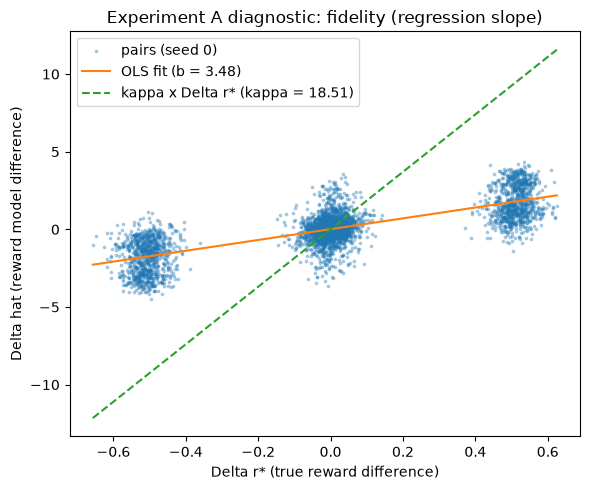

In [14]:
def three_way_verdict(value: float, sigma: float) -> str:
    # value > 2 sigma: 支持、value < -2 sigma: 反証、それ以外: 判定不能(value は期待する向きが正になるよう渡す)
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    if value > 2 * sigma:
        return "支持"
    if value < -2 * sigma:
        return "反証"
    return "判定不能"


def equivalence_verdict(value: float, sigma: float, delta: float) -> str:
    # [value - 2 sigma, value + 2 sigma] が [1 - delta, 1 + delta] に含まれれば支持、共通部分がなければ反証
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    low, high = value - 2 * sigma, value + 2 * sigma
    if 1 - delta <= low and high <= 1 + delta:
        return "支持"
    if high < 1 - delta or low > 1 + delta:
        return "反証"
    return "判定不能"


def slope_from_sums(n, sum_x, sum_y, sum_xx, sum_xy):
    # 最小二乗の傾き(切片あり)を十分統計量から計算する
    return (sum_xy - sum_x * sum_y / n) / (sum_xx - sum_x**2 / n)


def ols_slope(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # y の最後の軸を x に回帰した傾き(切片あり)
    x = np.asarray(x, dtype=np.float64)
    xc = x - x.mean()
    return (np.asarray(y) - np.asarray(y).mean(axis=-1, keepdims=True)) @ xc / (xc @ xc)


def calibration_terms(
    a: float, delta_hat: np.ndarray, target: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    # 目的関数 -p log sigma(a d) - (1 - p) log sigma(-a d) の、組ごとの a についての 1 階微分・2 階微分
    q = 1.0 / (1.0 + np.exp(-a * delta_hat))
    return (q - target) * delta_hat, q * (1.0 - q) * delta_hat**2


def calibration_loss(
    a: float, delta_hat: np.ndarray, target: np.ndarray, weights: np.ndarray
) -> float:
    z = a * delta_hat
    return float(
        np.sum(weights * (target * np.logaddexp(0.0, -z) + (1.0 - target) * np.logaddexp(0.0, z)))
    )


def fit_calibration_slope(
    delta_hat: np.ndarray, target: np.ndarray, weights: np.ndarray | None = None
) -> float:
    # 較正の傾き a = argmin_a sum w [-p log sigma(a d) - (1 - p) log sigma(-a d)](切片なし)をニュートン法で求める。
    # 目的関数は a について凸。損失が増える場合はステップを半分にする(減衰付きのニュートン法)。
    weights = np.ones_like(delta_hat) if weights is None else weights
    a = 1.0
    for _ in range(100):
        gradient, hessian = calibration_terms(a, delta_hat, target)
        step = float(np.sum(weights * gradient) / np.sum(weights * hessian))
        current = calibration_loss(a, delta_hat, target, weights)
        while calibration_loss(a - step, delta_hat, target, weights) > current + 1e-12 * abs(
            current
        ):
            step /= 2.0
        a -= step
        if abs(step) < 1e-12 * max(1.0, abs(a)):
            break
    return float(a)


# --- 解法の確認: 人工データ Delta_hat = c kappa Delta r* で a = 1 / c が回復する ---
_rng_synthetic = np.random.default_rng(0)
_synthetic_delta = _rng_synthetic.normal(0.0, 0.1, size=5000)
_synthetic_target = compute_bradley_terry_probability(_synthetic_delta, KAPPA)
for _c in (0.25, 0.5, 2.0, 4.0):
    _a = fit_calibration_slope(_c * KAPPA * _synthetic_delta, _synthetic_target)
    assert math.isclose(_a, 1.0 / _c, rel_tol=1e-8), (_c, _a)
print(
    "較正の傾きの解法: 人工データ Delta_hat = c kappa Delta r*(c = 0.25, 0.5, 2, 4)で a = 1 / c を回復(相対誤差 1e-8 以内): OK"
)

STANDARD_SCORES = np.stack(
    [RM_RECORDS[(RM_PAIRS_MAX, s)]["pool_scores"] for s in SEEDS_AB]
)  # (S, P, M)
_delta_hat = STANDARD_SCORES[:, :, 0::2] - STANDARD_SCORES[:, :, 1::2]  # (S, P, M/2)
_x = EVAL_DELTA_TRUE  # (P, M/2)
_target = compute_bradley_terry_probability(_x, KAPPA)  # 目標確率 p(同点の組は 0.5)

# --- 対比量: 較正の傾き ---
A_HAT_SEEDS = np.array([fit_calibration_slope(_delta_hat[s], _target) for s in range(NUM_SEEDS_AB)])
RHO = float(A_HAT_SEEDS.mean())
RHO_SEED_STD = float(A_HAT_SEEDS.std(ddof=1))
# 評価集合の項: 入力ごとの 1 階微分・2 階微分(a_hat_s で評価)から、1 ステップのニュートン法で再標本ごとの値を近似する
_gradient_x, _hessian_x = [], []
for _s in range(NUM_SEEDS_AB):
    _g, _h = calibration_terms(A_HAT_SEEDS[_s], _delta_hat[_s], _target)
    _gradient_x.append(by_input(_g.sum(axis=1, keepdims=True))[:, 0])
    _hessian_x.append(by_input(_h.sum(axis=1, keepdims=True))[:, 0])
_gradient_x, _hessian_x = np.stack(_gradient_x), np.stack(_hessian_x)  # (S, |X|)
_a_boot = A_HAT_SEEDS[None, :] - (BOOTSTRAP_COUNTS @ _gradient_x.T) / (
    BOOTSTRAP_COUNTS @ _hessian_x.T
)  # (B, S)
RHO_VAR_BOOT = float(_a_boot.mean(axis=1).var(ddof=1))
SIGMA_RHO = math.sqrt(RHO_SEED_STD**2 / NUM_SEEDS_AB + RHO_VAR_BOOT)
verdict_A = equivalence_verdict(RHO, SIGMA_RHO, A_EQUIVALENCE_MARGIN)
# 近似の確認(診断): 先頭の 20 再標本について、シード 0 の値を解き直した値と比べる
_weights_pairs = (
    np.repeat(BOOTSTRAP_COUNTS[:20], TASK_COUNT, axis=1)[:, :, None] * np.ones_like(_x)[None]
)  # (20, P, M/2)
_exact = np.array([fit_calibration_slope(_delta_hat[0], _target, w) for w in _weights_pairs])
_approximation_error = float(np.abs(_exact - _a_boot[:20, 0]).max())
_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
print(
    f"kappa = {KAPPA:.4f}、評価用の組 {_x.size:,}(|X| = {NUM_EVAL_INPUTS}、同点の組を含む)、S = {NUM_SEEDS_AB}"
)
print("較正の傾き a_hat_s(シード順): " + ", ".join(f"{a:.4f}" for a in A_HAT_SEEDS))
print(
    f"rho = mean_s a_hat_s = {RHO:.4f}、s_rho = {RHO_SEED_STD:.4f}、Var_boot(rho) = {RHO_VAR_BOOT:.3e}"
    f"(1 ステップのニュートン法による近似)、sigma_rho = {SIGMA_RHO:.4f}"
)
print(
    f"区間 [rho - 2 sigma, rho + 2 sigma] = [{RHO - 2 * SIGMA_RHO:.4f}, {RHO + 2 * SIGMA_RHO:.4f}]、"
    f"同等性の範囲 [{1 - A_EQUIVALENCE_MARGIN}, {1 + A_EQUIVALENCE_MARGIN}]"
)
print(f"前提条件: P0={precondition_status['P0']}、P1={precondition_status['P1']}")
print(f"{_tag}判定関数の結果: {verdict_A}")
print(
    f"ブートストラップの近似の確認(シード 0、先頭 20 再標本): 解き直した値との差の最大値 {_approximation_error:.2e}"
    f"(再標本の値のばらつき(標準偏差){_a_boot[:, 0].std(ddof=1):.2e} と比べる)"
)

# --- 診断量: 報酬モデルの予測の忠実度 b_s / kappa(回帰の希釈を受ける、旧対比量) ---
_n_x = by_input(np.full((NUM_EVAL_PROMPTS, 1), _x.shape[1], dtype=np.float64))[:, 0]
_sx_x = by_input(_x.sum(axis=1, keepdims=True))[:, 0]
_sxx_x = by_input((_x**2).sum(axis=1, keepdims=True))[:, 0]
_sy_x = by_input(_delta_hat.sum(axis=2)[..., None])[..., 0]  # (S, |X|)
_sxy_x = by_input((_delta_hat * _x).sum(axis=2)[..., None])[..., 0]
B_SEEDS = slope_from_sums(
    _n_x.sum(), _sx_x.sum(), _sy_x.sum(axis=1), _sxx_x.sum(), _sxy_x.sum(axis=1)
)
INTERCEPTS = (_sy_x.sum(axis=1) - B_SEEDS * _sx_x.sum()) / _n_x.sum()
FIDELITY_SEEDS = B_SEEDS / KAPPA
print(
    "診断量: 予測の忠実度 b_s / kappa(回帰の傾きの比、回帰の希釈を受ける、シード順): "
    + ", ".join(f"{r:.4f}" for r in FIDELITY_SEEDS)
    + f"、平均 {FIDELITY_SEEDS.mean():.4f}(傾き b_s: "
    + ", ".join(f"{b:.4f}" for b in B_SEEDS)
    + ")"
)

# --- 診断量 ---
_spearman = []
for _s in range(NUM_SEEDS_AB):
    _values = [
        compute_spearman_correlation(STANDARD_SCORES[_s, p], POOL_TRUE[p])
        for p in range(NUM_EVAL_PROMPTS)
        if np.ptp(POOL_TRUE[p]) > 0
    ]
    _spearman.append(float(np.mean(_values)))
_eval_labels = sample_preference_labels(
    POOL_TRUE[:, 0::2].ravel(),
    POOL_TRUE[:, 1::2].ravel(),
    KAPPA,
    np.random.default_rng(EVAL_LABEL_SEED),
)
_label_agreement = [
    float(np.mean((_delta_hat[s].ravel() > 0) == _eval_labels)) for s in range(NUM_SEEDS_AB)
]
_p = compute_bradley_terry_probability(_x.ravel(), KAPPA)
BAYES_LABEL_AGREEMENT = float(np.mean(np.maximum(_p, 1 - _p)))
print(
    "診断量: 真の報酬とのプロンプト内の Spearman の順位相関の平均(シード順): "
    + ", ".join(f"{v:.4f}" for v in _spearman)
)
print(
    "診断量: 真の順序との一致率(P1 の量、シード順): "
    + ", ".join(f"{RM_RECORDS[(RM_PAIRS_MAX, s)]['agreement']:.4f}" for s in SEEDS_AB)
)
print(
    "診断量: 評価用の組に抽選したラベルとの一致率(シード順): "
    + ", ".join(f"{v:.4f}" for v in _label_agreement)
    + f"、ベイズ最適な一致率の上限 E[max(p, 1 - p)] = {BAYES_LABEL_AGREEMENT:.4f}"
)
print("診断量: 回帰の切片(シード順): " + ", ".join(f"{v:+.4f}" for v in INTERCEPTS))

_fig, _ax = plt.subplots(figsize=(6, 5))
_sub = np.random.default_rng(0).choice(_x.size, size=min(4000, _x.size), replace=False)
_ax.scatter(_x.ravel()[_sub], _delta_hat[0].ravel()[_sub], s=3, alpha=0.3, label="pairs (seed 0)")
_grid = np.linspace(_x.min(), _x.max(), 50)
_ax.plot(
    _grid, INTERCEPTS[0] + B_SEEDS[0] * _grid, color="C1", label=f"OLS fit (b = {B_SEEDS[0]:.2f})"
)
_ax.plot(
    _grid,
    KAPPA * _grid,
    color="C2",
    linestyle="--",
    label=f"kappa x Delta r* (kappa = {KAPPA:.2f})",
)
_ax.set_xlabel("Delta r* (true reward difference)")
_ax.set_ylabel("Delta hat (reward model difference)")
_ax.set_title("Experiment A diagnostic: fidelity (regression slope)")
_ax.legend()
plt.tight_layout()
plt.show()

### 6.9 実験 B: best-of-n による過最適化

n の水準: (1, 2, 4, 8, 16, 32)(前半 (1, 2, 4)・後半 (8, 16, 32))、M = 128、S = 2
真の報酬の期待値 R(n)(シード平均): 0.4404, 0.5409, 0.5853, 0.5935, 0.5929, 0.5915
g1(前半の傾き、log2 n あたり)= +0.07249、シードごと +0.07225, +0.07272、Var_boot = 2.372e-06、sigma = 0.00156、2 sigma = 0.00312
g2(後半の傾き、log2 n あたり)= -0.00101、シードごと -0.00010, -0.00192、Var_boot = 6.622e-07、sigma = 0.00122、2 sigma = 0.00244
前提条件: P0=False、P1=True、P2=True
[動作確認のみ、結論ではない] 判定関数の結果: 判定不能
診断量: 代理報酬の期待値(シード平均): 1.8536, 2.3858, 2.6270, 2.7517, 2.8375, 2.9056
診断量: 完全一致(r* = 1)の確率(シード平均): 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000
参考: KL の上界 log n - (n-1)/n: 0.000, 0.193, 0.636, 1.204, 1.835, 2.497


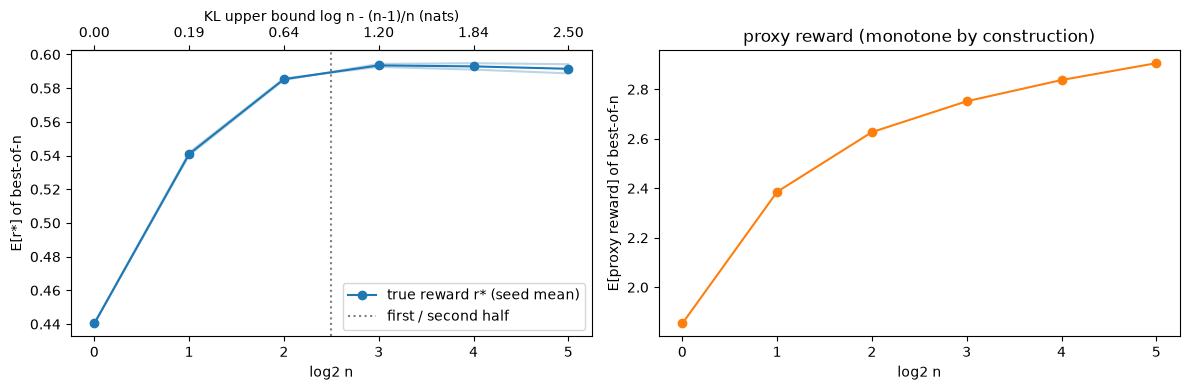

In [15]:
def curves_by_input(scores: np.ndarray, values: np.ndarray) -> np.ndarray:
    # 1 つの報酬モデルのプールのスコア (P, M) から、入力ごとの best-of-n の期待値の和 (|X|, L) を返す
    return by_input(best_of_n_expected_values(scores, values, BON_LEVELS))


def bootstrap_curves(per_input: np.ndarray) -> np.ndarray:
    # (S, |X|, L) の入力ごとの和から、再標本ごとのシード平均の曲線 (B, L) を返す
    weights = BOOTSTRAP_COUNTS / (TASK_COUNT * BOOTSTRAP_COUNTS.sum(axis=1, keepdims=True))
    return np.einsum("bx,sxl->bl", weights, per_input) / per_input.shape[0]


BON_J = np.log2(BON_LEVELS)
_first, _second = slice(0, BON_HALF), slice(BON_HALF, None)
BON_TRUE_BY_INPUT = np.stack(
    [curves_by_input(STANDARD_SCORES[s], POOL_TRUE) for s in range(NUM_SEEDS_AB)]
)  # (S, |X|, L)
BON_PROXY = np.stack(
    [
        best_of_n_expected_values(STANDARD_SCORES[s], STANDARD_SCORES[s], BON_LEVELS).mean(axis=0)
        for s in range(NUM_SEEDS_AB)
    ]
)
BON_EXACT = np.stack(
    [
        best_of_n_expected_values(
            STANDARD_SCORES[s], (POOL_TRUE == 1.0).astype(float), BON_LEVELS
        ).mean(axis=0)
        for s in range(NUM_SEEDS_AB)
    ]
)
BON_TRUE_SEEDS = BON_TRUE_BY_INPUT.sum(axis=1) / NUM_EVAL_PROMPTS  # (S, L) = R_s(n)
BON_TRUE_MEAN = BON_TRUE_SEEDS.mean(axis=0)
_boot_curves = bootstrap_curves(BON_TRUE_BY_INPUT)  # (B, L)
CONTRAST_B = {}
for _name, _part in (("g1", _first), ("g2", _second)):
    _seed_slopes = ols_slope(BON_J[_part], BON_TRUE_SEEDS[:, _part])
    _var_boot = float(ols_slope(BON_J[_part], _boot_curves[:, _part]).var(ddof=1))
    CONTRAST_B[_name] = {
        "value": float(ols_slope(BON_J[_part], BON_TRUE_MEAN[_part])),
        "seed_slopes": _seed_slopes,
        "var_boot": _var_boot,
        "sigma": math.sqrt(float(_seed_slopes.std(ddof=1)) ** 2 / NUM_SEEDS_AB + _var_boot),
    }
_g1, _g2 = CONTRAST_B["g1"], CONTRAST_B["g2"]
if _g1["value"] > 2 * _g1["sigma"] and _g2["value"] < -2 * _g2["sigma"]:
    verdict_B = "支持"
elif _g2["value"] > 2 * _g2["sigma"]:
    verdict_B = "反証"
else:
    verdict_B = "判定不能"
print(
    f"n の水準: {BON_LEVELS}(前半 {BON_LEVELS[_first]}・後半 {BON_LEVELS[_second]})、M = {POOL_SIZE}、S = {NUM_SEEDS_AB}"
)
print("真の報酬の期待値 R(n)(シード平均): " + ", ".join(f"{v:.4f}" for v in BON_TRUE_MEAN))
for _name, _label in (("g1", "前半"), ("g2", "後半")):
    _c = CONTRAST_B[_name]
    print(
        f"{_name}({_label}の傾き、log2 n あたり)= {_c['value']:+.5f}、シードごと "
        + ", ".join(f"{v:+.5f}" for v in _c["seed_slopes"])
        + f"、Var_boot = {_c['var_boot']:.3e}、sigma = {_c['sigma']:.5f}、2 sigma = {2 * _c['sigma']:.5f}"
    )
print(
    f"前提条件: P0={precondition_status['P0']}、P1={precondition_status['P1']}、P2={precondition_status['P2']}"
)
print(f"{_tag}判定関数の結果: {verdict_B}")
print(
    "診断量: 代理報酬の期待値(シード平均): " + ", ".join(f"{v:.4f}" for v in BON_PROXY.mean(axis=0))
)
print(
    "診断量: 完全一致(r* = 1)の確率(シード平均): "
    + ", ".join(f"{v:.4f}" for v in BON_EXACT.mean(axis=0))
)
print(
    "参考: KL の上界 log n - (n-1)/n: "
    + ", ".join(f"{best_of_n_kl_upper_bound(n):.3f}" for n in BON_LEVELS)
)

_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
for _s in range(NUM_SEEDS_AB):
    _axes[0].plot(BON_J, BON_TRUE_SEEDS[_s], color="C0", alpha=0.3)
_axes[0].plot(BON_J, BON_TRUE_MEAN, color="C0", marker="o", label="true reward r* (seed mean)")
_axes[0].axvline(BON_J[BON_HALF] - 0.5, color="gray", linestyle=":", label="first / second half")
_axes[0].set_xlabel("log2 n")
_axes[0].set_ylabel("E[r*] of best-of-n")
_top = _axes[0].secondary_xaxis("top", functions=(lambda j: j, lambda j: j))
_top.set_xticks(BON_J)
_top.set_xticklabels([f"{best_of_n_kl_upper_bound(n):.2f}" for n in BON_LEVELS])
_top.set_xlabel("KL upper bound log n - (n-1)/n (nats)")
_axes[0].legend()
_axes[1].plot(BON_J, BON_PROXY.mean(axis=0), color="C1", marker="o")
_axes[1].set_xlabel("log2 n")
_axes[1].set_ylabel("E[proxy reward] of best-of-n")
_axes[1].set_title("proxy reward (monotone by construction)")
plt.tight_layout()
plt.show()

### 6.10 実験 C: 選好データ量による過最適化の緩和

データ量の水準 N: (64, 256, 1024)、シード (0, 1)、n_max = 32
  N =     64: R(n_max)(シード順)0.5871, 0.5700、平均 0.5785
  N =    256: R(n_max)(シード順)0.5976, 0.5964、平均 0.5970
  N =  1,024: R(n_max)(シード順)0.5942, 0.5888、平均 0.5915
c(R(n_max) の log2 N に対する傾き)= +0.00324、シードごと +0.00178, +0.00470、Var_boot = 1.117e-06、sigma_c = 0.00180、2 sigma_c = 0.00360
前提条件: P0=False、P1=True、P2=True
[動作確認のみ、結論ではない] 判定関数の結果: 判定不能
診断量 N = 64: R(n)(シード平均)0.4404, 0.5107, 0.5508, 0.5665, 0.5734, 0.5785、放物線の頂点 log2 n = 4.06、真の順序との一致率の平均 0.6647
診断量 N = 256: R(n)(シード平均)0.4404, 0.5414, 0.5868, 0.5959, 0.5967, 0.5970、放物線の頂点 log2 n = 3.62、真の順序との一致率の平均 0.7280
診断量 N = 1,024: R(n)(シード平均)0.4404, 0.5409, 0.5853, 0.5935, 0.5929, 0.5915、放物線の頂点 log2 n = 3.57、真の順序との一致率の平均 0.7317


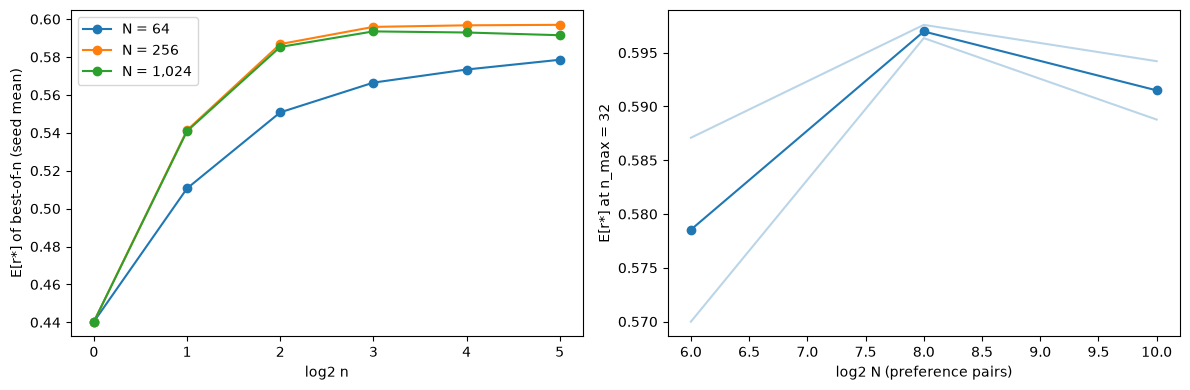

In [16]:
C_TRUE_BY_INPUT = {
    n: np.stack([curves_by_input(RM_RECORDS[(n, s)]["pool_scores"], POOL_TRUE) for s in SEEDS_C])
    for n in C_LEVELS
}  # 水準ごとに (S_C, |X|, L)
C_CURVES = {n: v.sum(axis=1) / NUM_EVAL_PROMPTS for n, v in C_TRUE_BY_INPUT.items()}  # (S_C, L)
_log_n = np.log2(C_LEVELS)
_at_max = np.stack([C_CURVES[n][:, -1] for n in C_LEVELS], axis=1)  # (S_C, 水準)
C_SEED_SLOPES = ols_slope(_log_n, _at_max)
C_SLOPE = float(ols_slope(_log_n, _at_max.mean(axis=0)))
_boot_at_max = np.stack(
    [bootstrap_curves(C_TRUE_BY_INPUT[n])[:, -1] for n in C_LEVELS], axis=1
)  # (B, 水準)
C_VAR_BOOT = float(ols_slope(_log_n, _boot_at_max).var(ddof=1))
SIGMA_C = math.sqrt(float(C_SEED_SLOPES.std(ddof=1)) ** 2 / NUM_SEEDS_C + C_VAR_BOOT)
verdict_C = three_way_verdict(C_SLOPE, SIGMA_C)
print(f"データ量の水準 N: {C_LEVELS}、シード {SEEDS_C}、n_max = {N_MAX_BON}")
for _i, _n in enumerate(C_LEVELS):
    print(
        f"  N = {_n:>6,}: R(n_max)(シード順)"
        + ", ".join(f"{v:.4f}" for v in _at_max[:, _i])
        + f"、平均 {_at_max[:, _i].mean():.4f}"
    )
print(
    f"c(R(n_max) の log2 N に対する傾き)= {C_SLOPE:+.5f}、シードごと "
    + ", ".join(f"{v:+.5f}" for v in C_SEED_SLOPES)
    + f"、Var_boot = {C_VAR_BOOT:.3e}、sigma_c = {SIGMA_C:.5f}、2 sigma_c = {2 * SIGMA_C:.5f}"
)
print(
    f"前提条件: P0={precondition_status['P0']}、P1={precondition_status['P1']}、P2={precondition_status['P2']}"
)
print(f"{_tag}判定関数の結果: {verdict_C}")
for _n in C_LEVELS:  # 診断量: 放物線のあてはめの頂点と、真の順序との一致率
    _mean = C_CURVES[_n].mean(axis=0)
    _a2, _a1, _a0 = np.polyfit(BON_J, _mean, 2)
    _vertex = f"log2 n = {-_a1 / (2 * _a2):.2f}" if _a2 < 0 else "頂点なし(上に凸でない)"
    print(
        f"診断量 N = {_n:,}: R(n)(シード平均)"
        + ", ".join(f"{v:.4f}" for v in _mean)
        + f"、放物線の頂点 {_vertex}、真の順序との一致率の平均 {np.mean([RM_RECORDS[(_n, s)]['agreement'] for s in SEEDS_C]):.4f}"
    )

_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
for _i, _n in enumerate(C_LEVELS):
    _axes[0].plot(BON_J, C_CURVES[_n].mean(axis=0), marker="o", color=f"C{_i}", label=f"N = {_n:,}")
_axes[0].set_xlabel("log2 n")
_axes[0].set_ylabel("E[r*] of best-of-n (seed mean)")
_axes[0].legend()
for _s in range(NUM_SEEDS_C):
    _axes[1].plot(_log_n, _at_max[_s], color="C0", alpha=0.3)
_axes[1].plot(_log_n, _at_max.mean(axis=0), color="C0", marker="o")
_axes[1].set_xlabel("log2 N (preference pairs)")
_axes[1].set_ylabel(f"E[r*] at n_max = {N_MAX_BON}")
plt.tight_layout()
plt.show()

### 6.11 PPO の動作確認(判定なし)

標準の水準・シード 0 の報酬モデルを報酬とし、KL 係数 $\beta \in \{0.01, 0.1\}$ で PPO を行う。判定基準を設けない定性的な
観察である。反復ごとの値はバッチ(64 プロンプト)の平均なので、図には 10 反復の移動平均を重ねる。

beta = 0.01: 2 反復(7.7s)。最初 / 最後の 1 反復の平均: KL 0.000 / 0.025、代理報酬 1.276 / 1.273、真の報酬 0.4028 / 0.3981、応答の長さ 19.5 / 17.9、クリップの割合(平均)0.000
  最後の反復の応答の例: ' fire verbistry\n### End'


beta = 0.1: 2 反復(7.9s)。最初 / 最後の 1 反復の平均: KL 0.000 / 0.025、代理報酬 1.276 / 1.273、真の報酬 0.4028 / 0.3981、応答の長さ 19.5 / 17.9、クリップの割合(平均)0.000
  最後の反復の応答の例: ' fire verbistry\n### End'
PPO の合計: 15.7s(上限の宣言 15 分は見積もりに対するもの)


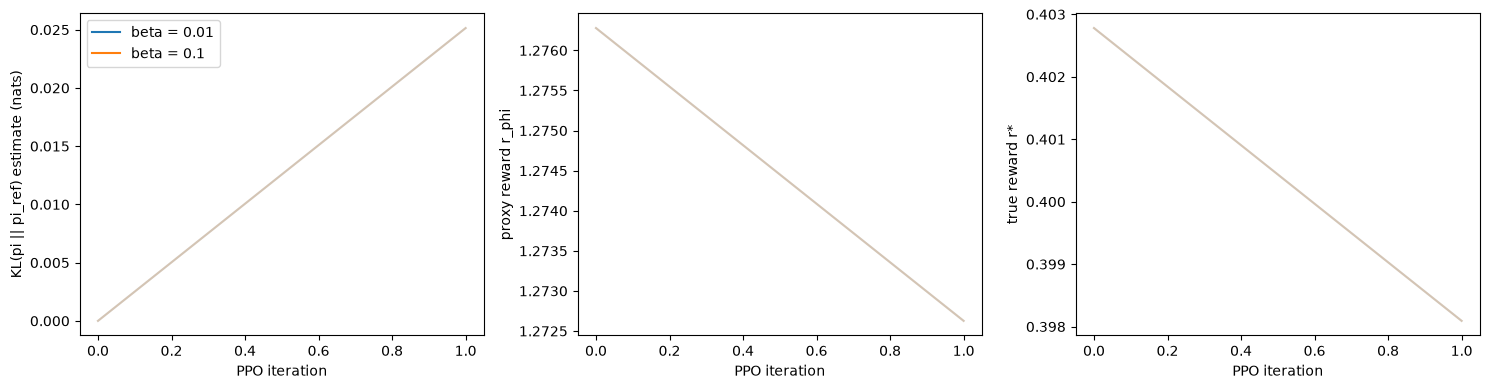

In [17]:
PPO_HISTORIES = {}
_t0_ppo = time.time()
for _beta in PPO_BETAS:
    _t0 = time.time()
    PPO_HISTORIES[_beta] = run_ppo_iterations(
        reference_policy, PPO_REWARD_MODEL, _beta, PPO_ITERATIONS
    )
    _h = PPO_HISTORIES[_beta]
    _k = max(1, min(10, PPO_ITERATIONS // 4))
    print(
        f"beta = {_beta}: {PPO_ITERATIONS} 反復({time.time() - _t0:.1f}s)。最初 / 最後の {_k} 反復の平均: "
        f"KL {np.mean(_h['kl'][:_k]):.3f} / {np.mean(_h['kl'][-_k:]):.3f}、"
        f"代理報酬 {np.mean(_h['proxy_reward'][:_k]):.3f} / {np.mean(_h['proxy_reward'][-_k:]):.3f}、"
        f"真の報酬 {np.mean(_h['true_reward'][:_k]):.4f} / {np.mean(_h['true_reward'][-_k:]):.4f}、"
        f"応答の長さ {np.mean(_h['response_length'][:_k]):.1f} / {np.mean(_h['response_length'][-_k:]):.1f}、"
        f"クリップの割合(平均){np.mean(_h['clip_fraction']):.3f}"
    )
    print(f"  最後の反復の応答の例: {_h['example'][-1]!r}")
PPO_SECONDS = time.time() - _t0_ppo
print(
    f"PPO の合計: {PPO_SECONDS:.1f}s(上限の宣言 {PPO_TIME_CAP_SECONDS / 60:.0f} 分は見積もりに対するもの)"
)


def moving_average(values, window: int = 10) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    window = max(1, min(window, len(values)))
    return np.convolve(values, np.ones(window) / window, mode="valid")


_fig, _axes = plt.subplots(1, 3, figsize=(15, 4))
for _i, (_beta, _h) in enumerate(PPO_HISTORIES.items()):
    for _ax, _key, _label in zip(
        _axes,
        ("kl", "proxy_reward", "true_reward"),
        ("KL(pi || pi_ref) estimate (nats)", "proxy reward r_phi", "true reward r*"),
        strict=True,
    ):
        _ax.plot(_h[_key], color=f"C{_i}", alpha=0.25)
        _smoothed = moving_average(_h[_key])
        _ax.plot(
            np.arange(len(_smoothed)) + (len(_h[_key]) - len(_smoothed)),
            _smoothed,
            color=f"C{_i}",
            label=f"beta = {_beta}",
        )
        _ax.set_xlabel("PPO iteration")
        _ax.set_ylabel(_label)
_axes[0].legend()
plt.tight_layout()
plt.show()

### 6.12 不変条件のアサーションと`SMOKE_TEST`の配線

- 応答プールが、全ての報酬モデルのスコアリングの後も生成直後と同一(ハッシュが一致)であり、全シード・全水準で同じプール・
  同じ評価用のプロンプトを使った。
- 報酬モデルの学習用・評価用・PPO 用のプロンプトの入力が互いに素(5.4 節で確認済みのものを再確認)。
- 全ての報酬モデルの学習ステップ数が $T_{\mathrm{RM}}$ で、組の順序のハッシュが同じ引数で作り直した値と一致し、データ量の
  水準が入れ子(学習用の先頭 $N$ 組)である。
- 参照方策の重みが、全ての実験の後もマージ直後と bit 単位で一致する(報酬モデル・PPO は複製を学習した)。ベースモデルの重みが
  Hub から読み込んだ重みと一致する。
- `SMOKE_TEST`の配線と削る段階: 実際に使ったシード・水準・$M$・$n$ の水準・PPO の反復回数・ステップ数・ブートストラップの
  反復回数が、5.2 節の水準と 6.4 節で選ばれた段階と一致する。

In [18]:
assert hash_json(POOL) == POOL_HASH, "応答プールが変わった"
assert STANDARD_SCORES.shape == (NUM_SEEDS_AB, NUM_EVAL_PROMPTS, POOL_SIZE)
assert all(r["pool_scores"].shape == (NUM_EVAL_PROMPTS, POOL_SIZE) for r in RM_RECORDS.values())
assert not (set(EVAL_INPUTS) & set(RM_TRAIN_INPUTS)) and not (set(EVAL_INPUTS) & set(PPO_INPUTS))
assert not (set(RM_TRAIN_INPUTS) & set(PPO_INPUTS))
for (_n, _s), _r in RM_RECORDS.items():
    assert len(_r["history"]["step"]) == RM_STEPS
    assert _r["history"]["batches_hash"] == hash_json(
        make_epoch_batches(_n, RM_STEPS, RM_BATCH_PAIRS, _s)
    )
    assert (
        max(i for b in make_epoch_batches(_n, RM_STEPS, RM_BATCH_PAIRS, _s) for i in b) == _n - 1
    )  # 先頭 N 組のみ
assert sorted(RM_RECORDS) == sorted(RM_JOBS) and len(RM_RECORDS) == num_reward_models(STAGE)
assert all(len(LABELS[s]) == RM_PAIRS_MAX for s in SEEDS_AB)
_reference_now = {k: v.detach().cpu() for k, v in reference_policy.state_dict().items()}
assert all(torch.equal(_reference_now[k], REFERENCE_STATE[k]) for k in REFERENCE_STATE), (
    "参照方策の重みが変わった"
)
_hub_state = torch.load(MODEL_STATE_PATH, map_location="cpu")
assert all(torch.equal(v.cpu(), _hub_state[k]) for k, v in base_model.state_dict().items())
# SMOKE_TEST の配線と削る段階
assert STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE] == STAGE
assert tuple(range(STAGE["NUM_SEEDS_AB"])) == SEEDS_AB and tuple(
    range(STAGE["NUM_SEEDS_C"])
) == SEEDS_C
assert rm_levels(STAGE["C_NUM_LEVELS"], CFG["RM_PAIRS_MAX"]) == C_LEVELS
assert CFG["RM_PAIRS_MAX"] // RM_BATCH_PAIRS == RM_STEPS and CFG["SFT_STEPS"] == SFT_STEPS
assert len(SFT_HISTORY["step"]) == CFG["SFT_STEPS"]
assert CFG["POOL_SIZE"] == POOL_SIZE and all(len(r) == POOL_SIZE for r in POOL)
assert (
    CFG["NUM_EVAL_INPUTS"] * TASK_COUNT == NUM_EVAL_PROMPTS
    and len(P0_EXAMPLES) == CFG["NUM_P0_INPUTS"] * TASK_COUNT
)
assert BON_LEVELS[-1] == CFG["POOL_SIZE"] // 4 and BOOTSTRAP_COUNTS.shape == (
    CFG["BOOTSTRAP_RESAMPLES"],
    NUM_EVAL_INPUTS,
)
assert ppo_iterations_for(STAGE, CFG) == PPO_ITERATIONS
assert all(len(h["kl"]) == PPO_ITERATIONS for h in PPO_HISTORIES.values())
print(
    f"応答プールの同一性、プロンプトの分割、全 {len(RM_RECORDS)} 報酬モデルのステップ数・組の順序・入れ子、"
    "参照方策とベースモデルの重みの不変性: OK"
)
print(
    f"SMOKE_TEST の配線と削る段階: 水準 {CURRENT_LEVEL_NAME!r}・段階 {SELECTED_STAGE}(実験 A・B のシード {SEEDS_AB}、"
    f"実験 C のシード {SEEDS_C}・水準 {C_LEVELS}、M {POOL_SIZE}、n {BON_LEVELS}、T_SFT {SFT_STEPS}、T_RM {RM_STEPS}、"
    f"PPO {PPO_ITERATIONS} 反復、反復 {BOOTSTRAP_RESAMPLES})が一致: OK"
)

応答プールの同一性、プロンプトの分割、全 6 報酬モデルのステップ数・組の順序・入れ子、参照方策とベースモデルの重みの不変性: OK
SMOKE_TEST の配線と削る段階: 水準 'smoke'・段階 4(実験 A・B のシード (0, 1)、実験 C のシード (0, 1)・水準 (64, 256, 1024)、M 128、n (1, 2, 4, 8, 16, 32)、T_SFT 32、T_RM 32、PPO 2 反復、反復 1000)が一致: OK


### 6.13 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は
参考として別欄に残す。選ばれた段階と、判定に実際に使ったシード数・水準を印字する。

In [19]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


print(f"{_tag}段階の選択: {STAGE_SELECTION_MESSAGE}")
print(
    f"{_tag}判定に使った値: 実験 A・B は S = {NUM_SEEDS_AB}(シード {SEEDS_AB})、実験 C は S = {NUM_SEEDS_C}"
    f"(シード {SEEDS_C})・水準 {C_LEVELS}、M = {POOL_SIZE}、n = {BON_LEVELS}"
)
PRECONDITIONS = {"A": ["P0", "P1"], "B": ["P0", "P1", "P2"], "C": ["P0", "P1", "P2"]}
print(f"{_tag}実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定")
for _name, _stat, _computed in (
    (
        "A",
        f"較正の傾き rho = {RHO:.4f}、sigma = {SIGMA_RHO:.4f}、区間 [{RHO - 2 * SIGMA_RHO:.4f}, {RHO + 2 * SIGMA_RHO:.4f}]",
        verdict_A,
    ),
    (
        "B",
        f"g1 = {_g1['value']:+.5f}(sigma {_g1['sigma']:.5f})、g2 = {_g2['value']:+.5f}(sigma {_g2['sigma']:.5f})",
        verdict_B,
    ),
    ("C", f"c = {C_SLOPE:+.5f}、sigma = {SIGMA_C:.5f}", verdict_C),
):
    _pre = ", ".join(f"{p}={precondition_status.get(p)}" for p in PRECONDITIONS[_name])
    print(
        f"{_tag}{_name} | {_stat} | {_pre} | {_computed} | {verdict_label(_computed, PRECONDITIONS[_name])}"
    )
if SMOKE_TEST:
    print(
        "上記はスモークテストによるコードの動作確認であり、本番実行の後に数値が変わるため、結論としては扱わない。"
    )
print(f"\nノートブック全体の実行時間: {(time.time() - NOTEBOOK_START_TIME) / 60:.1f} 分")

[動作確認のみ、結論ではない] 段階の選択: 段階 4 でも見積もり 277.3 分が予算 120.0 分を超える(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 4 で動作確認を続ける
[動作確認のみ、結論ではない] 判定に使った値: 実験 A・B は S = 2(シード (0, 1))、実験 C は S = 2(シード (0, 1))・水準 (64, 256, 1024)、M = 128、n = (1, 2, 4, 8, 16, 32)
[動作確認のみ、結論ではない] 実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
[動作確認のみ、結論ではない] A | 較正の傾き rho = 1.0733、sigma = 0.0243、区間 [1.0247, 1.1220] | P0=False, P1=True | 支持 | 前提不成立
[動作確認のみ、結論ではない] B | g1 = +0.07249(sigma 0.00156)、g2 = -0.00101(sigma 0.00122) | P0=False, P1=True, P2=True | 判定不能 | 前提不成立
[動作確認のみ、結論ではない] C | c = +0.00324、sigma = 0.00180 | P0=False, P1=True, P2=True | 判定不能 | 前提不成立
上記はスモークテストによるコードの動作確認であり、本番実行の後に数値が変わるため、結論としては扱わない。

ノートブック全体の実行時間: 4.4 分


### 6.14 SFT モデルのアップロード(Hugging Face Hub)

参照方策 $\pi_{\mathrm{ref}}$(LoRA をマージした SFT モデル)を、`kojikojiprg/ai-theories-small-gpt-en`の新ブランチ
`sft-synthetic`にアップロードする。018 の DPO が参照方策として使う。

- **`UPLOAD_ARTIFACTS = True`のときだけ** アップロードする(既定は`False`。`SMOKE_TEST`とは独立)。スモークテストの重みは
  アップロードしない(`SMOKE_TEST = True`ではアップロードしない)。
- Google Colab の Secrets から`HF_TOKEN`が取得できない場合は、例外で停止せず、アップロードをスキップしてその旨を印字する。
- 手順: ブランチ`sft-synthetic`を作成 → `model_state.pt`・`config.json`(`main`の`config.json`をそのまま使う。構造は同一)・
  `README.md`(モデルカード)をアップロード → `list_repo_files(..., revision="sft-synthetic")`で存在を確認し、
  `model_state.pt`をダウンロードし直して SHA-256 が一致することを確かめる。
- **トークナイザは同梱しない**(`kojikojiprg/ai-theories-tokenizer-en`を使う)。ブランチに`tokenizer.json`がないことも確かめる。
- モデルカードの性能指標は、アップロードする重みそのもの(6.5 節で評価したマージ後の重み)の値である。

In [20]:
import tempfile  # noqa: E402

# 保存用の state_dict(CPU)。重み共有(token_embedding.weight と lm_head.weight)を保つため、元の
# ストレージごとに 1 回だけ CPU へ移す(010 と同じ扱い。共有を保たないと埋め込み行列が 2 重に保存される)
_cpu_cache: dict[int, torch.Tensor] = {}
_upload_state: dict[str, torch.Tensor] = {}
for _key, _value in reference_policy.state_dict().items():
    _ptr = _value.data_ptr()
    if _ptr not in _cpu_cache:
        _cpu_cache[_ptr] = _value.detach().cpu().clone()
    _upload_state[_key] = _cpu_cache[_ptr]
SFT_CHECKPOINT_PATH = Path(tempfile.mkdtemp()) / "model_state.pt"
torch.save(_upload_state, SFT_CHECKPOINT_PATH)
_reloaded = torch.load(SFT_CHECKPOINT_PATH, map_location="cpu")
assert _reloaded.keys() == BASE_STATE.keys()
assert all(torch.equal(_reloaded[k], REFERENCE_STATE[k]) for k in REFERENCE_STATE)
SFT_CHECKPOINT_SHA256 = hashlib.sha256(SFT_CHECKPOINT_PATH.read_bytes()).hexdigest()
print(f"保存・読み戻しで全 {len(_reloaded)} テンソルがマージ後の重みと一致: OK")
print(f"バイト数 {SFT_CHECKPOINT_PATH.stat().st_size:,}、SHA-256 {SFT_CHECKPOINT_SHA256}")


def build_sft_model_card() -> str:
    return f"""---
language: en
license: mit
tags:
- ai-theories
- gpt
- sft
- scratch-implementation
---

# ai-theories 小型 GPT の SFT モデル(合成の指示データ、ブランチ: `{SFT_BRANCH}`)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
[kojikojiprg/ai-theories-small-gpt-en](https://huggingface.co/{MODEL_REPO_ID}) の `main` ブランチ(008 の事前学習済み
モデル)を、[016. SFT(指示チューニング)](https://github.com/kojikojiprg/ai-theories/blob/main/theories/04_alignment/016_supervised_fine_tuning.ipynb)
の条件 1 のレシピ(合成の指示データ 65,536 事例・損失マスクあり・Query / Value 射影への LoRA(r = 8、alpha = 8)・学習率 1e-2・
2,048 ステップ・シード 0)で、[017. 報酬モデルと RLHF](https://github.com/kojikojiprg/ai-theories/blob/main/theories/04_alignment/017_reward_model_and_rlhf.ipynb)
の中で学習し直し、LoRA を重みにマージしたもの。017 と 018(DPO)の参照方策として使う。

スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 構成

`config.json` を参照(`main` ブランチと同一の構造。LoRA はマージ済みで、追加のパラメータはない)。

**トークナイザはこのリポジトリ・ブランチには同梱していない。**
[kojikojiprg/ai-theories-tokenizer-en](https://huggingface.co/{TOKENIZER_REPO_ID}) を使用すること(`main` ブランチと共通)。

## 性能指標(アップロードした重みそのものを評価した値)

- 016 の評価集合(250 入力 x 4 課題 = {len(P0_EXAMPLES)} 事例、貪欲法、終端記号 `### End` まで最大 32 トークン):
  完全一致率 {SFT_EXACT_MATCH:.4f}、形式の遵守率 {SFT_FORMAT_RATE:.4f}
- 同じ評価集合の応答部分の負の対数尤度(教師強制): {SFT_RESPONSE_NLL:.4f} nats / トークン
- 英語版 Wikipedia の検証 bits-per-byte(008 と同じ分割・評価): {SFT_BITS_PER_BYTE:.6f}(SFT 前 {BASE_BITS_PER_BYTE:.6f})

## 検証情報

- SHA-256(`model_state.pt`): `{SFT_CHECKPOINT_SHA256}`

## 関連ノートブック

- [016. SFT(指示チューニング)](https://github.com/kojikojiprg/ai-theories/blob/main/theories/04_alignment/016_supervised_fine_tuning.ipynb)
- [017. 報酬モデルと RLHF](https://github.com/kojikojiprg/ai-theories/blob/main/theories/04_alignment/017_reward_model_and_rlhf.ipynb)
"""


if not UPLOAD_ARTIFACTS:
    print("UPLOAD_ARTIFACTS = False のため、アップロードをスキップした。")
elif SMOKE_TEST:
    print("SMOKE_TEST = True のため、スモークテストの重みはアップロードしない(スキップした)。")
else:
    _hf_token = None
    try:
        from google.colab import userdata

        _hf_token = userdata.get("HF_TOKEN")
    except Exception as _e:  # noqa: BLE001  # Colab Secrets 未設定・非 Colab 環境など理由を問わずスキップする
        print(
            f"Colab Secrets から HF_TOKEN を取得できなかったため、アップロードをスキップした: {type(_e).__name__}"
        )
    if not _hf_token:
        print("HF_TOKEN がないため、アップロードをスキップした。")
    else:
        from huggingface_hub import HfApi

        _api = HfApi(token=_hf_token)
        _config_bytes = Path(_config_path).read_bytes()  # main の config.json(構造は同一)
        _api.create_branch(repo_id=MODEL_REPO_ID, branch=SFT_BRANCH, exist_ok=True)
        for _source, _target in (
            (str(SFT_CHECKPOINT_PATH), "model_state.pt"),
            (_config_bytes, "config.json"),
            (build_sft_model_card().encode("utf-8"), "README.md"),
        ):
            _api.upload_file(
                path_or_fileobj=_source,
                path_in_repo=_target,
                repo_id=MODEL_REPO_ID,
                revision=SFT_BRANCH,
            )
        # upload_file が例外を送出しなかったことだけを成功の根拠にせず、存在と内容を確かめる
        _files = set(_api.list_repo_files(repo_id=MODEL_REPO_ID, revision=SFT_BRANCH))
        for _expected in ("model_state.pt", "config.json", "README.md"):
            assert _expected in _files, (
                f"{_expected} が {MODEL_REPO_ID}@{SFT_BRANCH} に見つからない"
            )
        assert "tokenizer.json" not in _files, "トークナイザが同梱されている"
        _downloaded = hf_hub_download(
            MODEL_REPO_ID, "model_state.pt", revision=SFT_BRANCH, force_download=True
        )
        assert hashlib.sha256(Path(_downloaded).read_bytes()).hexdigest() == SFT_CHECKPOINT_SHA256
        print(
            f"[OK] アップロード完了。list_repo_files で存在を確認し、model_state.pt の SHA-256 が一致した: "
            f"https://huggingface.co/{MODEL_REPO_ID}/tree/{SFT_BRANCH}"
        )

保存・読み戻しで全 39 テンソルがマージ後の重みと一致: OK
バイト数 20,997,217、SHA-256 30ac89c4114dd9c32a41741a61fc3f4934dc040c4656c02b125c55d9b337aa8f
UPLOAD_ARTIFACTS = False のため、アップロードをスキップした。


## 7. 結果・考察 / Results and Discussion

**(本番実行の後に記述する。)** 判定は 6.1 節で事前に宣言した基準のみから導き、結果を見た後に立てた解釈は「事後的な解釈」
として節を分けて記す。

### 7.1 実行の概要

- 実行環境(5.1 節の印字)、選ばれた段階と実際に使ったシード数・水準(6.4・6.13 節)、見積もりと実際の実行時間の比較。
- 前提条件 P0・P1・P2 の値と成否の表。

### 7.2 SFT(参照方策)の再現

- マージ後の重みの完全一致率・形式の遵守率と 016 の値との比較、マージの前後の一致、検証 bits-per-byte の変化。

### 7.3 応答プールと選好データ

- プールの多様性・$r^*$ の分布・同点の割合、$\kappa$ の値と、ラベルが真の順序と一致する割合。

### 7.4 実験 A(報酬の尺度の較正)の判定結果

- 較正の傾き $\rho$・$\sigma_\rho$・区間と判定。ブートストラップの 1 ステップ近似と解き直した値との差。
- 診断量(予測の忠実度 $b_s / \kappa$ と切片・順位相関・真の順序との一致率・ラベルとの一致率とベイズ最適な上限)。
- 較正の傾きと予測の忠実度の違い(回帰の希釈)の読み取り、散布図の読み取り。

### 7.5 実験 B(best-of-n による過最適化)の判定結果

- $g_1$・$g_2$ とそれぞれの $\sigma$、判定。真の報酬・代理報酬・完全一致の確率の曲線の読み取り。KL の上界との対応。

### 7.6 実験 C(選好データ量による緩和)の判定結果

- $c$・$\sigma_c$ と判定。水準ごとの曲線・放物線の頂点・真の順序との一致率。

### 7.7 PPO の動作確認(判定なし)

- 2 つの KL 係数での KL・代理報酬・真の報酬の推移の記述。

### 7.8 事後的な解釈(検証済みの結論ではない)

- 想定と異なる結果があった場合の、結果を見た後の解釈。

### 7.9 まとめと 018 への接続

- 本トピックで分かったことの要約と、018(DPO)が同じ参照方策・選好データの設定をどう使うか。

### 本番実行の後に更新が必要な箇所

- 7 節の各小節の本文(上の箇条書きを、本番のセル出力の数値に基づく記述に置き換える)。
- 7.1 節の実行環境・段階・実行時間(5.1・6.4・6.13 節の印字を出典とする)。
- `theories/README.md`の 017 行の「扱う内容」への本番実行の結果の要約の追記。
- アップロードを行った場合は、6.14 節の出力(ブランチの URL と SHA-256)を確認し、7.2 節に記す。